# On-sky stability covariance analysis

This notebook analyzes LSSTCam corner Zernike coefficients to build measured covariance/correlation matrices, remap the covariance to Z4–Z28, and compare measured vs simulated results. It also computes OFC/StateEstimator DOF states with and without an explicit measurement noise covariance and summarizes the results with diagnostic plots.

Missing Zernikes in remaps are treated as unmeasured modes (off-diagonal set to 0, diagonal set to 1).

In [52]:
# =============================================================================
# Section 1: Imports & Setup
# =============================================================================
from lsst.rubintv.production.aosUtils import makeDataframeFromZernikes
from lsst.summit.utils import (
    ConsDbClient,
    getBandpassSeeingCorrection,
    getAirmassSeeingCorrection,
    makeDefaultButler,
)
from lsst.ts.aos.analysis import ofcUtils
from lsst.ts.ofc import OFC, OFCData, StateEstimator
from lsst_efd_client import EfdClient

import galsim
import re
import json
import itertools
import scipy.io
import textwrap
import traceback
import warnings
import ruamel.yaml
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path
from typing import Optional
from itertools import combinations

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', context='notebook')
    HAS_SEABORN = True
except Exception:
    sns = None
    HAS_SEABORN = False

try:
    import corner
    HAS_CORNER = True
except Exception:
    corner = None
    HAS_CORNER = False

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

All tunable parameters are centralized here. Edit this cell to adjust observation windows, covariance settings, corner analysis options, and plotting preferences.

In [53]:
# =============================================================================
# Section 2: Configuration
# =============================================================================

# --- Observation windows ---
day_seq_ranges = {
    20251026: [(378, 412), (464, 502)],
    20251022: [(206, 244)],
    20251023: [(242, 280), (156, 194)],
    20251101: [(308, 346)],
    20251102: [(166, 204)],
    20251103: [(382, 420)],
    20251104: [(225, 263)],
    20251105: [(222, 260), (132, 170)],
    20251107: [(66, 104), (155, 197)],
    20251109: [(144, 182)],
}

# Matching arange-based dict for butler processing
days_arange = {
    20251026: [np.arange(378, 413), np.arange(464, 503)],
    20251022: [np.arange(206, 245)],
    20251023: [np.arange(242, 281), np.arange(156, 195)],
    20251101: [np.arange(308, 347)],
    20251102: [np.arange(166, 205)],
    20251103: [np.arange(382, 421)],
    20251104: [np.arange(225, 264)],
    20251105: [np.arange(222, 261), np.arange(132, 171)],
    20251107: [np.arange(66, 105), np.arange(155, 198)],
    20251109: [np.arange(144, 183)],
}

# --- Covariance settings ---
COV_SOURCE = "detrended"  # "detrended" | "trended"
zero_raw_zernikes = [20, 21]
current_indices = list(range(4, 27))  # Z4..Z26
target_indices = list(range(4, 29))   # Z4..Z28

# --- Corner ordering ---
CORNERS_RAW = ["R00", "R40", "R04", "R44"]  # historical order in cached data
CORNERS = ["R00", "R04", "R40", "R44"]      # canonical ts_ofc order
corner_detnames = [f"{c}_SW0" for c in CORNERS]
Z_TARGET = list(range(4, 29))  # Z4..Z28 inclusive (25 terms)

# --- DOF state estimation ---
use_dof_str = "0-9,10-16,30-34"
nkeep = 12
OFC_CONFIG_DIR = "/home/dsanmartim/notebooks/repos/lsst-ts/ts_config_mttcs/MTAOS/v13/ofc/"
CONSDB_URL = "http://consdb-pq.consdb:8080/consdb"

# --- Single-day DOF analysis ---
dof_day = 20251109
dof_seq_min = 144
dof_seq_max = 183

# --- Corner Zernike analysis ---
ts_corner_source = "detrended"
ts_corner_z_min = 4
ts_corner_z_max = 28
ts_corner_zernikes = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 22]
ts_corner_detectors = ["R00", "R04", "R40", "R44"]
ts_corner_day_mode = "all"
ts_corner_scatter_color_by_band = True
ts_corner_max_rows = None
ts_corner_prefer_combined_csv = True
ts_corner_enable_consdb_metadata = True
ts_corner_preview_enable = True
ts_corner_preview_zernikes = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 22]
ts_corner_preview_max_points = None

# --- Environment clipping ---
blur_bins = [1.0, 1.25, 1.5]
alt_window = (55, 65)  # e.g., (55, 65) or None
max_good_binning_cov = 1.25

# --- Cache ---
cache_dir = Path("./zernike_cache")

# --- Plotting ---
SHOW_EVERY_ZERNIKE = 2

## Helper Functions — General Utilities

In [54]:
# =============================================================================
# Section 3: Helper Functions — General Utilities
# =============================================================================

def check_globals_exist(required_names):
    """Check that all required names exist in globals(); raise NameError if any missing."""
    missing = [k for k in required_names if k not in globals()]
    if missing:
        raise NameError(f"Missing required globals: {missing}")


def corner_zernike_columns(detectors, zernikes):
    """Build column names like ['R00_Z4', 'R00_Z5', ..., 'R44_Z28']."""
    return [f"{d}_Z{int(z)}" for d in detectors for z in zernikes]


def parse_dof_str(dof_str):
    """Turn '0-4,10-14' into [0,1,2,3,4,10,11,12,13,14]."""
    dof_str = dof_str.strip()
    use_dof = []
    for part in dof_str.split(","):
        if "-" in part:
            start, end = [int(p) for p in part.split("-")]
            use_dof.extend(range(start, end + 1))
        else:
            use_dof.append(int(part))
    return np.sort(use_dof)


def _pearsonr_safe(x, y):
    """Compute Pearson r with NaN handling."""
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    x, y = x[m], y[m]
    if float(np.std(x)) == 0.0 or float(np.std(y)) == 0.0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def _finite_1d(x):
    """Return only finite elements of a 1D array."""
    x = np.asarray(x, dtype=float).ravel()
    return x[np.isfinite(x)]


def _finite_xy(x, y):
    """Return paired finite elements from two arrays."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    return x[m], y[m]


def _range_from(x, y=None, p_lo=0.5, p_hi=99.5):
    """Compute axis limits from percentiles."""
    x = np.asarray(x, dtype=float)
    if y is None:
        v = x[np.isfinite(x)]
    else:
        y = np.asarray(y, dtype=float)
        v = np.concatenate([x[np.isfinite(x)], y[np.isfinite(y)]])
    if v.size == 0:
        return -1.0, 1.0
    lo, hi = np.percentile(v, [p_lo, p_hi])
    if (not np.isfinite(lo)) or (not np.isfinite(hi)) or lo == hi:
        lo, hi = float(np.min(v)), float(np.max(v))
        if lo == hi:
            lo -= 1.0
            hi += 1.0
    pad = 0.05 * (hi - lo)
    return float(lo - pad), float(hi + pad)


def _extract_string_arrays(mat_dict):
    """Return (key, arr_as_strings) for any mat entries that look like string arrays."""
    out = []
    for k, v in mat_dict.items():
        if k.startswith("__"):
            continue
        if not isinstance(v, np.ndarray):
            continue
        if v.dtype.kind in ("U", "S"):
            out.append((k, v.astype(str)))
            continue
        if v.dtype == object:
            try:
                out.append((k, v.astype(str)))
            except Exception:
                pass
    return out


def _obs_id_for_seq(day_obs, seq):
    """Generate observation ID from day_obs and seq."""
    return int(f"{int(day_obs)}{str(int(seq)).zfill(5)}")

## Helper Functions — Data I/O & Processing

In [55]:
# =============================================================================
# Section 4: Helper Functions — Data I/O & Processing
# =============================================================================

def process_day(seq_list, day, butler):
    """Load Zernike coefficients for a single observing day."""
    zernikes_array = []
    seqs_kept = []
    for seq in tqdm(seq_list):
        visitId = int(f"{day}{seq:05d}")
        (expRecord,) = butler.registry.queryDimensionRecords("exposure", dataId={"visit": visitId})
        zernikeTable = butler.get("aggregateZernikesAvg", visit=visitId)
        results, rotMat = makeDataframeFromZernikes(zernikeTable, expRecord.physical_filter)
        z = np.vstack(results['zernikesOCS'].values)
        z_flat = z.ravel()
        if z_flat.shape[0] != 92:
            continue
        zernikes_array.append(z_flat)
        seqs_kept.append(int(seq))
    if len(zernikes_array) == 0:
        return None, []
    return np.vstack(zernikes_array), seqs_kept


def detrend_block(arr):
    """Remove linear drift from each Zernike coefficient over time."""
    N_seq, N_zern = arr.shape
    x = np.arange(N_seq)
    detrended = np.zeros_like(arr)
    for i in range(N_zern):
        y = arr[:, i]
        a, b = np.polyfit(x, y, 1)
        detrended[:, i] = y - (a * x + b)
    return detrended


def build_cumulative_covariances(blocks):
    """Build running covariances as blocks are added."""
    covs = {}
    stacked = []
    for j, block in enumerate(blocks):
        stacked.append(block)
        covs[j] = np.cov(np.vstack(stacked), rowvar=False)
    return covs


def persist_cache(
    days,
    trended_days,
    detrended_days,
    covariances,
    sequences_by_block,
    cache_dir=Path("./zernike_cache"),
    detector_names=None,
    force=False,
):
    """Write cached Zernike blocks plus manifest once; returns manifest dict."""
    import time
    cache_dir = Path(cache_dir).resolve()
    cache_dir.mkdir(parents=True, exist_ok=True)

    block_meta = []
    for day, seq_lists in days.items():
        for seq_list in seq_lists:
            block_meta.append({
                "day": int(day),
                "seq_min": int(np.min(seq_list)),
                "seq_max": int(np.max(seq_list)),
            })

    manifest = {
        "created_unix": int(time.time()),
        "cache_dir": str(cache_dir),
        "trended_blocks": [],
        "detrended_blocks": [],
        "covariances": [],
        "combined": {},
        "column_names": None,
    }

    def _build_column_names(n_coeffs, detector_names=None):
        meta_cols = ["day_obs", "seq_num", "visit_id"]
        default_zerns = list(range(4, 27))
        default_detectors = detector_names or ["R00", "R40", "R04", "R44"]
        data_cols = []
        if n_coeffs % len(default_zerns) == 0:
            n_det = n_coeffs // len(default_zerns)
            dets = default_detectors[:n_det] if len(default_detectors) >= n_det else [f"det{i}" for i in range(n_det)]
            for d in dets:
                for z in default_zerns:
                    if len(data_cols) < n_coeffs:
                        data_cols.append(f"{d}_Z{z}")
        else:
            data_cols = [f"c{i}" for i in range(n_coeffs)]
        return meta_cols + data_cols

    def _with_metadata(arr, meta, seqs_kept):
        if len(seqs_kept) != arr.shape[0]:
            seqs_kept = list(range(meta["seq_min"], meta["seq_min"] + arr.shape[0]))
        visit_ids = [int(f"{meta['day']}{int(s):05d}") for s in seqs_kept]
        meta_cols = np.column_stack((
            np.full(arr.shape[0], meta["day"], dtype=int),
            np.array(seqs_kept, dtype=int),
            np.array(visit_ids, dtype=int),
        ))
        return np.hstack((meta_cols, arr))

    column_names_reference = None
    for idx, arr in enumerate(trended_days):
        meta = block_meta[idx]
        seqs_kept = sequences_by_block[idx] if idx < len(sequences_by_block) else []
        fname = f"trended_{meta['day']}_{meta['seq_min']}-{meta['seq_max']}.csv"
        if arr is None:
            manifest["trended_blocks"].append({"id": idx, "day": meta["day"], "seq_min": meta["seq_min"], "seq_max": meta["seq_max"], "file": None, "shape": None})
            continue
        column_names = _build_column_names(arr.shape[1], detector_names)
        column_names_reference = column_names
        payload = _with_metadata(arr, meta, seqs_kept)
        path = cache_dir / fname
        np.savetxt(path, payload, delimiter=",", header=",".join(column_names), comments="")
        manifest["trended_blocks"].append({"id": idx, "day": meta["day"], "seq_min": meta["seq_min"], "seq_max": meta["seq_max"], "file": path.name, "shape": list(arr.shape)})

    for idx, arr in enumerate(detrended_days):
        meta = block_meta[idx]
        seqs_kept = sequences_by_block[idx] if idx < len(sequences_by_block) else []
        fname = f"detrended_{meta['day']}_{meta['seq_min']}-{meta['seq_max']}.csv"
        column_names = column_names_reference or _build_column_names(arr.shape[1], detector_names)
        payload = _with_metadata(arr, meta, seqs_kept)
        path = cache_dir / fname
        np.savetxt(path, payload, delimiter=",", header=",".join(column_names), comments="")
        manifest["detrended_blocks"].append({"id": idx, "day": meta["day"], "seq_min": meta["seq_min"], "seq_max": meta["seq_max"], "file": path.name, "shape": list(arr.shape)})

    manifest["column_names"] = column_names_reference

    for cov_id, cov in covariances.items():
        meta = block_meta[cov_id]
        fname = f"covariance_{meta['day']}_{meta['seq_min']}-{meta['seq_max']}.csv"
        path = cache_dir / fname
        np.savetxt(path, cov, delimiter=",", header=",".join([f"c{i}" for i in range(cov.shape[1])]), comments="")
        manifest["covariances"].append({"id": int(cov_id), "day": meta["day"], "seq_min": meta["seq_min"], "seq_max": meta["seq_max"], "file": path.name, "shape": list(cov.shape)})

    if detrended_days and column_names_reference is not None:
        combined_rows = [_with_metadata(arr, block_meta[idx], sequences_by_block[idx] if idx < len(sequences_by_block) else []) for idx, arr in enumerate(detrended_days)]
        combined_det = np.vstack(combined_rows)
        path = cache_dir / "detrended_all.csv"
        np.savetxt(path, combined_det, delimiter=",", header=",".join(column_names_reference), comments="")
        manifest["combined"]["detrended_all"] = {"file": path.name, "shape": list(combined_det.shape)}

    valid_trended = [a for a in trended_days if a is not None]
    if valid_trended and column_names_reference is not None:
        combined_rows = []
        for idx, arr in enumerate(trended_days):
            if arr is None:
                continue
            combined_rows.append(_with_metadata(arr, block_meta[idx], sequences_by_block[idx] if idx < len(sequences_by_block) else []))
        combined_tr = np.vstack(combined_rows)
        path = cache_dir / "trended_all.csv"
        np.savetxt(path, combined_tr, delimiter=",", header=",".join(column_names_reference), comments="")
        manifest["combined"]["trended_all"] = {"file": path.name, "shape": list(combined_tr.shape)}

    manifest_path = cache_dir / "manifest.json"
    is_empty = (len(manifest["trended_blocks"]) == 0 and len(manifest["detrended_blocks"]) == 0
                and len(manifest["covariances"]) == 0 and not manifest.get("combined"))
    if is_empty and not force:
        print(f"[cache] Not writing empty manifest to {manifest_path}.")
        return manifest
    with open(manifest_path, "w", encoding="utf-8") as fp:
        json.dump(manifest, fp, indent=2)
    print(f"Cache written to {cache_dir}")
    return manifest


def _manifest_summary(manifest):
    return {
        "trended_blocks": len(manifest.get("trended_blocks", [])),
        "detrended_blocks": len(manifest.get("detrended_blocks", [])),
        "covariances": len(manifest.get("covariances", [])),
        "combined": list((manifest.get("combined") or {}).keys()),
    }


def _load_cache(cache_dir):
    cache_dir = Path(cache_dir).resolve()
    manifest_path = cache_dir / "manifest.json"
    print(f"[cache] Using cache_dir = {cache_dir}")
    if not manifest_path.exists():
        raise FileNotFoundError(f"Missing cache manifest at {manifest_path}")
    with open(manifest_path, "r", encoding="utf-8") as fp:
        manifest = json.load(fp)
    print("[cache] manifest entries:", _manifest_summary(manifest))

    trended_days, detrended_days, covariances = [], [], {}

    def _load_csv(path, shape_hint, drop_meta=True):
        raw = np.atleast_2d(np.loadtxt(path, delimiter=",", skiprows=1))
        if drop_meta:
            raw = raw[:, 3:]
        if shape_hint:
            raw = raw.reshape(tuple(shape_hint))
        return raw

    for entry in manifest.get("trended_blocks", []):
        if not entry.get("file"):
            trended_days.append(None)
            continue
        trended_days.append(_load_csv(cache_dir / entry["file"], entry.get("shape"), drop_meta=True))

    for entry in manifest.get("detrended_blocks", []):
        if not entry.get("file"):
            continue
        detrended_days.append(_load_csv(cache_dir / entry["file"], entry.get("shape"), drop_meta=True))

    for entry in manifest.get("covariances", []):
        if not entry.get("file"):
            continue
        covariances[int(entry["id"])] = _load_csv(cache_dir / entry["file"], entry.get("shape"), drop_meta=False)

    print(f"Loaded {sum(a is not None for a in trended_days)} trended, {len(detrended_days)} detrended, {len(covariances)} covariances from {cache_dir}")
    return manifest, trended_days, detrended_days, covariances


def _find_nonempty_manifests(search_roots, max_hits=20):
    hits = []
    for root in search_roots:
        root = Path(root).resolve()
        if not root.exists():
            continue
        for mp in root.rglob("manifest.json"):
            try:
                with open(mp, "r", encoding="utf-8") as fp:
                    m = json.load(fp)
                summary = _manifest_summary(m)
                nonempty = any([summary["trended_blocks"], summary["detrended_blocks"], summary["covariances"], summary["combined"]])
                if nonempty:
                    hits.append((mp, summary, mp.stat().st_mtime))
            except Exception:
                continue
    hits.sort(key=lambda t: t[2], reverse=True)
    return hits[:max_hits]

## Helper Functions — ConsDB Queries

In [56]:
# =============================================================================
# Section 5: Helper Functions — ConsDB Queries
# =============================================================================

def _build_cdb_query(day_obs, seq_min, seq_max):
    """Build SQL query for ConsDB data extraction."""
    return f'''
    SELECT
    e.seq_num AS seq,
    e.band,
    e.day_obs,
    q.physical_rotator_angle,
    e.altitude,
    e.obs_end,
    e.obs_start,
    e.science_program,
    e.dimm_seeing,
    e.observation_reason,
    e.wind_speed,
    q.aos_fwhm,
    q.donut_blur_fwhm
    FROM
    cdb_lsstcam.visit1_quicklook AS q,
    cdb_lsstcam.exposure AS e
    WHERE
    q.visit_id = e.exposure_id
    AND (e.img_type = 'science' or e.img_type = 'acq' or e.img_type = 'engtest')
    AND e.day_obs = {int(day_obs)}
    AND (e.seq_num BETWEEN {int(seq_min)} and {int(seq_max)})
    '''


def query_consdb_days(day_seq_ranges, cdb_client):
    """Query ConsDB for all days/ranges and return stacked DataFrame."""
    frames = []
    for day_obs, ranges in day_seq_ranges.items():
        for seq_min, seq_max in ranges:
            q = _build_cdb_query(day_obs, seq_min, seq_max)
            df = cdb_client.query(q).to_pandas()
            df["seq_min"] = seq_min
            df["seq_max"] = seq_max
            frames.append(df)
    if not frames:
        return pd.DataFrame()
    return (
        pd.concat(frames, ignore_index=True)
        .drop_duplicates(subset=["day_obs", "seq"], keep="first")
        .sort_values(["day_obs", "seq"])
        .reset_index(drop=True)
    )


def normalize_band_column(df):
    """Normalize band labels: convert to string, replace None/nan with NaN, build color map."""
    df = df.copy()
    df["band"] = df["band"].astype(str)
    df.loc[df["band"].isin(["None", "nan", "NaN"]), "band"] = np.nan
    bands = sorted(df["band"].dropna().unique())
    palette = plt.get_cmap("tab10")
    band_to_color = {b: palette(i % 10) for i, b in enumerate(bands)}
    return df, bands, band_to_color


def ensure_numeric_columns(df, cols=None):
    """Convert specified columns to numeric with error coercion."""
    if cols is None:
        cols = ["dimm_seeing", "aos_fwhm", "donut_blur_fwhm", "wind_speed", "seq"]
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def _consdb_query_env_metrics(day_obs, seq_min, seq_max):
    """Build SQL query for environment metrics (altitude, seeing, blur, wind)."""
    return f'''
    SELECT
    e.seq_num AS seq_num,
    e.day_obs AS day_obs,
    e.altitude AS altitude,
    e.dimm_seeing AS dimm_seeing,
    q.aos_fwhm AS aos_fwhm,
    q.donut_blur_fwhm AS donut_blur_fwhm,
    q.wind_speed AS wind_speed
    FROM
    cdb_lsstcam.visit1_quicklook AS q,
    cdb_lsstcam.exposure AS e
    WHERE
    q.visit_id = e.exposure_id
    AND (e.img_type = 'science' or e.img_type = 'acq' or e.img_type = 'engtest')
    AND e.day_obs = {int(day_obs)}
    AND (e.seq_num BETWEEN {int(seq_min)} and {int(seq_max)})
    '''


def _try_merge_env_from_in_memory_tables(df, *, verbose=True):
    """Try to merge env metrics from tables already queried earlier in the notebook."""
    candidates = []
    for name in ("cdb_table_all_days", "cdb_table_all_stacked", "cdb_table_all"):
        t = globals().get(name, None)
        if isinstance(t, pd.DataFrame) and len(t) > 0:
            candidates.append((name, t))
    if not candidates:
        return None
    required_any = {"donut_blur_fwhm", "altitude", "dimm_seeing", "aos_fwhm"}
    for name, t in candidates:
        cols = set(t.columns)
        if not (required_any & cols):
            continue
        key_day = "day_obs" if "day_obs" in cols else None
        key_seq = "seq_num" if "seq_num" in cols else ("seq" if "seq" in cols else None)
        if key_day is None or key_seq is None:
            continue
        meta = t.copy()
        if key_seq == "seq":
            meta = meta.rename(columns={"seq": "seq_num"})
        keep = [c for c in ["day_obs", "seq_num", "altitude", "dimm_seeing", "aos_fwhm", "donut_blur_fwhm", "wind_speed"] if c in meta.columns]
        meta = meta[keep].drop_duplicates(subset=["day_obs", "seq_num"], keep="first")
        ensure_numeric_columns(meta, ["altitude", "dimm_seeing", "aos_fwhm", "donut_blur_fwhm", "wind_speed"])
        before_cols = set(df.columns)
        out = df.merge(meta, on=["day_obs", "seq_num"], how="left", suffixes=("", "_env"))
        added = sorted(list(set(out.columns) - before_cols))
        if verbose:
            print(f"[clip] Using in-memory '{name}' for env metrics. Added columns: {added}")
        return out
    return None


def merge_env_metrics(
    df,
    *,
    consdb_url=CONSDB_URL,
    cdb_client=None,
    verbose=True,
):
    """Ensure df has donut_blur_fwhm/altitude/aos_fwhm/dimm_seeing by merging from ConsDB."""
    required = ["donut_blur_fwhm", "altitude", "aos_fwhm", "dimm_seeing"]
    df2 = df.copy()
    for c in required + ["wind_speed"]:
        if c not in df2.columns:
            if f"{c}_env" in df2.columns:
                df2[c] = df2[f"{c}_env"]
            elif f"{c}_meta" in df2.columns:
                df2[c] = df2[f"{c}_meta"]

    missing = [c for c in required if c not in df2.columns]
    if len(missing) == 0:
        return df2
    if ("day_obs" not in df2.columns) or ("seq_num" not in df2.columns):
        raise RuntimeError("df must contain day_obs and seq_num to merge env metrics.")

    merged = _try_merge_env_from_in_memory_tables(df2, verbose=verbose)
    if merged is not None:
        df2 = merged
        missing = [c for c in required if c not in df2.columns]
        if len(missing) == 0:
            return df2

    if cdb_client is None:
        cdb_client = globals().get("cdb_client", None)
    if cdb_client is None:
        cdb_client = ConsDbClient(consdb_url)

    days = sorted(pd.to_numeric(df2["day_obs"], errors="coerce").dropna().astype(int).unique().tolist())
    meta_frames = []
    for d0 in days:
        sub = df2[pd.to_numeric(df2["day_obs"], errors="coerce").astype("Int64") == int(d0)]
        if len(sub) == 0:
            continue
        seqs = pd.to_numeric(sub["seq_num"], errors="coerce").dropna().astype(int).to_numpy()
        if seqs.size == 0:
            continue
        q = _consdb_query_env_metrics(int(d0), int(seqs.min()), int(seqs.max()))
        try:
            md = cdb_client.query(q).to_pandas()
            meta_frames.append(md)
        except Exception as e:
            if verbose:
                print(f"[clip] ConsDB env-metrics query failed for day={d0}: {e!r}")
    if not meta_frames:
        if verbose:
            print("[clip] No ConsDB env-metrics frames collected; returning original df.")
        return df2
    meta = pd.concat(meta_frames, ignore_index=True).drop_duplicates(subset=["day_obs", "seq_num"], keep="first")
    ensure_numeric_columns(meta, ["altitude", "dimm_seeing", "aos_fwhm", "donut_blur_fwhm", "wind_speed"])
    before_cols = set(df2.columns)
    df2 = df2.merge(meta, on=["day_obs", "seq_num"], how="left", suffixes=("", "_env"))
    added_cols = sorted(list(set(df2.columns) - before_cols))
    if verbose:
        print(f"[clip] Merged env metrics. Added columns: {added_cols}")
    return df2


# Additional functions moved from analysis cells to Section 5

def _corner_load_combined(cache_dir: Path, kind: str) -> pd.DataFrame | None:
    """Load combined cached CSV (preferred) if present."""
    path = (cache_dir / f"{kind}_all.csv")
    if not path.exists():
        return None
    return pd.read_csv(path)


def _corner_load_from_blocks(kind: str) -> pd.DataFrame:
    """Fallback: stack in-memory blocks if the combined CSV isn't available."""
    blocks = globals().get('detrended_days', None) if kind == 'detrended' else globals().get('trended_days', None)
    if blocks is None:
        raise RuntimeError(f"Expected {kind}_days in globals(); run the cache-load / processing cells first.")
    blocks = [b for b in blocks if b is not None]
    if len(blocks) == 0:
        raise RuntimeError(f"No non-empty blocks found in {kind}_days")
    arr = np.vstack([np.asarray(b) for b in blocks])
    cols = None
    if 'manifest' in globals() and isinstance(globals()['manifest'], dict):
        cols = globals()['manifest'].get('column_names', None)
    data_cols = cols[3:] if (cols is not None and len(cols) >= 4) else [f"c{i}" for i in range(arr.shape[1])]
    df = pd.DataFrame(arr, columns=data_cols)
    # No real day/seq info in this fallback; add placeholders so downstream code still runs.
    df.insert(0, 'visit_id', np.arange(len(df), dtype=int))
    df.insert(0, 'seq_num', np.arange(len(df), dtype=int))
    df.insert(0, 'day_obs', -1)
    return df


def _corner_query_consdb_metadata(
    *,
    day_obs: int,
    seq_min: int,
    seq_max: int,
    url: str,
    extra_quicklook_cols: list[str] | None = None,
    extra_exposure_cols: list[str] | None = None,
) -> pd.DataFrame:
    """Query ConsDB for metadata and return a table with at least: day_obs, seq_num, band, rtp, observation_reason."""
    extra_quicklook_cols = list(extra_quicklook_cols or [])
    extra_exposure_cols = list(extra_exposure_cols or [])

    # Base columns (known-good in this notebook)
    q_cols = [
        "q.physical_rotator_angle AS rtp",
    ]
    e_cols = [
        "e.seq_num AS seq_num",
        "e.band AS band",
        "e.day_obs AS day_obs",
        "e.altitude AS altitude",
        "e.obs_end AS obs_end",
        "e.obs_start AS obs_start",
        "e.observation_reason AS observation_reason",
        "e.img_type AS img_type",
    ]

    # Optional extras (may fail if schema differs; we retry without them)
    for c in extra_quicklook_cols:
        q_cols.append(f"q.{c} AS {c}")
    for c in extra_exposure_cols:
        e_cols.append(f"e.{c} AS {c}")

    select_list = ",\n    ".join(e_cols + q_cols)
    query = f'''
        SELECT
        {select_list}
        FROM
        cdb_lsstcam.visit1_quicklook AS q,
        cdb_lsstcam.exposure AS e
        WHERE
        q.visit_id = e.exposure_id
        AND (e.img_type = 'science' or e.img_type = 'acq' or e.img_type = 'engtest')
        AND e.day_obs = {int(day_obs)}
        AND (e.seq_num BETWEEN {int(seq_min)} and {int(seq_max)})
    '''

    cdb_client = ConsDbClient(url)
    try:
        return cdb_client.query(query).to_pandas()
    except Exception as e:
        if (extra_quicklook_cols or extra_exposure_cols):
            print(f"[corner] ConsDB query failed with extras; retrying without extras. Error: {e!r}")
            return _corner_query_consdb_metadata(
                day_obs=day_obs,
                seq_min=seq_min,
                seq_max=seq_max,
                url=url,
                extra_quicklook_cols=[],
                extra_exposure_cols=[],
            )
        raise


def _infer_z_list_from_df_corner(df: pd.DataFrame, dets: list[str]) -> list[int]:
    z_sets: list[set[int]] = []
    for det in dets:
        z_for_det: set[int] = set()
        # Accept columns like 'R00_Z4' or 'R00_Z4_something'
        pat = re.compile(rf"^{re.escape(det)}_Z(\d+)(?:\D.*)?$")
        for col in df.columns:
            m = pat.match(str(col))
            if m:
                try:
                    z_for_det.add(int(m.group(1)))
                except Exception:
                    pass
        if not z_for_det:
            raise ValueError(f"No Zernike columns found for detector {det}. Expected columns like '{det}_Z4'.")
        z_sets.append(z_for_det)
        print(f"[full] {det}: found {len(z_for_det)} Zernikes (min={min(z_for_det)}, max={max(z_for_det)})")
    # Keep only Z that exist for ALL corners so matrices are consistent
    z_common = set.intersection(*z_sets)
    return sorted(z_common)


## Helper Functions — Matrix Operations

In [57]:
# =============================================================================
# Section 6: Helper Functions — Matrix Operations
# =============================================================================

def validate_covariance(C, nCorners=None, context=""):
    """Validate that C is a square 2D matrix, optionally divisible by nCorners."""
    C = np.asarray(C, dtype=float)
    if C.ndim != 2 or C.shape[0] != C.shape[1]:
        raise ValueError(f"{context}: expected square 2D matrix; got shape={C.shape}")
    if nCorners is not None and C.shape[0] % nCorners != 0:
        raise ValueError(f"{context}: size {C.shape} not divisible by nCorners={nCorners}")
    return C


def remap_covariance(C_raw, current_indices, target_indices, n_det, zero_raw_zernikes=None):
    """Remap a covariance from current_indices basis to target_indices basis.

    Missing and zero-raw Zernikes get diag=1, offdiag=0.
    """
    if zero_raw_zernikes is None:
        zero_raw_zernikes = []
    n_cur = len(current_indices)
    n_tgt = len(target_indices)
    C_new = np.zeros((n_det * n_tgt, n_det * n_tgt))

    for d1 in range(n_det):
        for d2 in range(n_det):
            for i_old, zk1 in enumerate(current_indices):
                if zk1 not in target_indices:
                    continue
                i_new = target_indices.index(zk1)
                for j_old, zk2 in enumerate(current_indices):
                    if zk2 not in target_indices:
                        continue
                    j_new = target_indices.index(zk2)
                    C_new[d1 * n_tgt + i_new, d2 * n_tgt + j_new] = \
                        C_raw[d1 * n_cur + i_old, d2 * n_cur + j_old]

    for zk in target_indices:
        if zk not in current_indices:
            i_new = target_indices.index(zk)
            for d in range(n_det):
                idx = d * n_tgt + i_new
                C_new[idx, :] = 0.0
                C_new[:, idx] = 0.0
                C_new[idx, idx] = 1.0

    for zk in zero_raw_zernikes:
        if zk in target_indices:
            i_new = target_indices.index(zk)
            for d in range(n_det):
                idx = d * n_tgt + i_new
                C_new[idx, :] = 0.0
                C_new[:, idx] = 0.0
                C_new[idx, idx] = 1.0

    return C_new


def permute_cov_by_corner(C, *, corner_from, corner_to, nZ):
    """Permute a (nCorners*nZ)x(nCorners*nZ) covariance matrix from one corner order to another."""
    C = np.asarray(C, dtype=float)
    nCorners = len(corner_from)
    if C.shape != (nCorners * nZ, nCorners * nZ):
        raise ValueError(f"Unexpected covariance shape {C.shape} for nZ={nZ} corners={nCorners}")
    perm = [corner_from.index(c) for c in corner_to]
    idx = []
    for c_new in perm:
        idx.extend(range(c_new * nZ, (c_new + 1) * nZ))
    idx = np.asarray(idx, dtype=int)
    return C[np.ix_(idx, idx)]


def _permute_cov_blocks(C, perm, *, nZ):
    """Reorder corner blocks in covariance matrix by permutation indices."""
    idx = []
    for c in perm:
        idx.extend(range(c * nZ, (c + 1) * nZ))
    idx = np.asarray(idx, dtype=int)
    return C[np.ix_(idx, idx)]


def compute_correlation_matrix(df, cols):
    """Compute Pearson correlation from DataFrame columns, filtering finite rows."""
    if len(cols) == 0:
        return None, 0
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing expected columns (first few): {missing[:10]}")
    M = df[cols].to_numpy(dtype=float)
    m = np.isfinite(M).all(axis=1)
    M = M[m]
    if M.shape[0] < 3:
        return None, int(M.shape[0])
    return np.corrcoef(M, rowvar=False), int(M.shape[0])


def _psd_report(name, C):
    """Report PSD properties (symmetry, eigenvalues) of a covariance matrix."""
    C = validate_covariance(C, context=name)
    asym = float(np.nanmax(np.abs(C - C.T))) if np.isfinite(C).any() else float('nan')
    diag = np.diag(C)
    scale = float(np.nanmax(np.abs(diag))) if np.isfinite(diag).any() else 1.0
    tol = 1e-12 * max(scale, 1.0)
    if asym <= tol:
        eig = np.linalg.eigvalsh(C)
    else:
        eig = np.linalg.eigvals(C)
        eig = np.real_if_close(eig, tol=1000)
    n_neg = int(np.sum(np.real(eig) < -tol))
    min_eig = float(np.min(np.real(eig)))
    print(f"{name}: shape={C.shape}  max|C-C^T|={asym:.3e}  min_eig={min_eig:.3e}  neg_eigs(<-{tol:.3e})={n_neg}")
    return dict(min_eig=min_eig, tol=tol, n_neg=n_neg, asym=asym)


def build_sim_covariance_for_target(mat, *, z_target=None, corners_raw=None, corners_canonical=None):
    """Build simulated covariance (canonical corner order, target Z grid) from mat['covM'].

    Converts nm^2 -> um^2. Missing modes get diag=1, offdiag=0.
    """
    if z_target is None:
        z_target = Z_TARGET
    if corners_raw is None:
        corners_raw = CORNERS_RAW
    if corners_canonical is None:
        corners_canonical = CORNERS

    if "covM" not in mat:
        raise KeyError("covM not found in mat")

    corner_perm = [corners_raw.index(lbl) for lbl in corners_canonical]
    z_full_sim = list(range(4, 23))
    nZ_sim = len(z_full_sim)
    nCorners = len(corners_raw)
    nVars_sim = nCorners * nZ_sim

    C_sim_raw = np.asarray(mat["covM"], dtype=float)
    if C_sim_raw.shape != (nVars_sim, nVars_sim):
        raise ValueError(f"covM shape {C_sim_raw.shape} != expected {(nVars_sim, nVars_sim)}")

    C_sim_raw = C_sim_raw / 1e6  # nm^2 -> um^2

    z_target = [int(z) for z in z_target]
    nZ_tgt = len(z_target)
    nVars_tgt = nCorners * nZ_tgt
    z_to_idx_sim = {int(z): (int(z) - 4) for z in z_full_sim}
    sim_idx = np.full(nVars_tgt, -1, dtype=int)

    for c_tgt in range(nCorners):
        c_sim = corner_perm[c_tgt]
        for i, z in enumerate(z_target):
            t = c_tgt * nZ_tgt + i
            if z in z_to_idx_sim:
                sim_idx[t] = c_sim * nZ_sim + z_to_idx_sim[z]

    C_out = np.zeros((nVars_tgt, nVars_tgt), dtype=float)
    present = sim_idx >= 0
    t_pos = np.where(present)[0]
    s_pos = sim_idx[present]
    C_out[np.ix_(t_pos, t_pos)] = C_sim_raw[np.ix_(s_pos, s_pos)]

    missing = np.where(~present)[0]
    C_out[missing, missing] = 1.0

    abs_row_sum = np.sum(np.abs(C_out), axis=1)
    zeroed = np.where(abs_row_sum <= 1e-15)[0]
    if zeroed.size:
        C_out[zeroed, :] = 0.0
        C_out[:, zeroed] = 0.0
        C_out[zeroed, zeroed] = 1.0

    return C_out


def compute_sim_ccorr_for_selection(mat, *, dets, z_list):
    """Compute simulated correlation matrix for a given Z subset and corner list."""
    nCorners = len(dets)
    z_full = list(range(4, 23))
    z_to_idx = {int(z): (int(z) - 4) for z in z_full}
    if not all(int(z) in z_to_idx for z in z_list):
        missing = [int(z) for z in z_list if int(z) not in z_to_idx]
        raise ValueError(f"Simulation only supports Z4..Z22; missing: {missing}")
    nZ_full = len(z_full)
    nVars_full = nCorners * nZ_full

    idx = []
    for c in range(nCorners):
        base = c * nZ_full
        for z in z_list:
            idx.append(base + z_to_idx[int(z)])
    idx = np.asarray(idx, dtype=int)

    data_key = "corC" if ("corC" in mat) else None
    sim = mat[data_key] if data_key is not None else None
    if sim is None:
        for k, v in mat.items():
            if k.startswith("__") or k == "covM":
                continue
            if isinstance(v, np.ndarray) and v.ndim == 2 and (v.shape[0] == nVars_full or v.shape[1] == nVars_full):
                sim = v
                break
    if sim is None:
        raise NameError("No simulated correlation/covariance matrix found in mat.")

    sim = np.asarray(sim)
    if sim.shape == (nVars_full, nVars_full):
        return np.asarray(sim[np.ix_(idx, idx)], dtype=float)
    if sim.shape[1] == nVars_full:
        M = sim[:, idx]
    elif sim.shape[0] == nVars_full:
        M = sim.T[:, idx]
    else:
        raise ValueError(f"Unexpected sim matrix shape: {sim.shape}")
    m = np.isfinite(M).all(axis=1)
    M = M[m]
    if M.shape[0] < 3:
        raise ValueError("Not enough rows in simulated data to compute correlation.")
    return np.corrcoef(M, rowvar=False)


def extract_block_diag_vectors(C, *, dets, z_list):
    """Return dict mapping (corner_i, corner_j) -> diag(block_ij) over Z."""
    C = np.asarray(C, dtype=float)
    nCorners = len(dets)
    nZ = len(z_list)
    out = {}
    for i in range(nCorners):
        for j in range(nCorners):
            if i == j:
                continue
            bi = slice(i * nZ, (i + 1) * nZ)
            bj = slice(j * nZ, (j + 1) * nZ)
            out[(dets[i], dets[j])] = np.diag(C[bi, bj])
    return out


def _find_simulation_candidates(mat_dict, nvars_expected_set):
    """Find simulation arrays in .mat file matching expected dimensions."""
    candidates = []
    for k, v in mat_dict.items():
        if k.startswith("__") or k == "covM":
            continue
        if not isinstance(v, np.ndarray) or v.ndim != 2:
            continue
        if v.shape[0] in nvars_expected_set or v.shape[1] in nvars_expected_set:
            candidates.append((k, v))
    candidates.sort(key=lambda kv: np.prod(kv[1].shape), reverse=True)
    return candidates


# Additional functions moved from analysis cells to Section 6

def _rel_fro(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    na = float(np.linalg.norm(a))
    nb = float(np.linalg.norm(b))
    den = max(nb, 1e-30)
    return float(np.linalg.norm(a - b) / den)


def _score_perm_against_measured(perm_sim_order, *, C_new_meas_nm2, corners_meas_order):
    """Heuristic score: compare per-corner diagonal variances vs measured over overlapping Zs."""
    # Measured is (4*25)x(4*25) for Z4..Z28; we compare only Z4..Z22 (19)
    nZ_meas = 25
    z_full_meas = list(range(4, 28 + 1))
    z_to_meas_idx = {z: i for i, z in enumerate(z_full_meas)}
    z_idx_meas = [z_to_meas_idx[z] for z in z_full_sim]

    # Measured diag per corner in corners_meas_order
    diag_meas = np.diag(C_new_meas_nm2)
    meas_by_corner = {}
    for i, c in enumerate(corners_meas_order):
        diag_corner_full = diag_meas[i * nZ_meas : (i + 1) * nZ_meas]
        meas_by_corner[c] = diag_corner_full[z_idx_meas]

    # Sim diag per corner in perm_sim_order
    diag_sim = np.diag(covM_sim)
    sim_by_corner = {}
    for i, c in enumerate(perm_sim_order):
        sim_by_corner[c] = diag_sim[i * nZ_sim : (i + 1) * nZ_sim]

    # Score: sum of correlations across corners (higher is better)
    score = 0.0
    per_corner = {}
    for c in corners_meas_order:
        x = np.asarray(sim_by_corner[c], dtype=float)
        y = np.asarray(meas_by_corner[c], dtype=float)
        m = np.isfinite(x) & np.isfinite(y)
        if np.sum(m) < 3 or float(np.std(x[m])) == 0.0 or float(np.std(y[m])) == 0.0:
            r = np.nan
        else:
            r = float(np.corrcoef(x[m], y[m])[0, 1])
        per_corner[c] = r
        score += 0.0 if not np.isfinite(r) else r

    return score, per_corner


def _vmax_percentile_masked_diag_abs1(x, percentile=99.5):
    if x is None:
        return 1.0
    x = np.asarray(x, dtype=float)
    if x.ndim != 2 or x.shape[0] != x.shape[1]:
        return float(np.nanmax(np.abs(x))) if np.isfinite(x).any() else 1.0
    mask = np.eye(x.shape[0], dtype=bool) & np.isclose(np.abs(x), 1.0)
    y = x.copy()
    y[mask] = np.nan
    if np.isfinite(y).any():
        vmax = float(np.nanpercentile(np.abs(y), percentile))
        if np.isfinite(vmax) and vmax > 0:
            return vmax
    return float(np.nanmax(np.abs(y))) if np.isfinite(y).any() else 1.0


def _safe_rel(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b) & (b != 0)
    out = np.full_like(a, np.nan, dtype=float)
    out[m] = (a[m] - b[m]) / b[m]
    return out


def _nanmax_abs(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return float("nan")
    return float(np.nanmax(np.abs(x)))


def _build_sim_covariance_assuming_corner_order(*, z_target: list[int], corner_order_sim_assumed: list[str]) -> np.ndarray:
    """Build C_sim in canonical CORNERS order, assuming raw covM blocks follow corner_order_sim_assumed."""
    if "covM" not in mat:
        raise KeyError("covM not found in mat")

    corner_order_target = list(CORNERS)
    if set(corner_order_sim_assumed) != set(corner_order_target):
        raise ValueError(
            f"corner_order_sim_assumed={corner_order_sim_assumed} must contain the same corners as CORNERS={corner_order_target}"
        )

    # Raw simulated covM: 4 corners x (Z4..Z22)
    z_full_sim = list(range(4, 22 + 1))
    nZ_sim = len(z_full_sim)
    nCorners = len(corner_order_target)
    nVars_sim = nCorners * nZ_sim

    C_sim_raw = np.asarray(mat["covM"], dtype=float)
    if C_sim_raw.shape != (nVars_sim, nVars_sim):
        raise ValueError(f"covM shape {C_sim_raw.shape} does not match expected {(nVars_sim, nVars_sim)}")

    # Convert nm^2 -> um^2
    C_sim_raw = C_sim_raw / 1e6

    # Permutation mapping from assumed sim packing -> canonical target corner order
    corner_perm_sim_for_target = [corner_order_sim_assumed.index(lbl) for lbl in corner_order_target]

    z_target = [int(z) for z in z_target]
    nZ_tgt = len(z_target)
    nVars_tgt = nCorners * nZ_tgt

    z_to_idx_sim = {int(z): (int(z) - 4) for z in z_full_sim}
    sim_idx_for_target = np.full(nVars_tgt, -1, dtype=int)

    for c_tgt in range(nCorners):
        c_sim = corner_perm_sim_for_target[c_tgt]
        for i, z in enumerate(z_target):
            t = c_tgt * nZ_tgt + i
            if z in z_to_idx_sim:
                sim_idx_for_target[t] = c_sim * nZ_sim + z_to_idx_sim[z]

    C_out = np.zeros((nVars_tgt, nVars_tgt), dtype=float)
    present = sim_idx_for_target >= 0
    t_pos = np.where(present)[0]
    s_pos = sim_idx_for_target[present]
    C_out[np.ix_(t_pos, t_pos)] = C_sim_raw[np.ix_(s_pos, s_pos)]

    # Inject missing Zernikes: diagonal=1, off-diagonal=0
    missing = np.where(~present)[0]
    C_out[missing, missing] = 1.0

    # Treat "raw-zeroed" modes like missing if the entire row/col is ~0.
    abs_row_sum = np.sum(np.abs(C_out), axis=1)
    zeroed = np.where(abs_row_sum <= 1e-15)[0]
    if zeroed.size:
        C_out[zeroed, :] = 0.0
        C_out[:, zeroed] = 0.0
        C_out[zeroed, zeroed] = 1.0

    return C_out


def _subset_ccorr(C, idx):
    if C is None:
        return None
    C = np.asarray(C)
    return C[np.ix_(idx, idx)]


## Helper Functions — State Estimation

In [58]:
# =============================================================================
# Section 7: Helper Functions — State Estimation
# =============================================================================

def get_state(zk_ccs, rtp, use_dof, nkeep, band, noise_covariance=None,
              corner_detnames=None, config_dir=None):
    """General state estimation helper.

    Parameters
    ----------
    zk_ccs : array_like
        Zernike coefficients in CCS.
    rtp : float
        Rotator angle.
    use_dof : array_like or str
        DOF indices to use. If str, parsed via parse_dof_str.
    nkeep : int
        Truncation index for the controller.
    band : str
        Band name.
    noise_covariance : array_like, optional
        Noise covariance matrix. If None, ts_ofc defaults are used.
    corner_detnames : list of str, optional
        Detector names. Defaults to global corner_detnames.
    config_dir : str, optional
        OFC config directory. Defaults to OFC_CONFIG_DIR.
    """
    if corner_detnames is None:
        corner_detnames = globals().get("corner_detnames", ["R00_SW0", "R04_SW0", "R40_SW0", "R44_SW0"])
    if config_dir is None:
        config_dir = globals().get("OFC_CONFIG_DIR", "/home/dsanmartim/notebooks/repos/lsst-ts/ts_config_mttcs/MTAOS/v8/ofc/")

    ofc_data = OFCData("lsst", config_dir=config_dir)
    if isinstance(use_dof, str):
        use_dof = parse_dof_str(use_dof)

    new_comp_dof_idx = dict(
        m2HexPos=np.full(5, False, dtype=bool),
        camHexPos=np.full(5, False, dtype=bool),
        M1M3Bend=np.full(20, False, dtype=bool),
        M2Bend=np.full(20, False, dtype=bool),
    )
    for idof in use_dof:
        if idof < 5:
            new_comp_dof_idx["m2HexPos"][idof] = True
        elif 5 <= idof < 10:
            new_comp_dof_idx["camHexPos"][idof - 5] = True
        elif 10 <= idof < 30:
            new_comp_dof_idx["M1M3Bend"][idof - 10] = True
        elif 30 <= idof < 50:
            new_comp_dof_idx["M2Bend"][idof - 30] = True

    ofc_data.comp_dof_idx = new_comp_dof_idx
    ofc_data.controller["truncation_index"] = nkeep
    state_estimator = StateEstimator(ofc_data)

    if noise_covariance is not None:
        state_estimator.noise_covariance = noise_covariance

    return state_estimator.dof_state(
        band.upper(),
        zk_ccs,
        corner_detnames,
        rtp,
    )


def pad_or_trim_zernikes(zk_ccs, *, nZ_expected):
    """Force zernike array to shape (nSensors, nZ_expected) by padding zeros or trimming."""
    arr = np.asarray(zk_ccs, dtype=float)
    if arr.ndim != 2:
        raise ValueError(f"Expected zk_ccs to be 2D (nSensors,nZ); got shape {arr.shape}")
    nSensors, nZ = arr.shape
    if nZ == nZ_expected:
        return arr
    if nZ > nZ_expected:
        return arr[:, :nZ_expected]
    out = np.zeros((nSensors, nZ_expected), dtype=float)
    out[:, :nZ] = arr
    return out


def reorder_rows_to_detnames(zk_ccs, *, sensor_names, detnames):
    """Reorder zk rows to match detnames using the sensor_names returned by the fetcher."""
    sensor_names = list(sensor_names)
    detnames = list(detnames)
    pos = {str(name): i for i, name in enumerate(sensor_names)}
    try:
        rows = [pos[str(name)] for name in detnames]
    except KeyError as e:
        raise KeyError(f"Missing sensor {e!s} in sensor_names={sensor_names}; expected detnames={detnames}")
    return np.asarray(zk_ccs, dtype=float)[np.asarray(rows, dtype=int), :]


def align_zernikes_to_corner_detnames(zernike_array, *, sensor_names, detnames, nZ_expected):
    """Pad/trim Z terms and reorder rows to match detnames."""
    zernike_array = pad_or_trim_zernikes(zernike_array, nZ_expected=nZ_expected)
    return reorder_rows_to_detnames(zernike_array, sensor_names=sensor_names, detnames=detnames)


def _ts_ofc_dof_label(dof_id):
    """Convert DOF ID to human-readable ts_ofc label with units."""
    dof_id = int(dof_id)
    um = r"\, (\mu\mathrm{m})"
    arcsec = r"\, (\mathrm{arcsec})"

    if 0 <= dof_id <= 4:
        names = ["dz", "dx", "dy", "rx", "ry"]
        units = [um, um, um, arcsec, arcsec]
        k = dof_id
        return rf"${names[k]}_{{\mathrm{{M2Hex}}}}{units[k]}$"
    if 5 <= dof_id <= 9:
        names = ["dz", "dx", "dy", "rx", "ry"]
        units = [um, um, um, arcsec, arcsec]
        k = dof_id - 5
        return rf"${names[k]}_{{\mathrm{{CamHex}}}}{units[k]}$"
    if 10 <= dof_id <= 29:
        b = dof_id - 10 + 1
        return rf"$B{b}_{{\mathrm{{M1M3}}}}{um}$"
    if 30 <= dof_id <= 49:
        b = dof_id - 30 + 1
        return rf"$B{b}_{{\mathrm{{M2}}}}{um}$"
    return f"DOF {dof_id}"


def run_state_estimation_loop(
    seqs_list, cdb_day, day, *,
    fetcher, butler, use_dof, nkeep,
    corner_detnames, nZ_expected,
    covariance_configs,
):
    """Run state estimation for multiple covariance configurations over a sequence list.

    Parameters
    ----------
    covariance_configs : list of dict
        Each dict has 'name' (str) and 'noise_covariance' (ndarray or None).

    Returns
    -------
    dict with keys: 'states' (dict of name->array), 'seqs', 'bands', 'failures', etc.
    """
    states = {cfg["name"]: [] for cfg in covariance_configs}
    bands_arr, seqs_arr, rots_arr, els_arr = [], [], [], []
    zk_cache = {}
    meta_cache = {}
    failures = []

    # Pass 1: fetch zernikes and run first config (to identify good sequences)
    print(f"--- Processing {len(seqs_list)} sequences for day {day} ---")
    for seq in tqdm(seqs_list, desc=f"Fetching zernikes day {day}"):
        seq = int(seq)
        cdb_seq = cdb_day[cdb_day["seq"] == seq]
        if cdb_seq.empty:
            continue
        rtp = cdb_seq["physical_rotator_angle"].iloc[0]
        band = cdb_seq["band"].iloc[0]
        el = cdb_seq["altitude"].iloc[0]

        try:
            zernikes, zernike_array, noll_indices, sensor_names = fetcher.get_zernikes(
                _obs_id_for_seq(day, seq)
            )
            zernike_array = align_zernikes_to_corner_detnames(
                zernike_array,
                sensor_names=sensor_names,
                detnames=corner_detnames,
                nZ_expected=nZ_expected,
            )
        except Exception:
            failures.append({"seq": seq, "stage": "fetch", "traceback": traceback.format_exc()})
            continue

        zk_cache[seq] = zernike_array
        meta_cache[seq] = {"rtp": float(rtp), "band": band, "el": float(el)}

        # Run all configs for this sequence
        all_ok = True
        for cfg in covariance_configs:
            try:
                state = get_state(
                    zernike_array,
                    rtp=rtp,
                    use_dof=use_dof,
                    nkeep=nkeep,
                    band=band,
                    noise_covariance=cfg["noise_covariance"],
                )
                states[cfg["name"]].append(-np.asarray(state, dtype=float))
            except Exception:
                failures.append({"seq": seq, "stage": cfg["name"], "traceback": traceback.format_exc()})
                all_ok = False
                break

        if all_ok:
            bands_arr.append(band)
            seqs_arr.append(seq)
            rots_arr.append(float(rtp))
            els_arr.append(float(el))
        else:
            # Remove partial results for this seq
            for cfg in covariance_configs:
                if len(states[cfg["name"]]) > len(seqs_arr):
                    states[cfg["name"]].pop()

    # Convert to arrays
    result_states = {}
    for cfg in covariance_configs:
        arr = states[cfg["name"]]
        result_states[cfg["name"]] = np.vstack(arr) if arr else np.empty((0, len(use_dof)))

    return {
        "states": result_states,
        "seqs": np.asarray(seqs_arr, dtype=int),
        "bands": bands_arr,
        "rots": rots_arr,
        "els": els_arr,
        "failures": failures,
        "zk_cache": zk_cache,
        "meta_cache": meta_cache,
    }


def _compute_cov_for_mask(label, m_blur, *, data_arr, blur_vals, alt_in_window=None,
                         alt_window_cov=None, current_indices, target_indices,
                         zero_raw_zernikes, detectors_from, corners_to):
    """Compute C_raw/C_new for a given blur-based mask, with optional elevation clip.

    All data and config are passed explicitly (no closure variables).
    """
    n_det = len(detectors_from)
    m_blur = m_blur & np.isfinite(blur_vals)
    n_rows_blur = int(np.sum(m_blur))
    m = m_blur if alt_in_window is None else (m_blur & alt_in_window)
    n_rows_blur_alt = int(np.sum(m))

    if n_rows_blur_alt < 3:
        alt_str = "" if alt_window_cov is None else f" and {alt_window_cov[0]}<alt<{alt_window_cov[1]}"
        print(f"[cov-clip] {label}{alt_str}: only {n_rows_blur_alt} rows (blur={n_rows_blur}) -> skipping (need >= 3)")
        return {"label": label, "C_raw": None, "C_new": None, "n_rows": n_rows_blur_alt,
                "n_rows_blur": n_rows_blur, "n_rows_blur_alt": n_rows_blur_alt, "n_rows_used": 0}

    data_sub = data_arr[m, :]
    finite_mask = np.isfinite(data_sub).all(axis=1)
    data_sub = data_sub[finite_mask]
    n_rows_used = int(data_sub.shape[0])

    if n_rows_used < 3:
        alt_str = "" if alt_window_cov is None else f" and {alt_window_cov[0]}<alt<{alt_window_cov[1]}"
        print(f"[cov-clip] {label}{alt_str}: only {n_rows_used} finite rows -> skipping")
        return {"label": label, "C_raw": None, "C_new": None, "n_rows": n_rows_used,
                "n_rows_blur": n_rows_blur, "n_rows_blur_alt": n_rows_blur_alt, "n_rows_used": n_rows_used}

    C_raw = np.cov(data_sub, rowvar=False)
    C_new_bin = remap_covariance(C_raw, current_indices=current_indices, target_indices=target_indices,
                                 zero_raw_zernikes=zero_raw_zernikes, n_det=n_det)
    C_new_bin = permute_cov_by_corner(C_new_bin, corner_from=detectors_from, corner_to=corners_to,
                                      nZ=len(target_indices))

    alt_str = "" if alt_window_cov is None else f" and {alt_window_cov[0]}<alt<{alt_window_cov[1]}"
    print(f"[cov-clip] {label}{alt_str}: n_rows_used={n_rows_used} (blur={n_rows_blur}, blur+alt={n_rows_blur_alt}), "
          f"C_raw shape={C_raw.shape}, C_new shape={C_new_bin.shape}")

    return {"label": label, "C_raw": C_raw, "C_new": C_new_bin, "n_rows": n_rows_used,
            "n_rows_blur": n_rows_blur, "n_rows_blur_alt": n_rows_blur_alt, "n_rows_used": n_rows_used}



## Helper Functions — Plotting

In [59]:
# =============================================================================
# Section 8: Helper Functions — Plotting
# =============================================================================

def draw_corner_block_separators(ax, nCorners, nZ):
    """Draw horizontal and vertical separator lines between corner blocks."""
    for k in range(1, nCorners):
        cut = k * nZ - 0.5
        ax.axhline(cut, color="k", lw=1.2, alpha=0.7)
        ax.axvline(cut, color="k", lw=1.2, alpha=0.7)


def plot_matrix_heatmap(ax, C, z_list, corner_labels, title, *,
                        mode="corr", vmin=None, vmax=None,
                        show_xticklabels=True, show_yticklabels=True,
                        show_corner_labels_bottom=True, show_corner_labels_left=True,
                        tick_step=1, title_pad=30, tick_fontsize=8, corner_fontsize=10, corner_label_pad = 9):
    """Plot a correlation or covariance matrix heatmap with corner block labels.

    Parameters
    ----------
    mode : str
        'corr' for correlation (cmap=RdBu, vmin=-1, vmax=1) or 'cov' for covariance (cmap=seismic).
    """
    nZ = len(z_list)
    nCorners = len(corner_labels)
    nVars = nZ * nCorners

    if mode == "corr":
        cmap = "RdBu"
        vmin = vmin if vmin is not None else -1
        vmax = vmax if vmax is not None else 1
    else:
        cmap = "seismic"
        if vmin is None or vmax is None:
            vabs = np.nanpercentile(np.abs(C), 99.5) if np.isfinite(C).any() else 1.0
            vmin = vmin if vmin is not None else -vabs
            vmax = vmax if vmax is not None else vabs

    im = ax.imshow(C, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=12, pad=title_pad)

    # Tick labels
    tick_pos = np.arange(0, nZ, tick_step)
    tick_labels_z = [f"Z{int(z_list[i])}" for i in tick_pos]
    xticks, yticks, xlabels, ylabels = [], [], [], []
    for d in range(nCorners):
        offset = d * nZ
        xticks.extend(offset + tick_pos)
        yticks.extend(offset + tick_pos)
        xlabels.extend(tick_labels_z)
        ylabels.extend(tick_labels_z)

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_xticklabels(xlabels, rotation=90, fontsize=tick_fontsize)
    ax.set_yticklabels(ylabels, fontsize=tick_fontsize)
    ax.tick_params(axis="x", which="both", bottom=True, labelbottom=bool(show_xticklabels))
    ax.tick_params(axis="y", which="both", left=True, labelleft=bool(show_yticklabels))
    ax.grid(False)

    draw_corner_block_separators(ax, nCorners, nZ)

    block_centers = [k * nZ + (nZ - 1) / 2 for k in range(nCorners)]
    for center, d in zip(block_centers, corner_labels):
        if show_corner_labels_bottom:
            ax.text(center, nVars + corner_label_pad, d, ha="center", va="bottom", fontsize=corner_fontsize, clip_on=False)
        if show_corner_labels_left:
            ax.text(-corner_label_pad, center, d, ha="right", va="center", fontsize=corner_fontsize, clip_on=False)

    return im


def plot_dof_histograms(arrays_dict, use_dof_list, *,
                        bins=40, ncols=4, figsize_per_cell=(4, 3),
                        title="State Distributions per DOF"):
    """Plot per-DOF state distribution histograms for multiple methods.

    Parameters
    ----------
    arrays_dict : dict of str -> (ndarray, color, linestyle)
        Keys are labels, values are tuples of (2D array, color string, linestyle string).
    use_dof_list : list of int
        DOF IDs to plot.
    """
    n_dof = len(use_dof_list)
    nrows = int(np.ceil(n_dof / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(figsize_per_cell[0] * ncols, figsize_per_cell[1] * nrows),
                             sharex=False, sharey=False)
    axes = np.asarray(axes).ravel()

    for idx, dof_id in enumerate(use_dof_list):
        ax = axes[idx]
        for label, (arr, color, ls) in arrays_dict.items():
            x = _finite_1d(arr[:, idx])
            if x.size:
                ax.hist(x, bins=bins, histtype="step", linewidth=2,
                        label=label if idx == 0 else None,
                        alpha=0.9, color=color, linestyle=ls)
        ax.set_title(f"DOF {dof_id}")
        ax.grid(alpha=0.3)

    for ax in axes[n_dof:]:
        ax.axis("off")

    # Consolidated legend
    handles_all, labels_all = [], []
    for ax in axes[:n_dof]:
        h, l = ax.get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll and ll not in labels_all:
                handles_all.append(hh)
                labels_all.append(ll)
    if handles_all:
        fig.legend(handles_all, labels_all, loc="upper right",
                   bbox_to_anchor=(1.12, 1.05), frameon=True)

    n_samples = min(arr.shape[0] for arr, _, _ in arrays_dict.values())
    fig.suptitle(f"{title} (n={n_samples})", fontsize=16, y=1.02)
    fig.tight_layout()
    return fig


def plot_single_coeff(block_idx, detector, zernike, manifest, trended_days, column_name=None):
    """Plot one coefficient's raw series with linear fit and its detrended residual."""
    if block_idx >= len(trended_days) or trended_days[block_idx] is None:
        print(f"No trended data at block {block_idx}.")
        return
    arr = trended_days[block_idx]
    if manifest.get("column_names"):
        base_cols = manifest["column_names"][3:]
    else:
        base_cols = [f"c{i}" for i in range(arr.shape[1])]

    target = column_name or f"{detector}_Z{zernike}"
    if target not in base_cols:
        print(f"Column '{target}' not found. Available: {base_cols[:]}")
        return
    col_idx = base_cols.index(target)
    y = arr[:, col_idx]
    x = np.arange(len(y))
    a, b = np.polyfit(x, y, 1)
    y_fit = a * x + b
    y_det = y - y_fit

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
    axes[0].plot(x, y, label="raw", color="C0")
    axes[0].plot(x, y_fit, label="linear fit", color="C3", linestyle="--")
    axes[0].set_title(f"{target}: raw + fit")
    axes[0].set_xlabel("Sequence index")
    axes[0].set_ylabel("Coefficient value")
    axes[0].legend()
    axes[1].plot(x, y_det, label="detrended", color="C1")
    axes[1].axhline(0, color="k", lw=0.8, linestyle="--")
    axes[1].set_title(f"{target}: detrended")
    axes[1].set_xlabel("Sequence index")
    axes[1].legend()
    plt.tight_layout()


def _add_filter_bands(ax, band_labels, color_map, alpha=0.12):
    """Add background color spans for band transitions."""
    b = band_labels.to_numpy()
    if len(b) == 0:
        return
    start = 0
    for i in range(1, len(b) + 1):
        if i == len(b) or b[i] != b[i - 1]:
            band_val = b[i - 1]
            color = color_map.get(band_val, "gray")
            ax.axvspan(start - 0.5, i - 0.5, color=color, alpha=alpha, lw=0)
            start = i


def _fisher_1sigma_yerr(r, n, nsig=1.0):
    """Return asymmetric yerr arrays (lower, upper) for r using Fisher z-transform."""
    r = np.asarray(r, dtype=float)
    if n is None or int(n) <= 3:
        return None
    n = int(n)
    r_clip = np.clip(r, -0.999999, 0.999999)
    z = np.arctanh(r_clip)
    se_z = 1.0 / np.sqrt(n - 3)
    z_lo = z - nsig * se_z
    z_hi = z + nsig * se_z
    r_lo = np.tanh(z_lo)
    r_hi = np.tanh(z_hi)
    yerr_lo = r_clip - r_lo
    yerr_hi = r_hi - r_clip
    yerr_lo[~np.isfinite(r)] = np.nan
    yerr_hi[~np.isfinite(r)] = np.nan
    return np.vstack([yerr_lo, yerr_hi])


# --- Corner plot formatting helpers ---

def _align_by_seq(seqs_a, seqs_b):
    """Return aligned indices (rows_a, rows_b) such that seqs_a[rows_a] == seqs_b[rows_b]."""
    seqs_a = np.asarray(seqs_a, dtype=int).ravel()
    seqs_b = np.asarray(seqs_b, dtype=int).ravel()
    idx_b = {int(s): i for i, s in enumerate(seqs_b)}
    rows_a, rows_b = [], []
    for i, s in enumerate(seqs_a):
        j = idx_b.get(int(s))
        if j is None:
            continue
        rows_a.append(i)
        rows_b.append(j)
    return np.asarray(rows_a, dtype=int), np.asarray(rows_b, dtype=int)


def _axes_grid_from_corner_fig(fig, ndim):
    """Best-effort: return axes as (ndim, ndim) array from a corner plot figure."""
    axes = np.asarray(fig.axes)
    if axes.size == ndim * ndim:
        return axes.reshape((ndim, ndim))
    try:
        from corner.core import axes_corner
        axg = np.asarray(axes_corner(fig))
        if axg.shape == (ndim, ndim):
            return axg
    except Exception:
        pass
    raise RuntimeError(f"Cannot reshape corner axes: got {axes.size} axes for ndim={ndim}.")


def _apply_corner_tick_visibility(axg, ndim):
    """Match corner's tick-label visibility: x labels on bottom row, y labels on left column."""
    for i in range(ndim):
        for j in range(ndim):
            axg[i, j].tick_params(
                labelbottom=(i == ndim - 1),
                labelleft=(j == 0),
                labeltop=False,
                labelright=False,
            )


def _apply_corner_axis_labels(axg, labels):
    """Only bottom-row xlabels and left-column ylabels; clear others."""
    ndim = len(labels)
    for i in range(ndim):
        for j in range(ndim):
            ax = axg[i, j]
            ax.set_xlabel(labels[j] if i == ndim - 1 else "")
            ax.set_ylabel(labels[i] if j == 0 else "")


def _apply_corner_tick_label_rotation(axg, ndim, x_rot=0, y_rot=0):
    """Normalize tick value label rotation/alignments on edge panels."""
    for j in range(ndim):
        for t in axg[ndim - 1, j].get_xticklabels():
            t.set_rotation(x_rot)
            t.set_ha("center")
            t.set_va("top")
    for i in range(ndim):
        for t in axg[i, 0].get_yticklabels():
            t.set_rotation(y_rot)
            t.set_ha("right")
            t.set_va("center")


# Additional functions moved from analysis cells to Section 8

def _plot_cov_matrix(ax, C, z_list, dets, title, *, vmax_pct=99.5):
    n_z = len(z_list)
    n_d = len(dets)
    n_total = n_z * n_d

    vmax = np.percentile(np.abs(C), vmax_pct) if C.size > 0 else 1.0
    if vmax == 0:
        vmax = 1.0
    im = ax.imshow(C, cmap="seismic", vmin=-vmax, vmax=vmax, aspect="equal")
    ax.set_title(title, fontsize=11, pad=8)

    # Block separators
    for k in range(1, n_d):
        cut = k * n_z - 0.5
        ax.axhline(cut, color="k", lw=0.8, alpha=0.6)
        ax.axvline(cut, color="k", lw=0.8, alpha=0.6)

    # Tick labels (every ~5th Zernike)
    step = max(1, n_z // 5)
    tick_pos = list(range(0, n_z, step))
    tick_labels = [f"Z{z_list[p]}" for p in tick_pos]

    xticks, yticks, xlabels, ylabels = [], [], [], []
    for d in range(n_d):
        offset = d * n_z
        xticks.extend([offset + p for p in tick_pos])
        yticks.extend([offset + p for p in tick_pos])
        xlabels.extend(tick_labels)
        ylabels.extend(tick_labels)

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_xticklabels(xlabels, rotation=45, fontsize=6)
    ax.set_yticklabels(ylabels, fontsize=6)

    # Explicitly enable tick *marks* (some notebook styles disable them by default).
    # Keep the tick *labels* as set above; just ensure marks are visible.
    ax.tick_params(axis="both", which="both", bottom=True, left=True, top=False, right=False, colors="k")
    ax.tick_params(axis="both", which="major", length=4, width=0.8, direction="out")

    # Tick marks at every Zernike index (minor ticks), even if we label only a subset.
    ax.set_xticks(np.arange(n_total), minor=True)
    ax.set_yticks(np.arange(n_total), minor=True)
    ax.tick_params(axis="both", which="minor", length=2, width=0.5, direction="out", labelbottom=False, labelleft=False)
    
    ax.grid(False)

    # Detector labels
    for i, det in enumerate(dets):
        mid = (i + 0.5) * n_z
        ax.text(mid, n_total + 9, det, ha="center", va="bottom", fontsize=8, clip_on=False)
        ax.text(-9, mid, det, ha="right", va="center", fontsize=8, clip_on=False)

    return im


def _format_n(entry: dict) -> str:
    n_used = int(entry.get("n_rows_used", entry.get("n_rows", 0)))
    n_blur = entry.get("n_rows_blur", None)
    n_blur_alt = entry.get("n_rows_blur_alt", None)
    if n_blur is None and n_blur_alt is None:
        return f"n_used={n_used}"
    parts = [f"n_used={n_used}"]
    if n_blur is not None:
        parts.append(f"blur={int(n_blur)}")
    if n_blur_alt is not None:
        parts.append(f"blur+alt={int(n_blur_alt)}")
    return " (" + ", ".join(parts) + ")" if len(parts) > 1 else parts[0]


def _variant_n_str(entry: dict) -> str:
    # Prefer n_rows_used when present (post blur + elevation + finite-data filtering)
    n_used = entry.get("n_rows_used", entry.get("n_rows", None))
    if n_used is None:
        return "n=?"
    n_used = int(n_used)

    # Clipped entries provide a breakdown
    n_blur = entry.get("n_rows_blur", None)
    n_blur_alt = entry.get("n_rows_blur_alt", None)
    if n_blur is not None or n_blur_alt is not None:
        parts = []
        if n_blur is not None:
            parts.append(f"blur={int(n_blur)}")
        if n_blur_alt is not None:
            parts.append(f"blur+alt={int(n_blur_alt)}")
        return "; ".join([f"n={n_used}"] + parts)

    # Unclipped entry: show total rows available if present
    n_total = entry.get("n_rows_total", None)
    if n_total is not None:
        return f"n={n_used}; all={int(n_total)}"

    return f"n={n_used}"


def _friendly_variant_label(lbl: str) -> str:
    """Ensure user-facing naming in legends / printouts."""
    if lbl is None:
        return ""
    lbl = str(lbl)
    # Keep any (n=...; blur=...; blur+alt=...) breakdown intact; only rename the covariance token.
    return lbl.replace("C_new", "Cov Matrix")


def _select_variant_indices(
    labels: list[str],
    *,
    include_variants: list[int | str] | None = None,
    exclude_variants: list[int | str] | None = None,
    verbose: bool = True,
    print_prefix: str = "[corner]",
) -> list[int]:
    """Return sorted indices to plot, supporting index or substring selection."""
    all_indices = list(range(len(labels)))
    labels_f = [_friendly_variant_label(l) for l in labels]

    if verbose:
        print(f"\n{print_prefix} Available variants (select by index or substring):")
        for vi, lbl in enumerate(labels_f):
            print(f"  [{vi}] {lbl}")

    # Resolve include set
    if include_variants is None:
        include_set = set(all_indices)
    else:
        include_set: set[int] = set()
        for spec in include_variants:
            if isinstance(spec, int):
                include_set.add(int(spec))
            elif isinstance(spec, str):
                for vi, lbl in enumerate(labels_f):
                    if spec in lbl:
                        include_set.add(vi)
            else:
                raise TypeError(f"Unsupported include spec: {type(spec)}")

    # Resolve exclude set
    exclude_set: set[int] = set()
    if exclude_variants is not None:
        for spec in exclude_variants:
            if isinstance(spec, int):
                exclude_set.add(int(spec))
            elif isinstance(spec, str):
                for vi, lbl in enumerate(labels_f):
                    if spec in lbl:
                        exclude_set.add(vi)
            else:
                raise TypeError(f"Unsupported exclude spec: {type(spec)}")

    selected = sorted(include_set - exclude_set)
    if verbose:
        if include_variants is None:
            print(f"{print_prefix} Include: ALL")
        else:
            print(f"{print_prefix} Include spec: {include_variants}")
        if exclude_variants:
            print(f"{print_prefix} Exclude spec: {exclude_variants}")
        print(f"{print_prefix} Plotting indices: {selected}")
    return selected


def plot_corner_overlay(
    *,
    clipcov_states,
    clipcov_variant_labels,
    clipcov_use_dof,
    clipcov_seqs,
    include_variants: list[int | str] | None = None,
    exclude_variants: list[int | str] | None = None,
    corner_n_show: int | None = None,
    corner_max_points: int | None = None,
    corner_bins: int = 30,
    diag_mode: str = "scatter",
    save_path: str = "corner_overlay.png",
    dpi: int = 200,
    legend_loc: str = "upper right",
    legend_bbox: tuple[float, float] = (0.75, 0.85),
    legend_fontsize: int = 12,
    verbose: bool = True,
    show: bool = True,
    # Visual style
    marker_size: float = 24.0,
    alpha_points: float = 0.7,
    marker_size_covfalse: float = 28.0,
    alpha_covfalse: float = 0.80,
    linewidths_covfalse: float = 0,
    lw_hist: float = 1.5,
    tick_labelsize: int = 8,
    axis_label_fontsize: int = 10,
):
    """Plot the corner-style overlay for selected covariance variants.

    Parameters
    ----------
    include_variants
        List of indices or substrings. If None, include all variants.
    exclude_variants
        List of indices or substrings. Applied after include filtering.
    save_path
        Output PNG path.
    """
    # Visual constants (matching original notebook style)
    COLOR_COVFALSE = "gray"
    COLOR_UNCLIPPED = "tab:orange"
    COLOR_AGG = "tab:blue"
    COLOR_CLIP = ["tab:purple", "tab:green", "tab:red", "tab:brown", "tab:pink", "tab:cyan"]
    MARKER_COVFALSE = "o"
    MARKER_UNCLIPPED = "s"
    MARKER_AGG = "D"
    MARKER_CLIP = ["P", "v", "^", "<", ">", "*"]
    SHOW_Y_EQ_X = True
    EQ_LINE_COLOR = "0.5"
    EQ_LINE_LW = 1.2

    # Validate diag_mode
    if diag_mode not in ("hist", "scatter"):
        raise ValueError("diag_mode must be 'hist' or 'scatter'")

    # Build label list and selection
    labels_raw = list(clipcov_variant_labels)
    selected_indices = _select_variant_indices(
        labels_raw,
        include_variants=include_variants,
        exclude_variants=exclude_variants,
        verbose=verbose,
    )
    if len(selected_indices) < 2:
        raise RuntimeError("Need at least two variants to overlay after filtering.")

    # DOF labels
    use_dof_list = list(np.asarray(clipcov_use_dof, dtype=int))
    n_dof_total = len(use_dof_list)
    if corner_n_show is None or int(corner_n_show) > n_dof_total:
        ndim = int(n_dof_total)
    else:
        ndim = int(corner_n_show)
    dof_labels = [_ts_ofc_dof_label(int(use_dof_list[idx])) for idx in range(ndim)]

    # Build datasets (legend order = selection order = Cell 114 order)
    datasets_all = []
    n_clip_idx = 0
    for vi in selected_indices:
        lbl = _friendly_variant_label(labels_raw[vi])

        # Assign colour & marker
        if "Cov=False" in lbl:
            color = COLOR_COVFALSE
            marker = MARKER_COVFALSE
        elif "unclipped" in lbl:
            color = COLOR_UNCLIPPED
            marker = MARKER_UNCLIPPED
        elif ("aggregate" in lbl) or ("(aggregate)" in lbl):
            # Dedicated style WITHOUT consuming the bin colour sequence
            color = COLOR_AGG
            marker = MARKER_AGG
        else:
            color = COLOR_CLIP[n_clip_idx % len(COLOR_CLIP)]
            marker = MARKER_CLIP[n_clip_idx % len(MARKER_CLIP)]
            n_clip_idx += 1

        X = np.asarray(clipcov_states[vi], dtype=float)[:, :ndim]
        datasets_all.append({
            "name": lbl,
            "X": X,
            "color": color,
            "marker": marker,
        })

    # Subsampling
    n_pts = int(datasets_all[0]["X"].shape[0])
    if corner_max_points is not None and n_pts > int(corner_max_points):
        rng = np.random.default_rng(0)
        idx = rng.choice(n_pts, size=int(corner_max_points), replace=False)
        for d in datasets_all:
            d["X"] = np.asarray(d["X"], dtype=float)[idx, :]
        n_pts = int(datasets_all[0]["X"].shape[0])
        if verbose:
            print(f"[corner] Subsampled to {n_pts} points")

    # Separate into bg (non-CovFalse) and fg (Cov=False) for draw order
    datasets_bg = [d for d in datasets_all if "Cov=False" not in d["name"]]
    datasets_fg = [d for d in datasets_all if "Cov=False" in d["name"]]

    # Diagnostics (includes n= breakdown if present in label)
    if verbose:
        for d in datasets_all:
            X = np.asarray(d["X"], dtype=float)
            fin = X[np.isfinite(X)]
            if fin.size:
                print(f"  • {d['name']}: min={fin.min():.4f}, max={fin.max():.4f}, median={np.median(fin):.4f}")
            else:
                print(f"  • {d['name']}: all NaN/Inf!")

    def _scatter_kwargs(d, is_fg=False):
        """Return scatter kwargs respecting Cov=False foreground emphasis."""
        if is_fg:
            return dict(
                s=marker_size_covfalse,
                marker=d["marker"],
                color=d["color"],
                alpha=alpha_covfalse,
                linewidths=linewidths_covfalse,
                edgecolors=d["color"],
                zorder=10,
            )
        return dict(
            s=marker_size,
            marker=d["marker"],
            color=d["color"],
            alpha=alpha_points,
            linewidths=0,
            zorder=2,
        )

    # ---------- Plot ----------
    _panel_size = 2.0  # inches per panel (smaller = tighter)
    fig, axg = plt.subplots(
        ndim, ndim,
        figsize=(_panel_size * ndim, _panel_size * ndim),
        squeeze=False,
        gridspec_kw=dict(hspace=0.04, wspace=0.04),
    )

    for i in range(ndim):
        for j in range(ndim):
            ax = axg[i, j]

            # Upper triangle: hide
            if i < j:
                ax.axis("off")
                continue

            # ---- Diagonal ----
            if i == j:
                if diag_mode == "scatter":
                    # Find Cov=False dataset (x-axis baseline)
                    cov_ds = None
                    for d in datasets_all:
                        if "Cov=False" in d["name"]:
                            cov_ds = d
                            break
                    if cov_ds is None:
                        raise ValueError("diag_mode='scatter' requires Cov=False to be included.")

                    X_cov = np.asarray(cov_ds["X"], dtype=float)
                    other_ds = [d for d in datasets_all if d is not cov_ds]

                    # Axis limits from union
                    xs = [X_cov[:, i]]
                    ys = [X_cov[:, i]]
                    for d in other_ds:
                        ys.append(np.asarray(d["X"], dtype=float)[:, i])
                    lo, hi = _range_from(np.concatenate(xs), np.concatenate(ys))

                    # Plot Cov=False vs itself (lies on y=x)
                    x, y = _finite_xy(X_cov[:, i], X_cov[:, i])
                    if x.size:
                        ax.scatter(x, y, **_scatter_kwargs(cov_ds, is_fg=True))

                    # Plot each other method
                    for d in other_ds:
                        y_method = np.asarray(d["X"], dtype=float)[:, i]
                        x, y = _finite_xy(X_cov[:, i], y_method)
                        if x.size:
                            ax.scatter(x, y, **_scatter_kwargs(d, is_fg=("Cov=False" in d["name"])) )

                    ax.set_xlim(lo, hi)
                    ax.set_ylim(lo, hi)

                    if SHOW_Y_EQ_X:
                        ax.plot([lo, hi], [lo, hi], color=EQ_LINE_COLOR, lw=EQ_LINE_LW, zorder=1)

                    if i == 0:
                        ax.text(
                            0.04, 0.96,
                            "diag: x=Cov=False\ndiag: y=method",
                            transform=ax.transAxes, va="top", ha="left",
                            fontsize=max(6, tick_labelsize - 1), color="0.35",
                        )

                else:  # diag_mode == 'hist'
                    vals_all = np.concatenate([np.asarray(d["X"][:, i], dtype=float).ravel() for d in datasets_all])
                    vals_fin = vals_all[np.isfinite(vals_all)]
                    if vals_fin.size > 0:
                        lo, hi = _range_from(vals_fin)
                        bins = np.linspace(lo, hi, int(corner_bins) + 1)
                        for d in datasets_bg:
                            v = np.asarray(d["X"][:, i], dtype=float)
                            v = v[np.isfinite(v)]
                            if v.size:
                                ax.hist(v, bins=bins, histtype="step", linewidth=lw_hist, density=True, color=d["color"], alpha=alpha_points)
                        for d in datasets_fg:
                            v = np.asarray(d["X"][:, i], dtype=float)
                            v = v[np.isfinite(v)]
                            if v.size:
                                ax.hist(v, bins=bins, histtype="step", linewidth=lw_hist + 0.5, density=True, color=d["color"], alpha=alpha_covfalse)

                ax.grid(False)
                ax.tick_params(labelsize=tick_labelsize)
                ax.tick_params(
                    labelbottom=(i == ndim - 1),
                    labelleft=(j == 0),
                    labeltop=False, labelright=False,
                )
                if i == ndim - 1:
                    ax.set_xlabel(dof_labels[j], fontsize=axis_label_fontsize)
                else:
                    ax.set_xlabel("")
                if j == 0:
                    ax.set_ylabel(dof_labels[i], fontsize=axis_label_fontsize)
                else:
                    ax.set_ylabel("")
                continue

            # ---- Off-diagonal (lower triangle) ----
            x_all = np.concatenate([np.asarray(d["X"][:, j], dtype=float).ravel() for d in datasets_all])
            y_all = np.concatenate([np.asarray(d["X"][:, i], dtype=float).ravel() for d in datasets_all])
            xlo, xhi = _range_from(x_all)
            ylo, yhi = _range_from(y_all)
            ax.set_xlim(xlo, xhi)
            ax.set_ylim(ylo, yhi)

            for d in datasets_bg:
                X = np.asarray(d["X"], dtype=float)
                x, y = _finite_xy(X[:, j], X[:, i])
                if x.size:
                    ax.scatter(x, y, **_scatter_kwargs(d, is_fg=False))

            for d in datasets_fg:
                X = np.asarray(d["X"], dtype=float)
                x, y = _finite_xy(X[:, j], X[:, i])
                if x.size:
                    ax.scatter(x, y, **_scatter_kwargs(d, is_fg=True))

            ax.grid(False)
            ax.tick_params(labelsize=tick_labelsize)
            ax.tick_params(
                labelbottom=(i == ndim - 1),
                labelleft=(j == 0),
                labeltop=False, labelright=False,
            )
            if i == ndim - 1:
                ax.set_xlabel(dof_labels[j], fontsize=axis_label_fontsize)
            else:
                ax.set_xlabel("")
            if j == 0:
                ax.set_ylabel(dof_labels[i], fontsize=axis_label_fontsize)
            else:
                ax.set_ylabel("")

    # Legend (original order)
    handles = [
        mlines.Line2D(
            [], [],
            color=d["color"],
            marker=d["marker"],
            linestyle="None",
            markersize=8,
            label=_friendly_variant_label(d["name"]),
            markeredgewidth=0.8 if d["marker"] in ("x", "+", "1", "2", "3", "4") else 0,
        )
        for d in datasets_all
    ]
    fig.legend(
        handles=handles,
        loc=legend_loc,
        bbox_to_anchor=legend_bbox,
        frameon=True,
        fontsize=legend_fontsize,
    )

    # Title
    if diag_mode == "scatter":
        diag_note = "Diagonal: x=Cov=False, y=method (1:1 line = agreement)"
    else:
        diag_note = "Diagonal: per-variant 1-D histograms"
    offdiag_note = "Off-diagonal: per-variant (DOF_j, DOF_i) scatter overlays"

    fig.suptitle(
        f"Corner-style overlay: DOF states with environment-clipped covariance (first {ndim} DOFs)\n"
        f"{diag_note}  —  {offdiag_note}\n"
        f"n_seq = {len(clipcov_seqs)}",
        y=0.90,
        fontsize=12,
    )

    fig.savefig(str(save_path), dpi=int(dpi), bbox_inches="tight")
    if show:
        plt.show()
    return fig

def _maybe_list(name: str):
    """Return list(globals()[name]) if exists, else None."""
    if name not in globals():
        return None
    try:
        return list(globals()[name])
    except Exception:
        return None


## Process & Cache Zernike Data

### Processing Data

This cell should be run once to obtain the data from the butler and process them.
It will query relevant data and detrend them.

In [ ]:
# Process data from butler (run once, then use cache)
# Uses days_arange from config

detrended_days = []
trended_days = []
sequences_by_block = []
covariances = {}

butler = makeDefaultButler('LSSTCam')

j = 0
for i, (day, seq_lists) in enumerate(days_arange.items()):
    for seq_list in seq_lists:
        arr_day, seqs_kept = process_day(seq_list, day, butler)
        trended_days.append(arr_day)
        sequences_by_block.append(seqs_kept)
        if arr_day is None:
            continue
        detrended_day = detrend_block(arr_day)
        detrended_days.append(detrended_day)
        combined = np.vstack(detrended_days)
        cov_matrix = np.cov(combined, rowvar=False)
        covariances[j] = cov_matrix
        j += 1
        print(f"{day}: combined samples = {combined.shape[0]}, covariance shape = {cov_matrix.shape}")

### Store processed into zernike_cache

This should be run once, after processing the data.

In [9]:
# Toggle this call on when you need to refresh the cache
# persist_cache(days_arange, trended_days, detrended_days, covariances, sequences_by_block, cache_dir=cache_dir)

### Load stored data

This will look into the cache folder (`.zernike_cache`).

In [60]:
# Load cached data
manifest, trended_days, detrended_days, covariances = _load_cache(cache_dir)

summary = _manifest_summary(manifest)
if summary["trended_blocks"] == 0 and summary["detrended_blocks"] == 0 and summary["covariances"] == 0 and len(summary["combined"]) == 0:
    print("[cache] NOTE: manifest is present but empty.")
    print("[cache] Attempting to locate a non-empty manifest.json...")
    search_roots = [Path.cwd(), Path.cwd().parent, Path.home() / "notebooks"]
    hits = _find_nonempty_manifests(search_roots)
    if hits:
        print("[cache] Found non-empty cache candidates (most recent first):")
        for mp, s, _ in hits[:10]:
            print(f"  - {mp.parent} -> {s}")
        best_manifest_path, best_summary, _ = hits[0]
        print(f"[cache] Auto-selecting: {best_manifest_path.parent}")
        manifest, trended_days, detrended_days, covariances = _load_cache(best_manifest_path.parent)
    else:
        print("[cache] No non-empty manifest.json found.")

[cache] Using cache_dir = /home/dsanmartim/notebooks/aos_notebooks/zernike_cache
[cache] manifest entries: {'trended_blocks': 14, 'detrended_blocks': 14, 'covariances': 14, 'combined': ['detrended_all', 'trended_all']}
Loaded 14 trended, 14 detrended, 14 covariances from /home/dsanmartim/notebooks/aos_notebooks/zernike_cache


### Query ConsDB for all stability nights

Build a single table with metadata (band, altitude, seeing, blur, wind) for all observation windows.
This table is used for environment-binned analyses downstream.

In [61]:
# Query ConsDB for all stability nights
cdb_client = ConsDbClient(CONSDB_URL)
cdb_table_all_days = query_consdb_days(day_seq_ranges, cdb_client)

if len(cdb_table_all_days) == 0:
    raise RuntimeError('No rows returned from ConsDB queries; check day/seq ranges or connectivity.')

# Normalize and prepare for plotting
cdb_table_all_days, bands, band_to_color = normalize_band_column(cdb_table_all_days)
ensure_numeric_columns(cdb_table_all_days)
days_sorted = sorted(cdb_table_all_days['day_obs'].dropna().unique())

print(f'Queried {len(cdb_table_all_days)} rows across {len(days_sorted)} days')

Queried 546 rows across 10 days


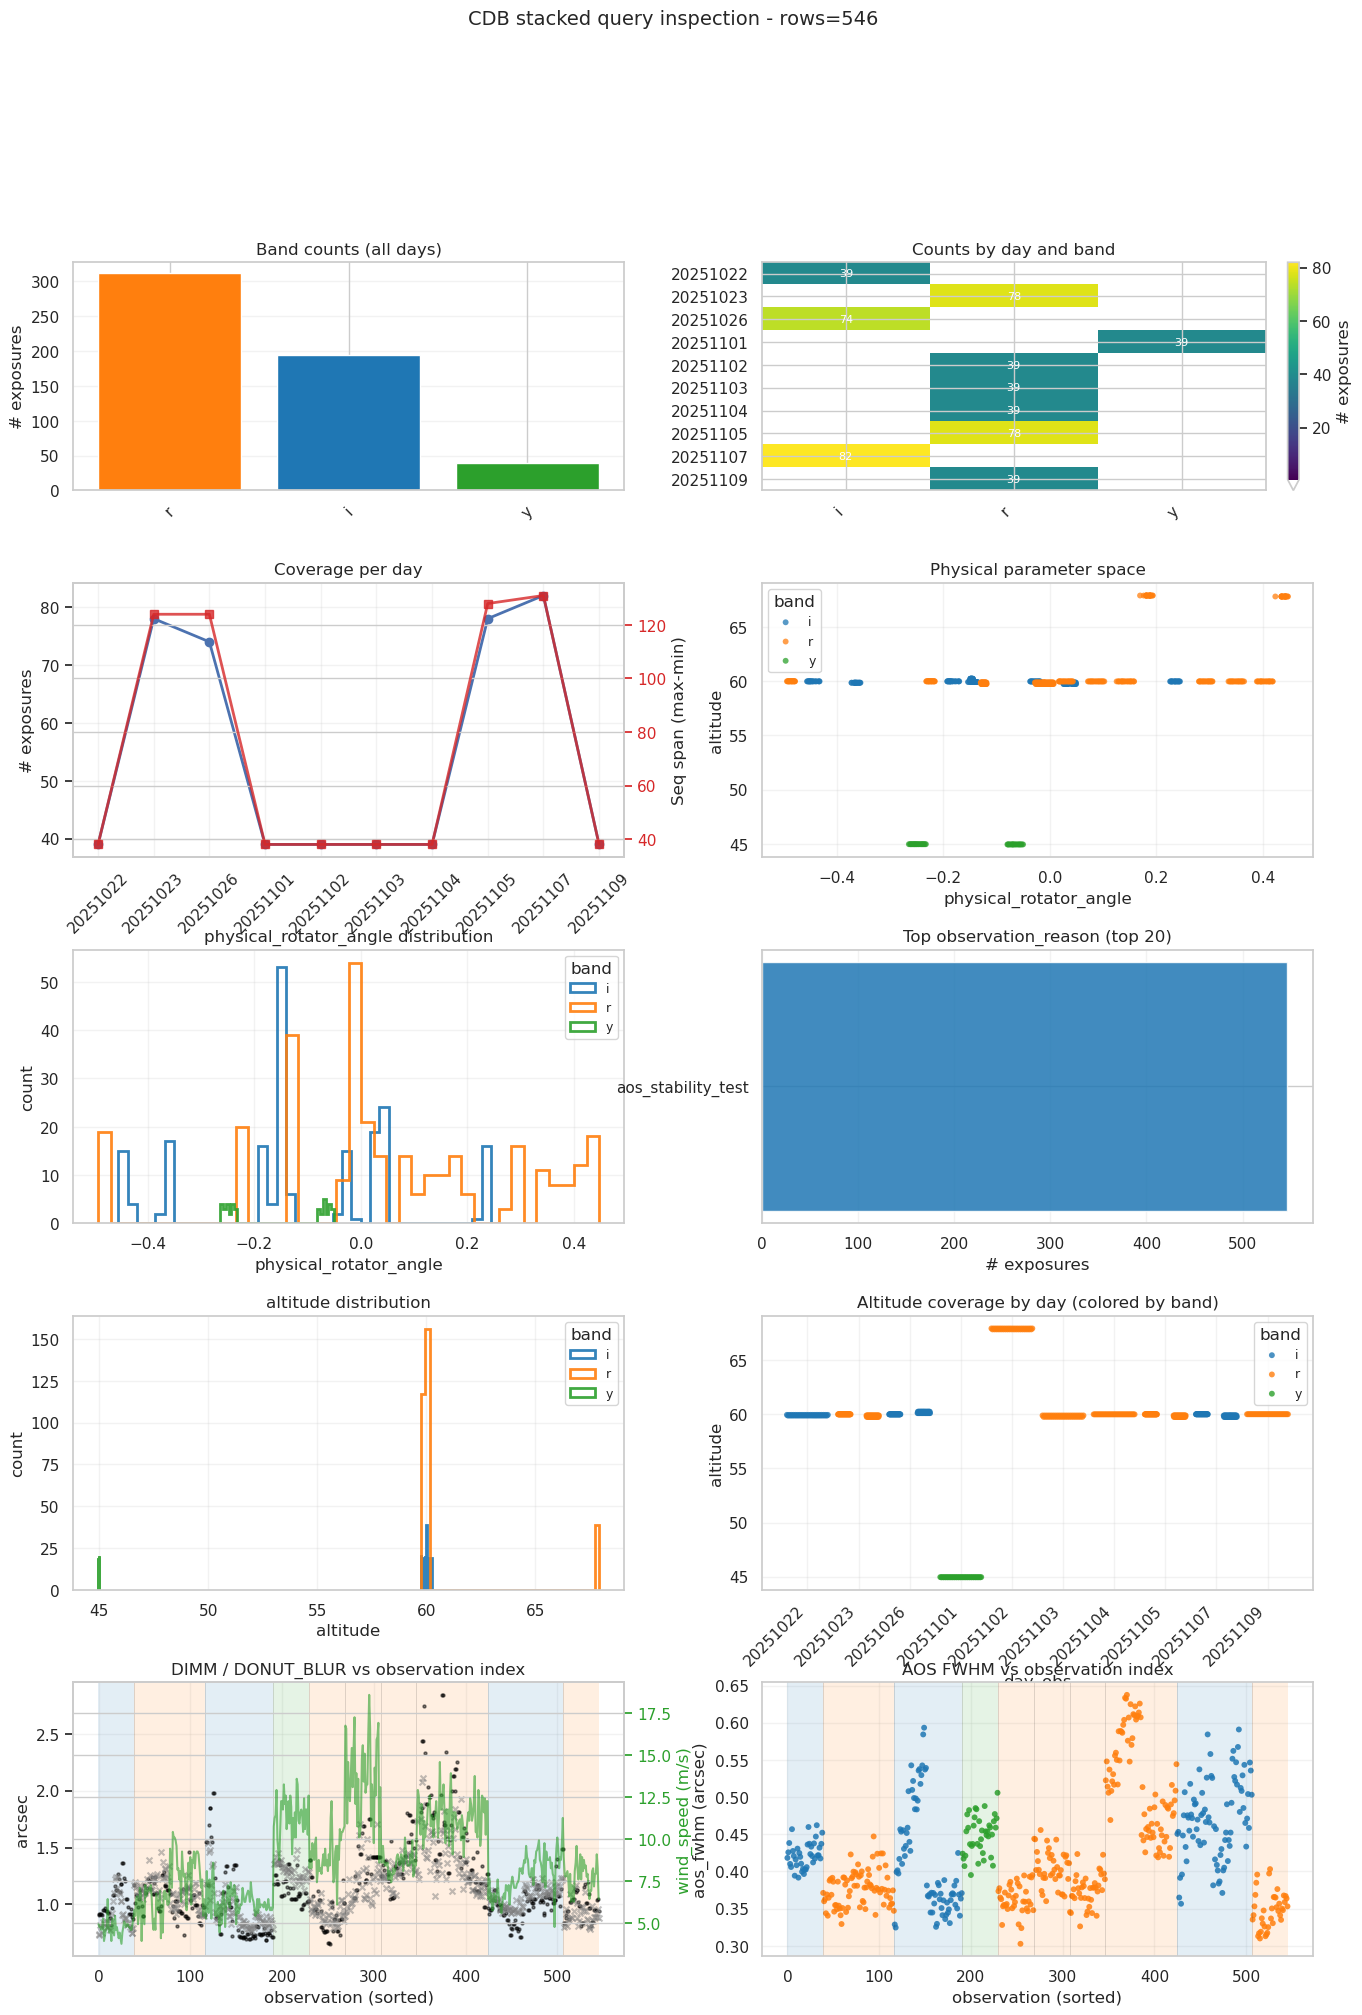

In [62]:
# Physical parameter inspection (all stability nights)
band_counts = cdb_table_all_days['band'].value_counts(dropna=False)
day_band = pd.crosstab(cdb_table_all_days['day_obs'], cdb_table_all_days['band'], dropna=False).reindex(index=days_sorted)
coverage = cdb_table_all_days.groupby('day_obs')['seq'].agg(n='count', seq_min='min', seq_max='max').reindex(days_sorted)

fig = plt.figure(figsize=(16, 22))
gs = fig.add_gridspec(nrows=5, ncols=2, height_ratios=[1.0, 1.2, 1.2, 1.2, 1.2], hspace=0.35, wspace=0.25)

# (1) Band counts
ax1 = fig.add_subplot(gs[0, 0])
x_labels = [str(k) for k in band_counts.index]
x_colors = [band_to_color.get(k, 'gray') if pd.notna(k) else 'lightgray' for k in band_counts.index]
ax1.bar(x_labels, band_counts.values, color=x_colors)
ax1.set_title('Band counts (all days)')
ax1.set_ylabel('# exposures')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(alpha=0.25, axis='y')

# (2) Day x Band heatmap
ax2 = fig.add_subplot(gs[0, 1])
heat = day_band.to_numpy()
masked_heat = np.ma.masked_where(heat == 0, heat)
cmap_hm = plt.get_cmap('viridis').copy()
cmap_hm.set_bad('white')
cmap_hm.set_under('white')
ax2.set_facecolor('white')
im = ax2.imshow(masked_heat, aspect='auto', interpolation='nearest', cmap=cmap_hm, vmin=0.5)
ax2.set_title('Counts by day and band')
ax2.set_yticks(np.arange(day_band.shape[0]))
ax2.set_yticklabels(day_band.index.astype(str))
ax2.set_xticks(np.arange(day_band.shape[1]))
ax2.set_xticklabels([str(c) for c in day_band.columns], rotation=45, ha='right')
fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04, extend='min').set_label('# exposures')
for i in range(day_band.shape[0]):
    for j in range(day_band.shape[1]):
        if heat[i, j] != 0:
            ax2.text(j, i, str(heat[i, j]), ha='center', va='center', color='white', fontsize=8)

# (3) Coverage by day
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(coverage.index.astype(str), coverage['n'], '-o', lw=2)
ax3.set_title('Coverage per day')
ax3.set_ylabel('# exposures')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(alpha=0.25)
ax3b = ax3.twinx()
ax3b.plot(coverage.index.astype(str), coverage['seq_max'] - coverage['seq_min'], '-s', lw=2, color='tab:red', alpha=0.8)
ax3b.set_ylabel('Seq span (max-min)')
ax3b.tick_params(axis='y', colors='tab:red')

# (4) Rotator angle vs altitude
ax4 = fig.add_subplot(gs[1, 1])
for b in bands:
    sub = cdb_table_all_days[cdb_table_all_days['band'] == b]
    ax4.scatter(sub['physical_rotator_angle'], sub['altitude'], s=18, alpha=0.75, label=str(b), color=band_to_color.get(b), edgecolors='none')
ax4.set_title('Physical parameter space')
ax4.set_xlabel('physical_rotator_angle')
ax4.set_ylabel('altitude')
ax4.grid(alpha=0.25)
if len(bands) <= 10:
    ax4.legend(title='band', loc='best', fontsize=9)

# (5) Rotator angle distribution
ax5 = fig.add_subplot(gs[2, 0])
for b in bands:
    vals = cdb_table_all_days[cdb_table_all_days['band'] == b]['physical_rotator_angle'].dropna().to_numpy()
    if len(vals): ax5.hist(vals, bins=40, histtype='step', lw=2, alpha=0.9, label=str(b), color=band_to_color.get(b))
ax5.set_title('physical_rotator_angle distribution')
ax5.set_xlabel('physical_rotator_angle')
ax5.set_ylabel('count')
ax5.grid(alpha=0.25)
if len(bands) <= 10: ax5.legend(title='band', fontsize=9)

# (6) Top observation reasons
ax6 = fig.add_subplot(gs[2, 1])
top_reasons = cdb_table_all_days['observation_reason'].astype(str).value_counts(dropna=False).head(20)
ax6.barh(top_reasons.index[::-1], top_reasons.values[::-1], color='tab:blue', alpha=0.85)
ax6.set_title('Top observation_reason (top 20)')
ax6.set_xlabel('# exposures')
ax6.grid(alpha=0.25, axis='x')

# (7) Altitude distribution
ax7 = fig.add_subplot(gs[3, 0])
for b in bands:
    vals = cdb_table_all_days[cdb_table_all_days['band'] == b]['altitude'].dropna().to_numpy()
    if len(vals): ax7.hist(vals, bins=40, histtype='step', lw=2, alpha=0.9, label=str(b), color=band_to_color.get(b))
ax7.set_title('altitude distribution')
ax7.set_xlabel('altitude')
ax7.set_ylabel('count')
ax7.grid(alpha=0.25)
if len(bands) <= 10: ax7.legend(title='band', fontsize=9)

# (8) Altitude by day
ax8 = fig.add_subplot(gs[3, 1])
for i, day in enumerate(days_sorted):
    day_df = cdb_table_all_days[cdb_table_all_days['day_obs'] == day].copy()
    if len(day_df) == 0: continue
    s_min, s_max = day_df['seq'].min(), day_df['seq'].max()
    denom = (s_max - s_min) if s_max != s_min else 1
    for b in bands:
        sub = day_df[day_df['band'] == b]
        if len(sub) == 0: continue
        sub_x = i + (sub['seq'] - s_min) / denom * 0.8 - 0.4
        ax8.scatter(sub_x, sub['altitude'], s=18, alpha=0.8, color=band_to_color.get(b), edgecolors='none', label=str(b))
handles, labels = ax8.get_legend_handles_labels()
dedup = {}
for h, l in zip(handles, labels): dedup.setdefault(l, h)
if len(dedup) <= 10: ax8.legend(dedup.values(), dedup.keys(), title='band', loc='best', fontsize=9)
ax8.set_xticks(range(len(days_sorted)))
ax8.set_xticklabels([str(d) for d in days_sorted], rotation=45, ha='right')
ax8.set_xlabel('day_obs')
ax8.set_ylabel('altitude')
ax8.set_title('Altitude coverage by day (colored by band)')
ax8.grid(alpha=0.25)

# (9-10) Seeing / blur vs observation index
df_sorted = cdb_table_all_days.copy().sort_values(['day_obs', 'seq'])
ensure_numeric_columns(df_sorted, ['dimm_seeing', 'aos_fwhm', 'donut_blur_fwhm', 'wind_speed'])
x = np.arange(len(df_sorted))
bl = df_sorted['band'].astype(str)
cm = {str(b): band_to_color.get(b, 'gray') for b in bands}
day_vals = df_sorted['day_obs'].to_numpy()
day_change = np.where(day_vals[1:] != day_vals[:-1])[0] + 1

ax9 = fig.add_subplot(gs[4, 0])
_add_filter_bands(ax9, bl, cm, alpha=0.12)
ax9.scatter(x, df_sorted['dimm_seeing'], marker='.', s=18, alpha=0.5, c='black', label='dimm_seeing')
ax9.scatter(x, df_sorted['donut_blur_fwhm'], marker='x', s=18, alpha=0.5, c='gray', label='donut_blur')
if 'wind_speed' in df_sorted.columns:
    ax9b = ax9.twinx()
    wind = pd.to_numeric(df_sorted['wind_speed'], errors='coerce')
    if wind.notna().any():
        ax9b.plot(x, wind.to_numpy(), color='tab:green', lw=1.5, alpha=0.6)
        ax9b.set_ylabel('wind_speed (m/s)', color='tab:green')
        ax9b.tick_params(axis='y', colors='tab:green')
for idx in day_change: ax9.axvline(idx - 0.5, color='k', lw=0.5, alpha=0.2)
ax9.set_title('DIMM / DONUT_BLUR vs observation index')
ax9.set_xlabel('observation (sorted)')
ax9.set_ylabel('arcsec')
ax9.grid(alpha=0.25)

ax10 = fig.add_subplot(gs[4, 1], sharex=ax9)
_add_filter_bands(ax10, bl, cm, alpha=0.12)
ax10.scatter(x, df_sorted['aos_fwhm'], s=18, alpha=0.85, c=bl.map(lambda v: cm.get(v, 'gray')), edgecolors='none')
for idx in day_change: ax10.axvline(idx - 0.5, color='k', lw=0.5, alpha=0.2)
ax10.set_title('AOS FWHM vs observation index')
ax10.set_xlabel('observation (sorted)')
ax10.set_ylabel('aos_fwhm (arcsec)')
ax10.grid(alpha=0.25)

fig.suptitle(f'CDB stacked query inspection - rows={len(cdb_table_all_days)}', y=0.995, fontsize=14)
physical_params_fig = fig  # for technote export
plt.show()

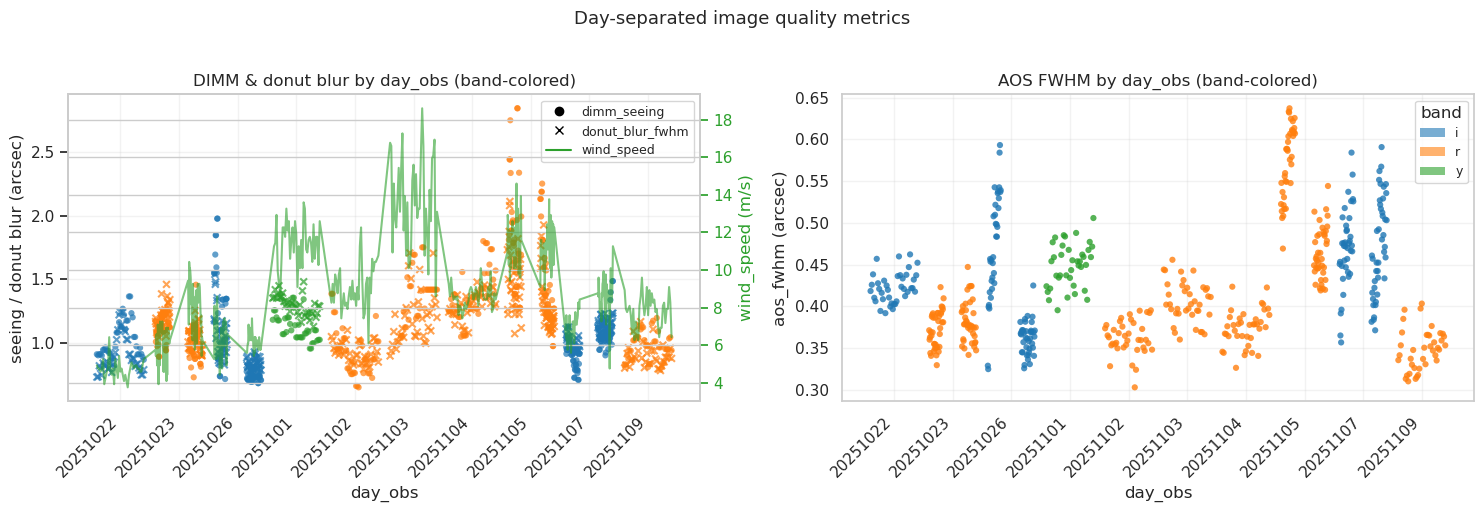

In [63]:
# Day-separated seeing / AOS metrics (band-colored)
selected_day_obs = None  # or list of day_obs ints
x_span = 0.8
df = cdb_table_all_days.copy()
if selected_day_obs is not None:
    df = df[df['day_obs'].astype(int).isin(set(int(d) for d in selected_day_obs))].copy()
df, bands_loc, btc = normalize_band_column(df)
ensure_numeric_columns(df)
df = df.sort_values(['day_obs', 'seq']).reset_index(drop=True)
ds = sorted(df['day_obs'].dropna().unique())
point_colors = df['band'].map(lambda v: btc.get(v, 'gray')).to_numpy()

x = np.full(len(df), np.nan, dtype=float)
for i, day in enumerate(ds):
    sub = df[df['day_obs'] == day]
    if len(sub) == 0: continue
    s_min, s_max = sub['seq'].min(), sub['seq'].max()
    denom = (s_max - s_min) if s_max != s_min else 1.0
    x[sub.index.values] = i + (sub['seq'] - s_min) / denom * x_span - x_span / 2.0

fig, (ax9, ax10) = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
ax9.scatter(x, df['dimm_seeing'], marker='o', s=20, alpha=0.7, c=point_colors, edgecolors='none')
ax9.scatter(x, df['donut_blur_fwhm'], marker='x', s=24, alpha=0.7, c=point_colors)
ax9.set_ylabel('seeing / donut blur (arcsec)')
ax9.set_title('DIMM & donut blur by day_obs (band-colored)')
ax9.grid(alpha=0.25)
ax9b = ax9.twinx()
wind = pd.to_numeric(df['wind_speed'], errors='coerce')
if wind.notna().any():
    ax9b.plot(x, wind.to_numpy(), color='tab:green', lw=1.5, alpha=0.6)
    ax9b.set_ylabel('wind_speed (m/s)', color='tab:green')
    ax9b.tick_params(axis='y', colors='tab:green')
ax10.scatter(x, df['aos_fwhm'], s=20, alpha=0.8, c=point_colors, edgecolors='none')
ax10.set_ylabel('aos_fwhm (arcsec)')
ax10.set_title('AOS FWHM by day_obs (band-colored)')
ax10.grid(alpha=0.25)
for ax in (ax9, ax10):
    ax.set_xticks(range(len(ds)))
    ax.set_xticklabels([str(d) for d in ds], rotation=45, ha='right')
    ax.set_xlabel('day_obs')
band_handles = [Patch(facecolor=btc.get(b, 'gray'), edgecolor='none', alpha=0.6, label=str(b)) for b in bands_loc]
marker_handles = [
    Line2D([], [], marker='o', color='black', linestyle='None', markersize=6, label='dimm_seeing'),
    Line2D([], [], marker='x', color='black', linestyle='None', markersize=6, label='donut_blur_fwhm'),
    Line2D([], [], color='tab:green', lw=1.5, label='wind_speed'),
]
if band_handles: ax10.legend(handles=band_handles, title='band', loc='best', fontsize=9)
ax9.legend(handles=marker_handles, loc='best', fontsize=9)
title_suffix = '' if selected_day_obs is None else f' (days={sorted(set(selected_day_obs))})'
fig.suptitle('Day-separated image quality metrics' + title_suffix, y=1.02, fontsize=13)
plt.tight_layout()
seeing_metrics_fig = fig  # for technote export
plt.show()

### Detrending diagnostics

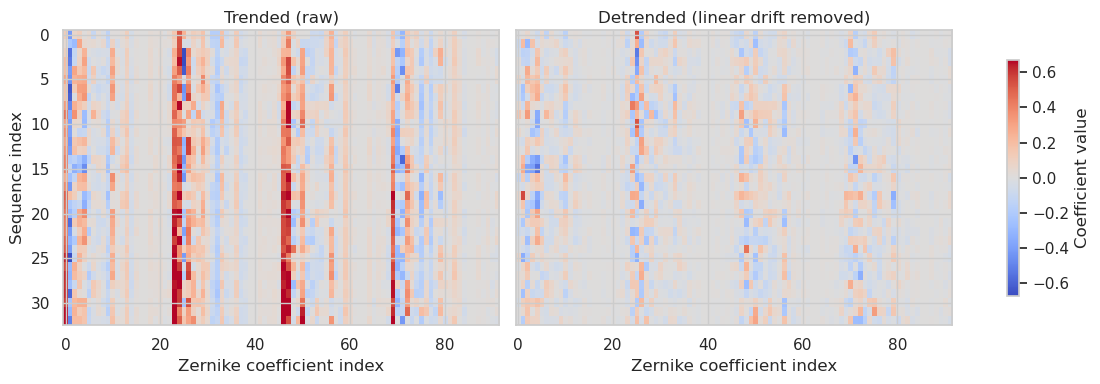

In [64]:
# Compare one block before/after detrending
valid_trended = [a for a in trended_days if a is not None]
if len(valid_trended) == 0:
    print("No trended data available to plot.")
else:
    arr = valid_trended[0]
    arr_det = detrend_block(arr)
    vlim = np.nanpercentile(np.abs(arr), 99)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    im0 = axes[0].imshow(arr, aspect="auto", cmap="coolwarm", vmin=-vlim, vmax=vlim)
    axes[0].set_title("Trended (raw)")
    axes[0].set_ylabel("Sequence index")
    axes[0].set_xlabel("Zernike coefficient index")
    im1 = axes[1].imshow(arr_det, aspect="auto", cmap="coolwarm", vmin=-vlim, vmax=vlim)
    axes[1].set_title("Detrended (linear drift removed)")
    axes[1].set_xlabel("Zernike coefficient index")
    plt.tight_layout()
    fig.colorbar(im0, ax=axes.ravel().tolist(), shrink=0.8, label="Coefficient value")

detrend_fig = fig  # for technote export

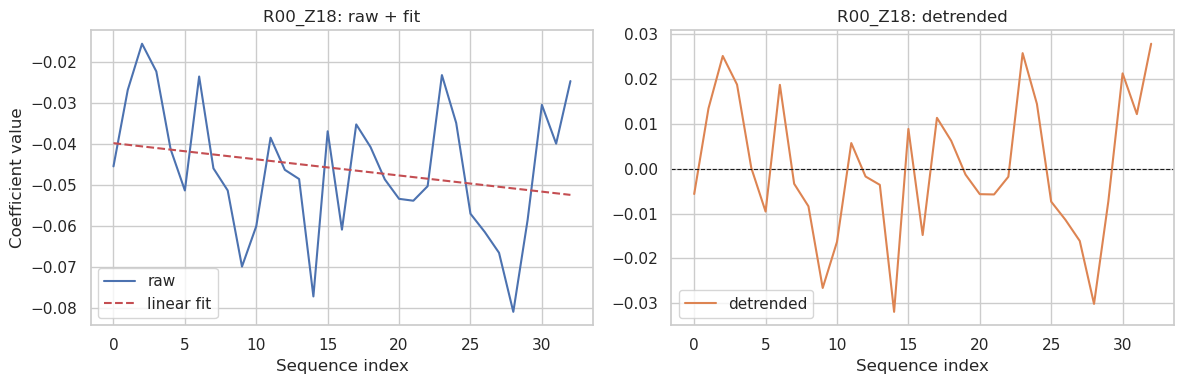

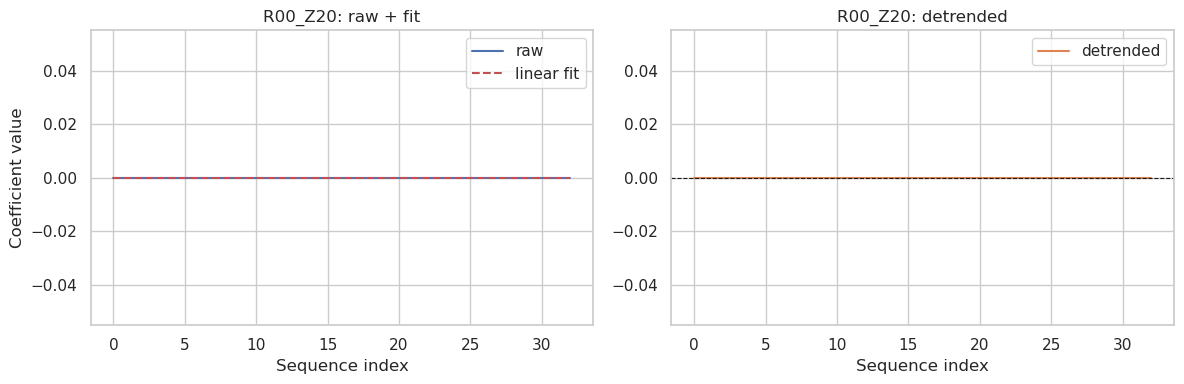

In [65]:
# Plot a single coefficient before/after detrending
plot_single_coeff(block_idx=0, detector="R00", zernike=18, manifest=manifest, trended_days=trended_days)
plot_single_coeff(block_idx=0, detector="R00", zernike=20, manifest=manifest, trended_days=trended_days)

### Build Covariance Matrix

Choose which data to use (detrended/trended), build cumulative covariances, and check convergence.

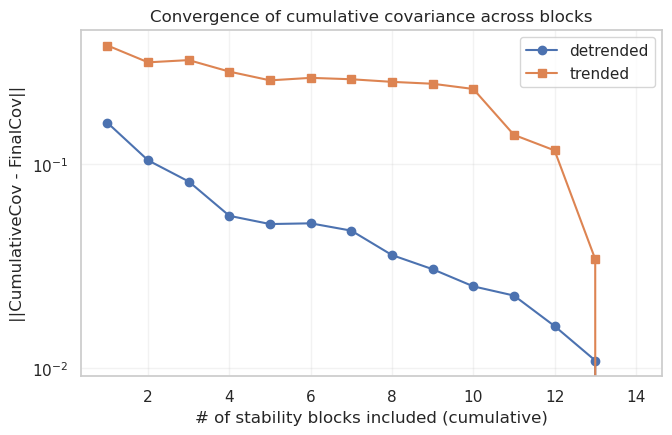

[cov] COV_SOURCE=detrended, combined_all samples=540
[cov] ||final - recomputed||_F = 0.000e+00


In [66]:
# Build cumulative covariance sequences for BOTH sources (for comparison)
blocks_detrended = detrended_days
blocks_trended = [a for a in trended_days if a is not None]

if len(blocks_detrended) == 0:
    raise ValueError("No detrended blocks available.")
if len(blocks_trended) == 0:
    raise ValueError("No trended blocks available.")

cov_det = build_cumulative_covariances(blocks_detrended)
cov_tr = build_cumulative_covariances(blocks_trended)

final_det = cov_det[max(cov_det.keys())]
final_tr = cov_tr[max(cov_tr.keys())]

fro_det = [np.linalg.norm(c - final_det) for _, c in sorted(cov_det.items())]
fro_tr = [np.linalg.norm(c - final_tr) for _, c in sorted(cov_tr.items())]

plt.figure(figsize=(7.5, 4.5))
plt.semilogy(range(1, len(fro_det) + 1), fro_det, "-o", label="detrended")
plt.semilogy(range(1, len(fro_tr) + 1), fro_tr, "-s", label="trended")
plt.xlabel("# of stability blocks included (cumulative)")
plt.ylabel("||CumulativeCov - FinalCov||")
plt.title("Convergence of cumulative covariance across blocks")
plt.grid(alpha=0.25)
plt.legend()
cumcov_fig = fig  # for technote export
plt.show()

# Select which covariance is used downstream
if COV_SOURCE == "detrended":
    covariances_for_plots = cov_det
    blocks_for_cov = blocks_detrended
else:
    covariances_for_plots = cov_tr
    blocks_for_cov = blocks_trended

final = covariances_for_plots[max(covariances_for_plots.keys())]
combined_all = np.vstack(blocks_for_cov)
final_recomputed = np.cov(combined_all, rowvar=False)
print(f"[cov] COV_SOURCE={COV_SOURCE}, combined_all samples={combined_all.shape[0]}")
print(f"[cov] ||final - recomputed||_F = {np.linalg.norm(final - final_recomputed):.3e}")

### Remap & Canonicalize Covariance

Remap from Z4-Z26 to Z4-Z28 (missing/zero-raw modes get diag=1, offdiag=0), then immediately permute to canonical ts_ofc corner order. After this cell, everything is in CORNERS order.

In [67]:
# Remap Z4-Z26 -> Z4-Z28 and canonicalize corner order in ONE step
C_new = remap_covariance(
    final, current_indices, target_indices,
    n_det=4, zero_raw_zernikes=zero_raw_zernikes,
)
C_new = permute_cov_by_corner(
    C_new,
    corner_from=CORNERS_RAW,
    corner_to=CORNERS,
    nZ=len(target_indices),
)
print(f"C_new shape: {C_new.shape}")
print(f"Corner order: {CORNERS} (canonical ts_ofc)")
print(f"Zernike range: Z{target_indices[0]}..Z{target_indices[-1]} ({len(target_indices)} modes)")

C_new shape: (100, 100)
Corner order: ['R00', 'R04', 'R40', 'R44'] (canonical ts_ofc)
Zernike range: Z4..Z28 (25 modes)


### Plot Covariance Matrix (canonical order)

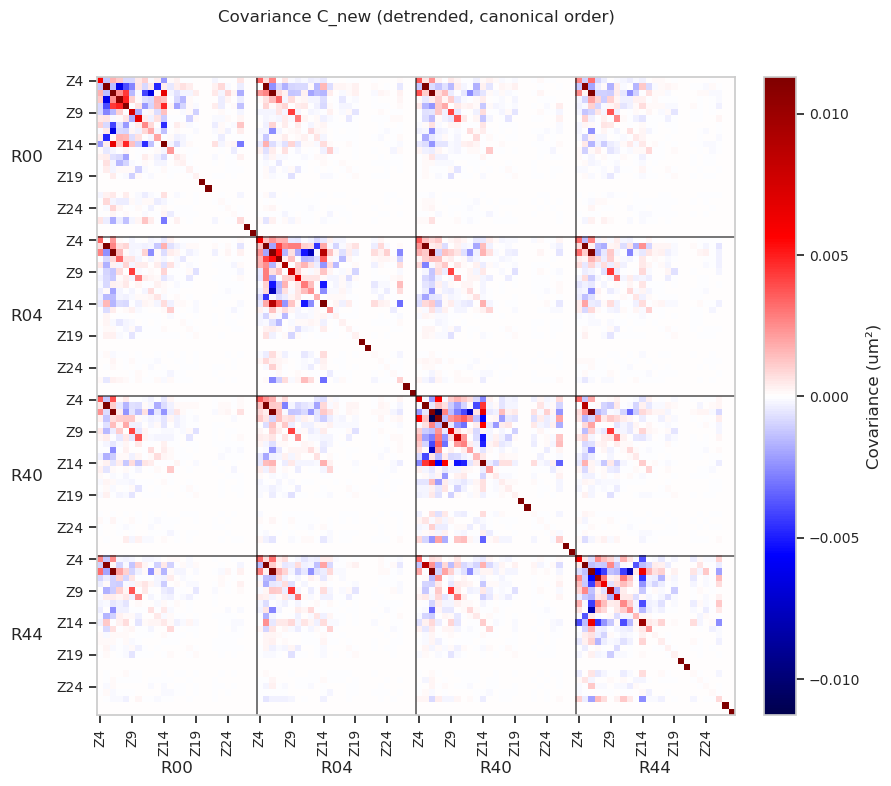

In [68]:
# Plot remapped + canonicalized covariance
fig, ax = plt.subplots(figsize=(9, 8))
im = plot_matrix_heatmap(
    ax, C_new,
    z_list=target_indices,
    corner_labels=CORNERS,
    title=f"Covariance C_new ({COV_SOURCE}, canonical order)",
    mode="cov",
    tick_step=5,
    title_pad=40,
    tick_fontsize=10,
    corner_fontsize=12,
)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Covariance (um\u00b2)", fontsize=12)
cbar.ax.tick_params(labelsize=10)
plt.tight_layout()
cov_canonical_fig = fig  # for technote export
plt.show()

### Export Covariance to YAML

In [69]:
# Export C_new (canonical order) to YAML
yaml_path = "covariance_state_estimation/onsky_stability_covariance_all.yaml"

n_zk = C_new.shape[0] // len(CORNERS)
n_corners = len(CORNERS)

with open(yaml_path, "w") as yaml_file:
    yaml_file.write(
        "--- \n"
        " # Measurement noise covariance matrix.\n"
        f" # Dimensions: ({n_zk}*{n_corners},{n_zk}*{n_corners}) = ({C_new.shape[0]},{C_new.shape[1]})."
        f" From j_min = 4 to j_max = {4 + n_zk - 1}.\n"
        f" # Corner order: {CORNERS} (canonical ts_ofc)\n"
        " #\n"
        " # Each row is a YAML array '- [...]' representing one row of the\n"
        " # covariance matrix. The indexing is blocked by corner, with\n"
        f" # {n_zk} Zernikes (Z4\u2013Z{4 + n_zk - 1}) per corner:\n"
        " #\n"
        " #   Row indices  |  Meaning\n"
        " #   -------------|-------------------\n"
        f" #   0\u2013{n_zk - 1}          |  Z4\u2013Z{4 + n_zk - 1} at corner {CORNERS[0]}\n"
        f" #   {n_zk}\u2013{2*n_zk - 1}         |  Z4\u2013Z{4 + n_zk - 1} at corner {CORNERS[1]}\n"
        f" #   {2*n_zk}\u2013{3*n_zk - 1}         |  Z4\u2013Z{4 + n_zk - 1} at corner {CORNERS[2]}\n"
        f" #   {3*n_zk}\u2013{4*n_zk - 1}         |  Z4\u2013Z{4 + n_zk - 1} at corner {CORNERS[3]}\n"
        " #\n"
        " # Element [i][j] = Cov(Zk_a @ corner_m, Zk_b @ corner_n).\n"
        " # Diagonal elements [i][i] are the variances.\n"
        " #\n"
        " # These values were generated from on-sky stability tests.\n"
        " # In particular the following data was used:\n"
        " # Night \u2192 Sequence ranges:\n"
        " #\n"
        " # 2025-10-26 : 378\u2013412, 464\u2013502\n"
        " # 2025-10-22 : 206\u2013244\n"
        " # 2025-10-23 : 242\u2013280, 156\u2013194\n"
        " # 2025-11-01 : 308\u2013346\n"
        " # 2025-11-02 : 166\u2013204\n"
        " # 2025-11-03 : 382\u2013420\n"
        " # 2025-11-04 : 225\u2013263\n"
        " # 2025-11-05 : 221\u2013260, 132\u2013170\n"
        " # 2025-11-07 : 66\u2013104, 155\u2013197\n"
        " # 2025-11-09 : 144\u2013182\n"
        " # Units: um^2 of Zk\n"
        "\n"
        "\n"
    )
    for row in C_new.tolist():
        yaml_file.write("- [" + ", ".join(map(str, row)) + "]\n")
print(f"Exported C_new to {yaml_path}")

Exported C_new to covariance_state_estimation/onsky_stability_covariance_all.yaml


## Obtain DOFs and Compare Results

### Query ConsDB and setup

In [70]:
# --- Phase 2 config ---
day = dof_day
seq_min = dof_seq_min
seq_max = dof_seq_max
use_dof = parse_dof_str(use_dof_str)

# --- ConsDB query ---
cdb_client = ConsDbClient(CONSDB_URL)
query = _build_cdb_query(day, seq_min, seq_max)
cdb_table_all = cdb_client.query(query).to_pandas()
print(f"Queried day={day}, seq={seq_min}-{seq_max}: {len(cdb_table_all)} rows")

Queried day=20251109, seq=144-183: 40 rows


In [71]:
# Setup butler, EFD client, and fetcher
butler = makeDefaultButler("LSSTCam")
efd_client = EfdClient("summit_efd")
fetcher = ofcUtils.AOSFetcher(butler, efd_client, config_dir=OFC_CONFIG_DIR)

nZ_expected = C_new.shape[0] // len(corner_detnames)
print(f"nZ_expected={nZ_expected}, corner_detnames={corner_detnames}")

nZ_expected=25, corner_detnames=['R00_SW0', 'R04_SW0', 'R40_SW0', 'R44_SW0']


### Processing States: DOFs

In [25]:
# State estimation: measured covariance vs no covariance
cdb_day = cdb_table_all[cdb_table_all["day_obs"] == day].sort_values("seq")
seqs_list = cdb_day["seq"].to_numpy()

states_cov_list = []
states_nocov_list = []
bands_array, seqs_array, rots_array, els_array = [], [], [], []

for seq in tqdm(seqs_list, desc=f"Processing day {day}"):
    cdb_seq = cdb_day[cdb_day["seq"] == seq]
    if cdb_seq.empty:
        continue

    try:
        zernikes, zernike_array, noll_indices, sensor_names = fetcher.get_zernikes(
            _obs_id_for_seq(day, seq)
        )
        zernike_array = align_zernikes_to_corner_detnames(
            zernike_array,
            sensor_names=sensor_names,
            detnames=corner_detnames,
            nZ_expected=nZ_expected,
        )
    except Exception:
        continue

    rtp = cdb_seq["physical_rotator_angle"].iloc[0]
    band = cdb_seq["band"].iloc[0]

    state_cov = get_state(zernike_array, rtp=rtp, use_dof=use_dof, nkeep=nkeep, band=band, noise_covariance=C_new)
    state_nocov = get_state(zernike_array, rtp=rtp, use_dof=use_dof, nkeep=nkeep, band=band, noise_covariance=None)

    states_cov_list.append(-state_cov)
    states_nocov_list.append(-state_nocov)
    bands_array.append(band)
    seqs_array.append(seq)
    rots_array.append(rtp)
    els_array.append(cdb_seq["altitude"].iloc[0])

states_cov_array = np.asarray(states_cov_list)
states_nocov_array = np.asarray(states_nocov_list)
print(f"Processed {len(seqs_array)} sequences successfully")

Processing day 20251109:   0%|          | 0/40 [00:00<?, ?it/s]

Processing day 20251109:   2%|▎         | 1/40 [00:10<06:48, 10.47s/it]

Processing day 20251109:   5%|▌         | 2/40 [00:20<06:32, 10.32s/it]

Processing day 20251109:   8%|▊         | 3/40 [00:30<06:18, 10.24s/it]

Processing day 20251109:  10%|█         | 4/40 [00:41<06:16, 10.45s/it]

...

Processing day 20251109:  92%|█████████▎| 37/40 [06:25<00:31, 10.47s/it]

Processing day 20251109:  95%|█████████▌| 38/40 [06:35<00:20, 10.42s/it]

Processing day 20251109:  98%|█████████▊| 39/40 [06:46<00:10, 10.38s/it]

Processing day 20251109: 100%|██████████| 40/40 [06:57<00:00, 10.43s/it]

Processed 40 sequences successfully


### Plotting DOFs: DOF distribution comparison

Compute and/or plot DOF state distributions comparing measured covariance vs Cov=False.

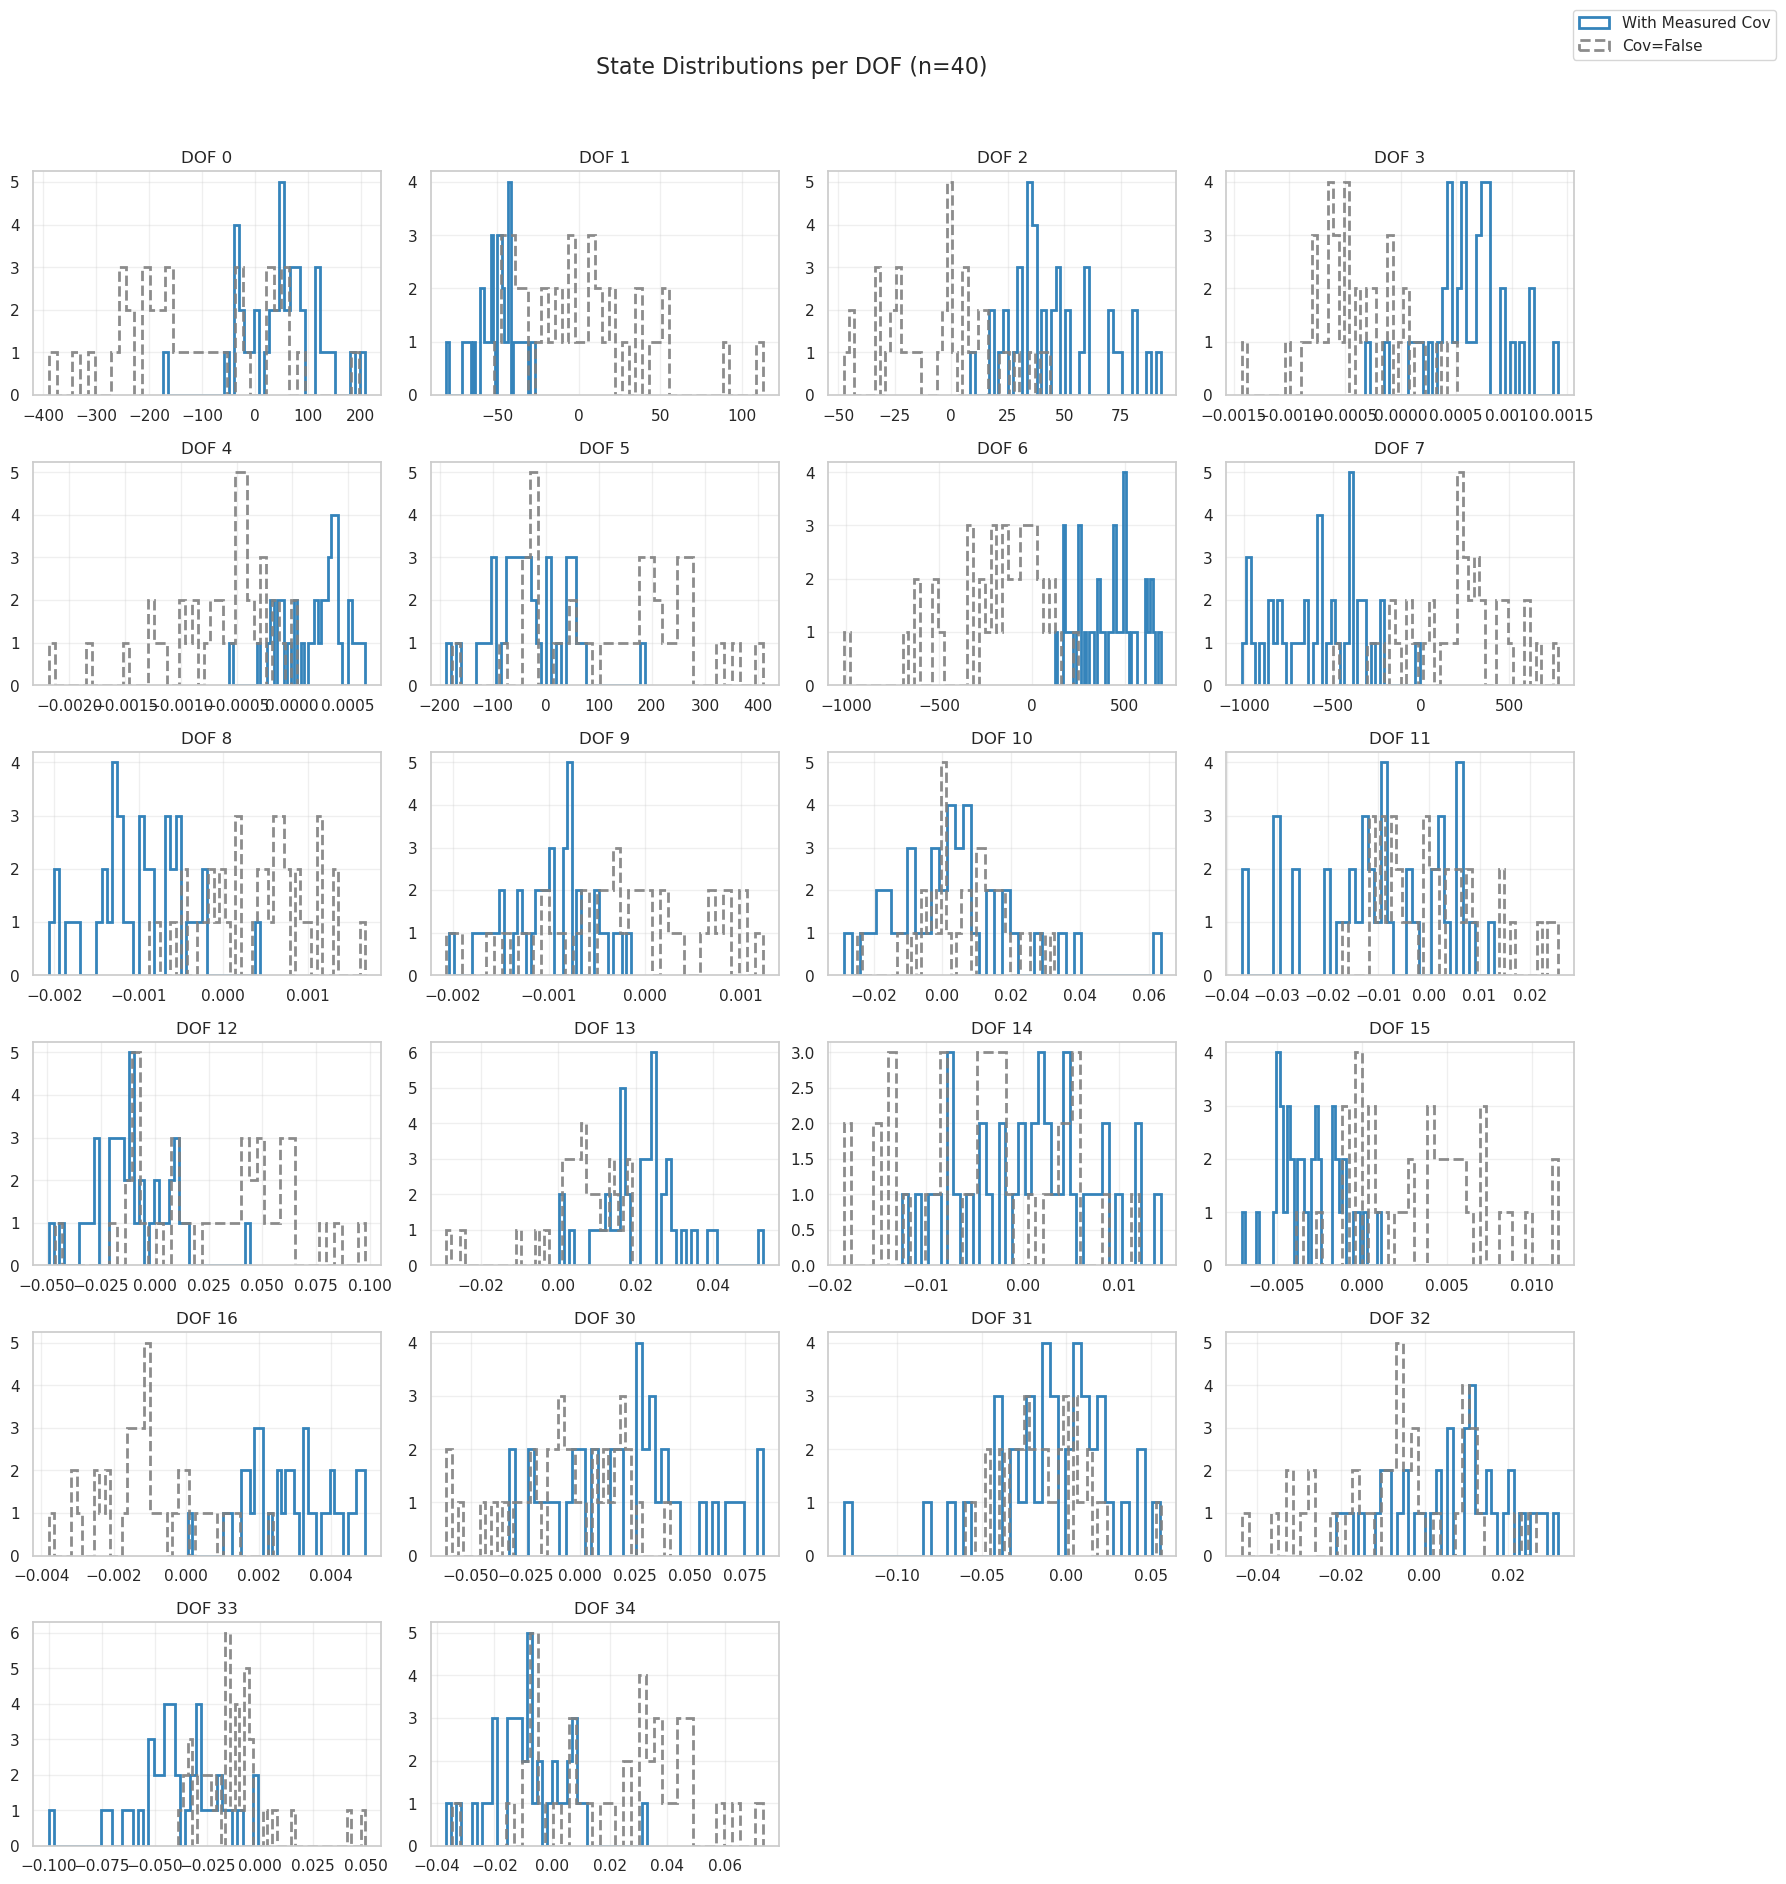

In [72]:
# Plot per-DOF state distributions
arrays_dict = {
    "With Measured Cov": (states_cov_array, "tab:blue", "-"),
    "Cov=False": (states_nocov_array, "gray", "--"),
}
fig = plot_dof_histograms(arrays_dict, list(use_dof), title="State Distributions per DOF")
plt.show()

# Corner Zernike Analysis (pre-covariance)

Inspect per-corner Zernike coefficient time series directly.
Quantify how strongly the same Zernike mode is shared across corners.

**Run order:** config -> load table -> compute metrics -> plots.

In [73]:
# --- CONFIG ---
ts_corner_day_value = int(dof_day) if ts_corner_day_mode == 'single' else None

# Resolve Zernike selection
if ts_corner_zernikes and len(ts_corner_zernikes) > 0:
    ts_corner_z_list = sorted(set(int(z) for z in ts_corner_zernikes))
else:
    ts_corner_z_list = list(range(ts_corner_z_min, ts_corner_z_max + 1))

print(f"[corner] source={ts_corner_source}, zernikes={ts_corner_z_list}, "
      f"detectors={ts_corner_detectors}")

[corner] source=detrended, zernikes=[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 22], detectors=['R00', 'R04', 'R40', 'R44']


In [74]:
# Load corner coefficient table
kind = ts_corner_source.strip().lower()
df_corner = _corner_load_combined(cache_dir, kind)
if df_corner is None:
    print(f"[corner] combined CSV not found; falling back to stacking {kind} blocks")
    df_corner = _corner_load_from_blocks(kind)

# Day filtering
if ts_corner_day_mode == 'single' and ts_corner_day_value is not None and 'day_obs' in df_corner.columns:
    df_corner = df_corner[df_corner['day_obs'] == int(ts_corner_day_value)].copy()

# Optional row limit
if ts_corner_max_rows is not None:
    df_corner = df_corner.iloc[:int(ts_corner_max_rows)].copy()

print(f'[corner] rows={len(df_corner)}, cols={len(df_corner.columns)}')

[corner] rows=540, cols=95


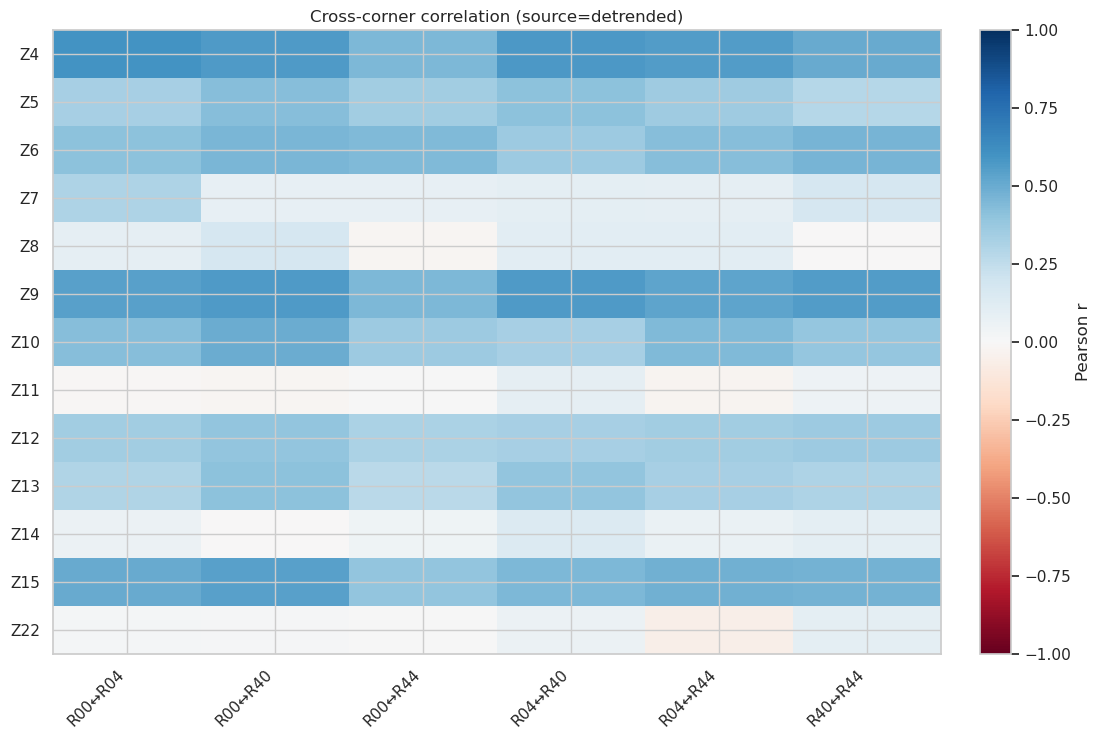

In [75]:
# Compute cross-corner correlation metrics
zerns = list(ts_corner_z_list)
dets = list(ts_corner_detectors)
required_cols = corner_zernike_columns(dets, zerns)
missing_cols = [c for c in required_cols if c not in df_corner.columns]
if missing_cols:
    raise RuntimeError(f'[corner] Missing columns: {missing_cols[:15]}')

X = {d: df_corner[[f"{d}_Z{z}" for z in zerns]].to_numpy(dtype=float) for d in dets}
pairs = list(combinations(dets, 2))
pair_labels = [f"{a}\u2194{b}" for a, b in pairs]

R = np.full((len(zerns), len(pairs)), np.nan)
D_rms = np.full((len(zerns), len(pairs)), np.nan)

for pj, (a, b) in enumerate(pairs):
    for zi, z in enumerate(zerns):
        R[zi, pj] = _pearsonr_safe(X[a][:, zi], X[b][:, zi])
        m = np.isfinite(X[a][:, zi]) & np.isfinite(X[b][:, zi])
        if np.sum(m) >= 1:
            D_rms[zi, pj] = float(np.sqrt(np.mean((X[a][m, zi] - X[b][m, zi]) ** 2)))

# Heatmap: correlation per Z and per corner-pair
fig, ax = plt.subplots(1, 1, figsize=(1.2 * len(pairs) + 4, 0.35 * len(zerns) + 3))
im = ax.imshow(R, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
ax.set_title(f"Cross-corner correlation (source={ts_corner_source})")
ax.set_xticks(np.arange(len(pairs)))
ax.set_xticklabels(pair_labels, rotation=45, ha='right')
ax.set_yticks(np.arange(len(zerns)))
ax.set_yticklabels([f"Z{z}" for z in zerns])
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')
plt.tight_layout()
cross_corner_fig = fig  # for technote export
plt.show()

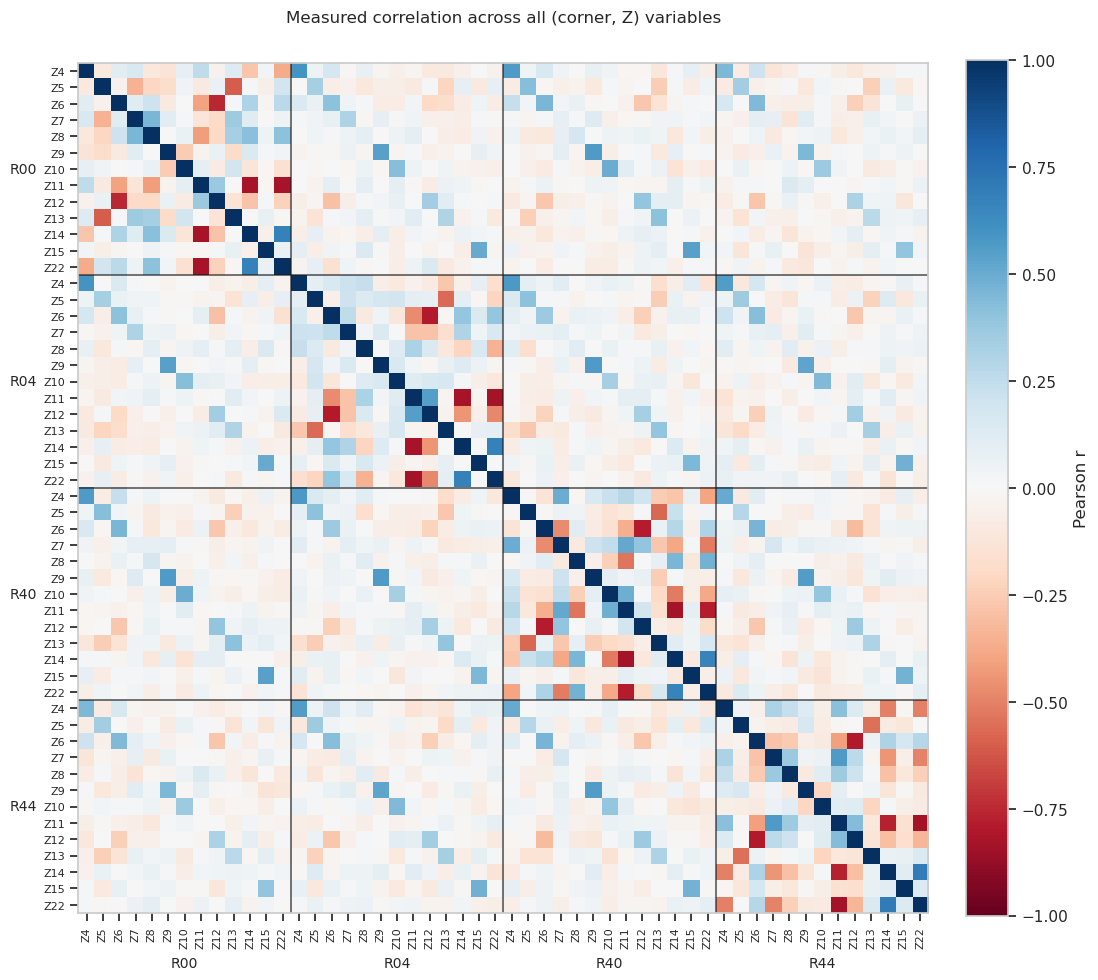

In [78]:
# Full correlation matrix across all (corner, Z) variables
cols_all = corner_zernike_columns(dets, zerns)
Ccorr_meas, n_rows = compute_correlation_matrix(df_corner, cols_all)
if Ccorr_meas is not None:
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    im = plot_matrix_heatmap(ax, Ccorr_meas, zerns, dets,
                             'Measured correlation across all (corner, Z) variables',
                             mode='corr', corner_label_pad=3)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')
    full_corr_fig = fig  # for technote export
    plt.show()
else:
    print(f"[corner] Not enough rows ({n_rows}) for full correlation matrix.")

# Wavefront Covariance Matrix from LSST Simulations

Matlab file provided by Bo Xin. Angular Zernikes in Noll convention, units in nm.
Simulation performed at 770 nm.

In [79]:
# Load the simulated covariance matrix
mat = scipy.io.loadmat('covM86.mat')

# Diagonal RMS (nm)
diag_sim = np.zeros(19 * 4)
for i in range(4):
    for iZ in range(4, 22 + 1):
        diag_sim[iZ - 4 + 19 * i] = np.sqrt(mat['covM'][iZ - 4 + 19 * i, iZ - 4 + 19 * i])

for iZ in range(4, 11 + 1):
    mean_z = np.mean([diag_sim[iZ - 4 + 19 * c] for c in range(4)])
    print(f"<Z{iZ}> = {mean_z:6.0f} nm")

<Z4> =     39 nm
<Z5> =     87 nm
<Z6> =    105 nm
<Z7> =     30 nm
<Z8> =     28 nm
<Z9> =     44 nm
<Z10> =     44 nm
<Z11> =      6 nm


In [80]:
# Inspect .mat contents
mat_keys = [k for k in mat.keys() if not k.startswith('__')]
print('MAT keys:', mat_keys)
for k in mat_keys:
    v = mat[k]
    if isinstance(v, np.ndarray):
        print(f"  {k}: shape={v.shape}, dtype={v.dtype}")

# Check for string arrays (corner labels)
str_arrays = _extract_string_arrays(mat)
if not str_arrays:
    print("[mat order] No string arrays found (no explicit corner labels).")
else:
    for k, arr in str_arrays:
        flat = [str(x).strip() for x in np.ravel(arr) if str(x).strip()]
        print(f"  {k}: shape={arr.shape} preview={flat[:20]}")

MAT keys: ['covM', 'corC']
  covM: shape=(76, 76), dtype=float64
  corC: shape=(76, 76), dtype=float64
[mat order] No string arrays found (no explicit corner labels).


In [81]:
# Build C_sim assuming canonical order (CORNERS), units um^2
C_sim = build_sim_covariance_for_target(mat, z_target=Z_TARGET)
print(f"C_sim shape: {C_sim.shape}, corner order: {CORNERS}")

C_sim shape: (100, 100), corner order: ['R00', 'R04', 'R40', 'R44']


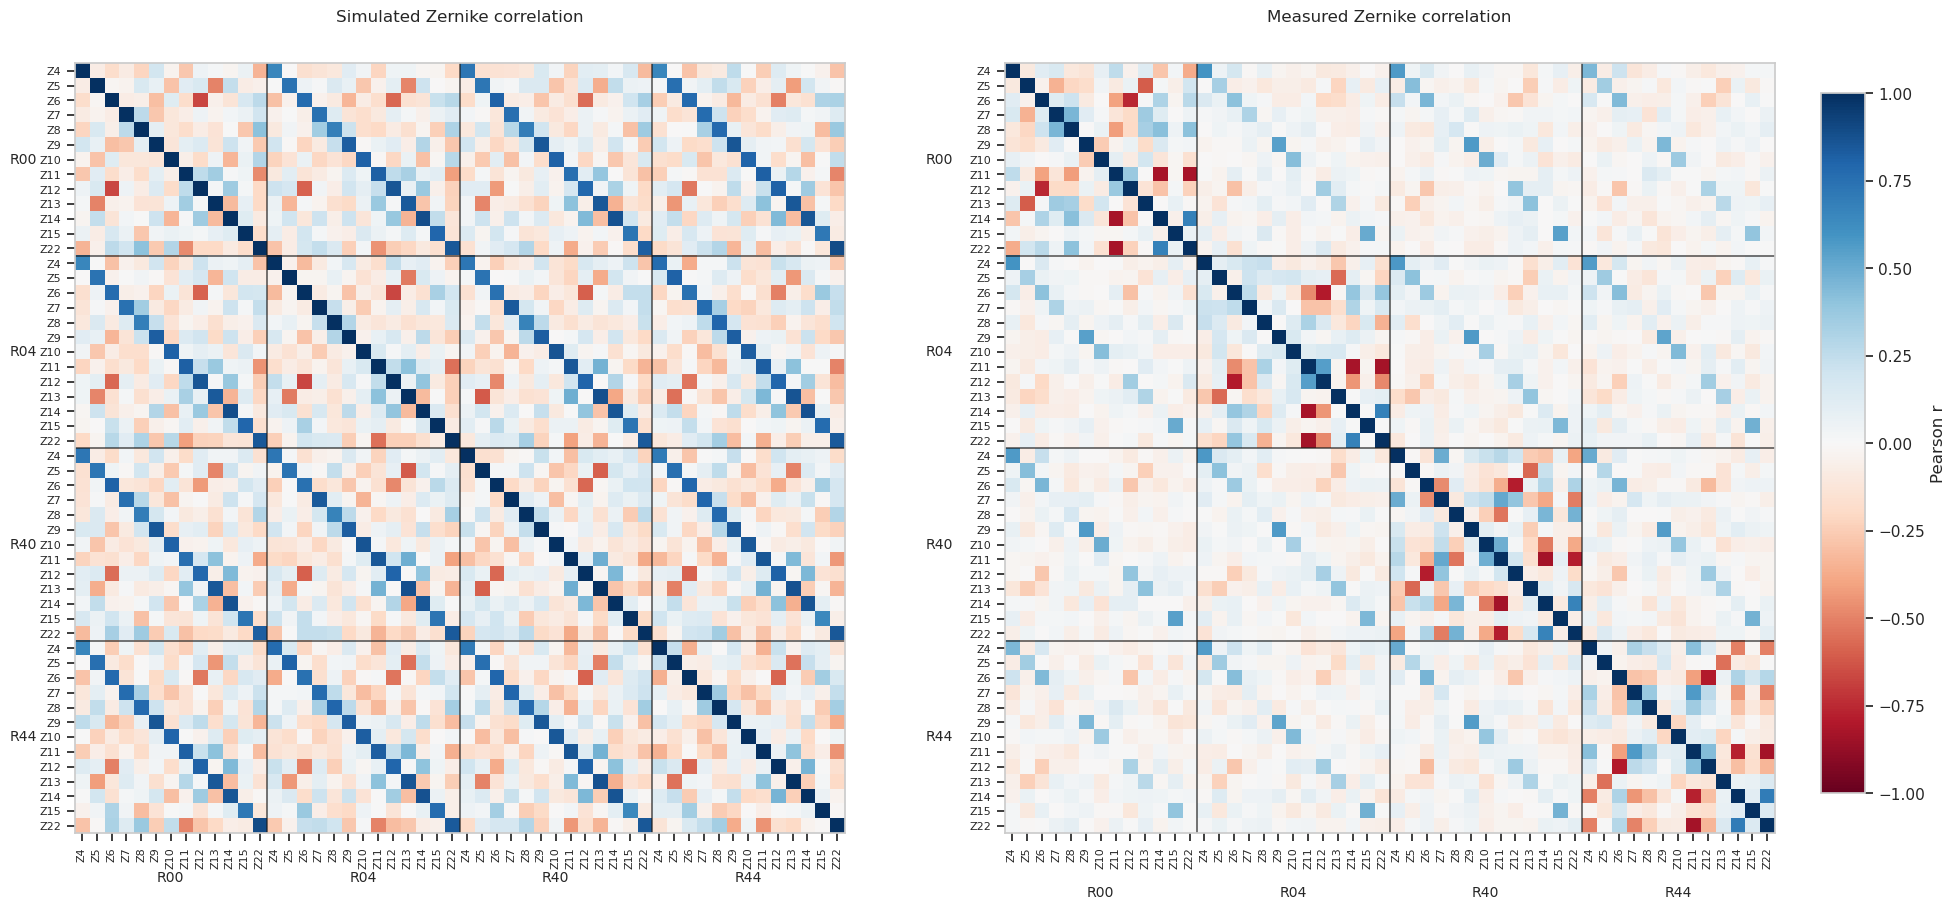

In [82]:
# Simulated vs measured correlation (side-by-side)
z_list_display = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 22]
Ccorr_sim = compute_sim_ccorr_for_selection(mat, dets=CORNERS, z_list=z_list_display)

# Measured correlation for same Z subset
cols_display = corner_zernike_columns(CORNERS, z_list_display)
if 'df_corner' in globals() and all(c in df_corner.columns for c in cols_display):
    Ccorr_meas_display, _ = compute_correlation_matrix(df_corner, cols_display)
else:
    Ccorr_meas_display = None

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
plot_matrix_heatmap(axes[0], Ccorr_sim, z_list_display, CORNERS,
                    'Simulated Zernike correlation', mode='corr', corner_label_pad=3)
if Ccorr_meas_display is not None:
    im = plot_matrix_heatmap(axes[1], Ccorr_meas_display, z_list_display, CORNERS,
                             'Measured Zernike correlation', mode='corr', corner_label_pad=4)
    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cax, label='Pearson r')
else:
    axes[1].set_title('Measured: not available')
    axes[1].axis('off')
sim_meas_corr_fig = fig  # for technote export
plt.show()

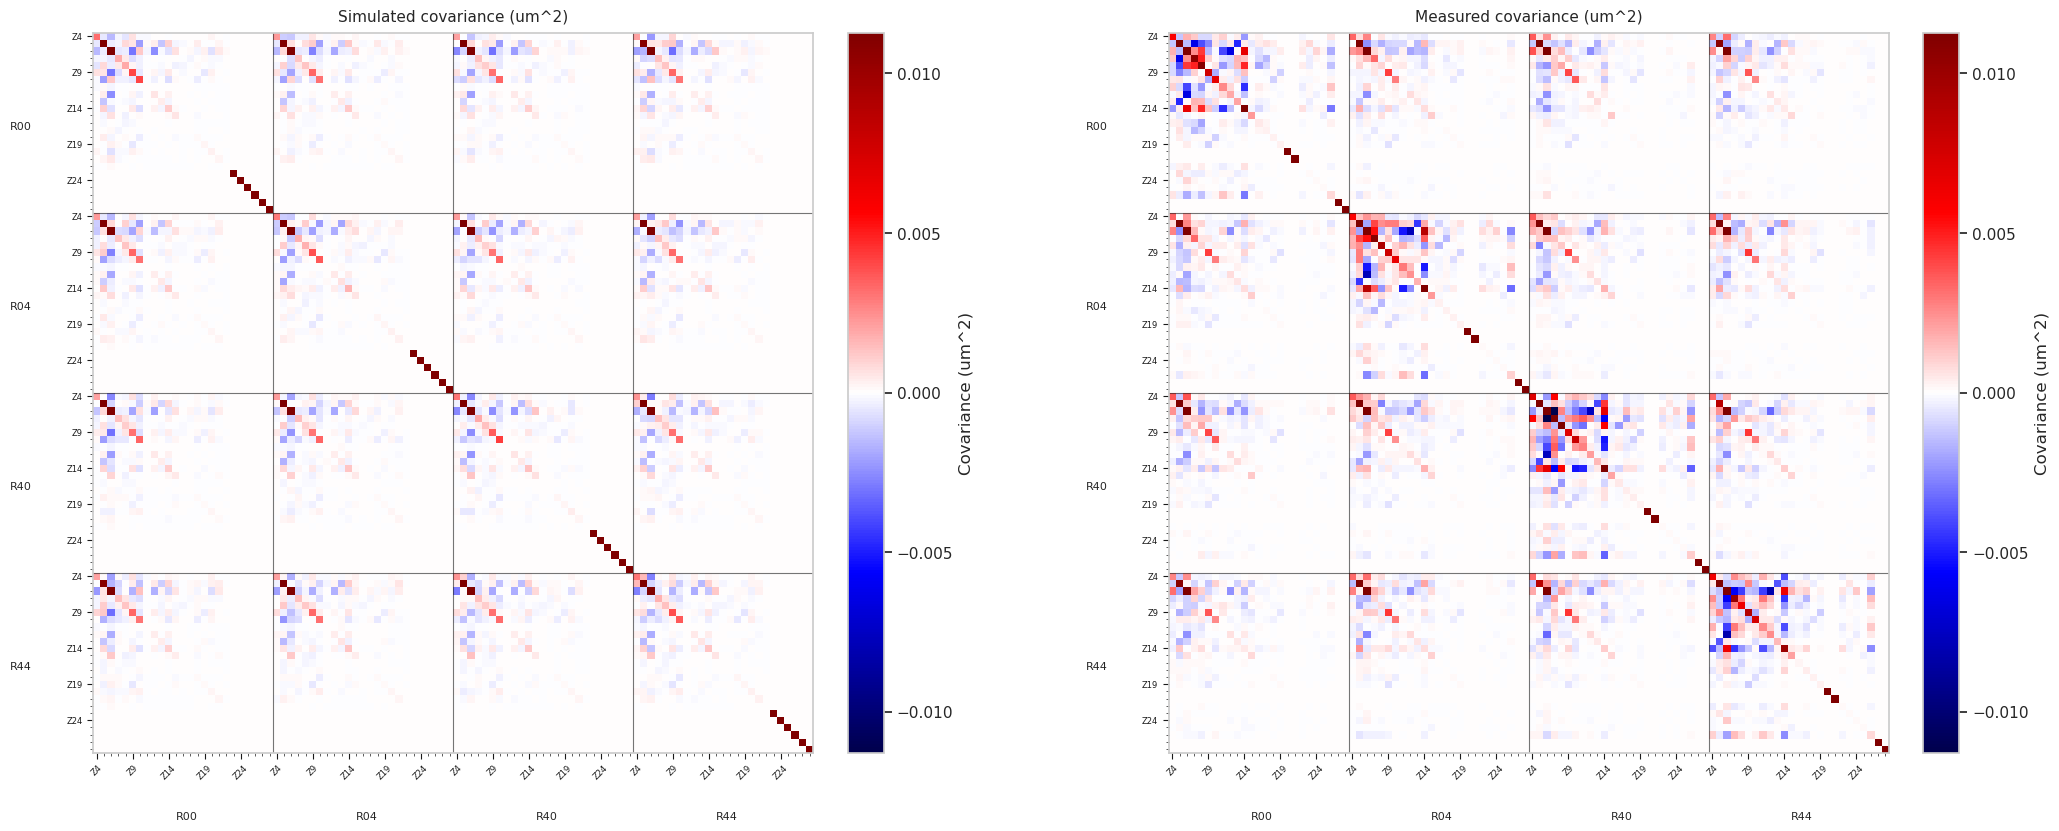

In [83]:
# Simulated vs measured covariance (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(22, 12))

_plot_cov_matrix(axes[0], C_sim, target_indices, CORNERS,
                 'Simulated covariance (um^2)')
im = _plot_cov_matrix(axes[1], C_new, target_indices, CORNERS,
                      'Measured covariance (um^2)')

for ax_i in axes:
    fig.colorbar(im, ax=ax_i, fraction=0.046, pad=0.04, label='Covariance (um^2)')
plt.subplots_adjust(bottom=0.28, left=0.10, right=0.98, top=0.88, wspace=0.25)
sim_meas_cov_fig = fig  # for technote export
plt.show()

In [84]:
# PSD sanity check
_psd_report('C_sim (remapped, um^2)', C_sim)
_psd_report('C_new (measured, um^2)', C_new)

C_sim (remapped, um^2): shape=(100, 100)  max|C-C^T|=0.000e+00  min_eig=1.310e-08  neg_eigs(<-1.000e-12)=0
C_new (measured, um^2): shape=(100, 100)  max|C-C^T|=0.000e+00  min_eig=7.485e-06  neg_eigs(<-1.000e-12)=0


{'min_eig': 7.48503306601433e-06, 'tol': 1e-12, 'n_neg': 0, 'asym': 0.0}

# State Estimation Comparison: Simulated, Measured vs Cov=False

Run the three-pass state-estimation loop to compute DOF states with:
1. **Cov=False** (no noise covariance)
2. **SimCov** (C_sim from simulated data)
3. **MeasuredCov** (C_new from measured data)

Reuses `butler`, `efd_client`, `fetcher`. Cached zernikes are also used.

In [38]:
# Three-pass state estimation: SimCov vs MeasuredCov vs Cov=False
# Reuse butler/fetcher/efd_client from Phase 2

check_globals_exist([
    'butler', 'fetcher', 'efd_client', 'C_new', 'C_sim',
    'corner_detnames', 'use_dof', 'nkeep', 'Z_TARGET',
    'cdb_table_all', 'dof_day', 'dof_seq_min', 'dof_seq_max',
])

day = dof_day
seq_min = dof_seq_min
seq_max = dof_seq_max
nZ_target = len(Z_TARGET)

C_meas_ordered = np.asarray(C_new, dtype=float)

# Get sequences from ConsDB
cdb_day = cdb_table_all[cdb_table_all['day_obs'] == day].sort_values('seq')
seqs_list = cdb_day['seq'].to_numpy()
if seqs_list.size == 0:
    raise RuntimeError(f"No sequences found for day={day}, seq {seq_min}-{seq_max}")
print(f"Processing day={day} sequences: {seqs_list.min()}..{seqs_list.max()} (n={len(seqs_list)})")

# Cache aligned zernikes per sequence
zk_by_seq = {}
meta_by_seq = {}
failures = []

# ---- Pass 1: Cov=False ----
states_covfalse_list = []
bands_p5 = []
seqs_p5 = []

print("--- PASS 1/3: Cov=False ---")
for seq in tqdm(seqs_list, desc=f"PASS1 Cov=False day {day}"):
    seq = int(seq)
    cdb_seq = cdb_day[cdb_day['seq'] == seq]
    if cdb_seq.empty:
        continue
    rtp = cdb_seq['physical_rotator_angle'].iloc[0]
    band = cdb_seq['band'].iloc[0]
    el = cdb_seq['altitude'].iloc[0]

    try:
        zernikes, zernike_array, noll_indices, sensor_names = fetcher.get_zernikes(
            _obs_id_for_seq(day, seq)
        )
        zernike_array = align_zernikes_to_corner_detnames(
            zernike_array, sensor_names=sensor_names,
            detnames=corner_detnames, nZ_expected=nZ_target,
        )
    except Exception:
        failures.append({'seq': seq, 'stage': 'fetch', 'traceback': traceback.format_exc()})
        continue

    try:
        state_nocov = get_state(
            zernike_array, rtp=rtp, use_dof=use_dof,
            nkeep=nkeep, band=band, noise_covariance=None,
        )
    except Exception:
        failures.append({'seq': seq, 'stage': 'Cov=False', 'traceback': traceback.format_exc()})
        continue

    zk_by_seq[seq] = zernike_array
    meta_by_seq[seq] = {'rtp': float(rtp), 'band': band, 'el': float(el)}
    states_covfalse_list.append(-np.asarray(state_nocov, dtype=float))
    bands_p5.append(band)
    seqs_p5.append(seq)

if not states_covfalse_list:
    raise RuntimeError("No successful Cov=False state estimates.")

states_covfalse_array = np.vstack(states_covfalse_list)
seqs_good = np.asarray(seqs_p5, dtype=int)
print(f"PASS1 done: {len(seqs_good)} successful sequences")

# ---- Pass 2: SimCov ----
states_simcov_list = []
print("--- PASS 2/3: SimCov ---")
for seq in tqdm(seqs_good, desc=f"PASS2 SimCov day {day}"):
    seq = int(seq)
    zernike_array = zk_by_seq[seq]
    meta = meta_by_seq[seq]
    try:
        state_cov = get_state(
            zernike_array, rtp=meta['rtp'], use_dof=use_dof,
            nkeep=nkeep, band=meta['band'], noise_covariance=C_sim,
        )
        states_simcov_list.append(-np.asarray(state_cov, dtype=float))
    except Exception:
        failures.append({'seq': seq, 'stage': 'SimCov', 'traceback': traceback.format_exc()})

if not states_simcov_list:
    raise RuntimeError("No successful SimCov state estimates.")
states_simcov_array = np.vstack(states_simcov_list)
print(f"PASS2 done: {states_simcov_array.shape[0]} successful sequences")

# ---- Pass 3: MeasuredCov (C_new) ----
states_meascov_list = []
print("--- PASS 3/3: MeasuredCov (C_new) ---")
for seq in tqdm(seqs_good, desc=f"PASS3 MeasuredCov day {day}"):
    seq = int(seq)
    zernike_array = zk_by_seq[seq]
    meta = meta_by_seq[seq]
    try:
        state_cov = get_state(
            zernike_array, rtp=meta['rtp'], use_dof=use_dof,
            nkeep=nkeep, band=meta['band'], noise_covariance=C_meas_ordered,
        )
        states_meascov_list.append(-np.asarray(state_cov, dtype=float))
    except Exception:
        failures.append({'seq': seq, 'stage': 'MeasuredCov', 'traceback': traceback.format_exc()})

if not states_meascov_list:
    raise RuntimeError("No successful MeasuredCov state estimates.")
states_meascov_array = np.vstack(states_meascov_list)
print(f"PASS3 done: {states_meascov_array.shape[0]} successful sequences")

if failures:
    print(f"WARNING: {len(failures)} total failures (first 5):")
    for f in failures[:5]:
        print(f"  seq={f['seq']} stage={f['stage']}: {f['traceback'].splitlines()[-1]}")

# Export with distinctive names
simcomp_states_covfalse_array = states_covfalse_array
simcomp_states_simcov_array = states_simcov_array
simcomp_states_meascov_array = states_meascov_array
simcomp_use_dof = np.asarray(use_dof, dtype=int)
simcomp_seqs = seqs_good
simcomp_corner_detnames = list(corner_detnames)

print(f"[export] shapes: covfalse={simcomp_states_covfalse_array.shape}, "
      f"simcov={simcomp_states_simcov_array.shape}, meascov={simcomp_states_meascov_array.shape}")

Processing day=20251109 sequences: 144..183 (n=40)
--- PASS 1/3: Cov=False ---


PASS1 Cov=False day 20251109:   0%|          | 0/40 [00:00<?, ?it/s]

PASS1 Cov=False day 20251109:   2%|▎         | 1/40 [00:05<03:42,  5.70s/it]

PASS1 Cov=False day 20251109:   5%|▌         | 2/40 [00:11<03:37,  5.74s/it]

PASS1 Cov=False day 20251109:   8%|▊         | 3/40 [00:17<03:29,  5.67s/it]

...

PASS1 done: 40 successful sequences
--- PASS 2/3: SimCov ---


PASS2 SimCov day 20251109: 100%|██████████| 40/40 [03:27<00:00,  5.18s/it]


PASS2 done: 40 successful sequences
--- PASS 3/3: MeasuredCov (C_new) ---


PASS3 MeasuredCov day 20251109: 100%|██████████| 40/40 [03:22<00:00,  5.06s/it]

PASS3 done: 40 successful sequences
[export] shapes: covfalse=(40, 22), simcov=(40, 22), meascov=(40, 22)


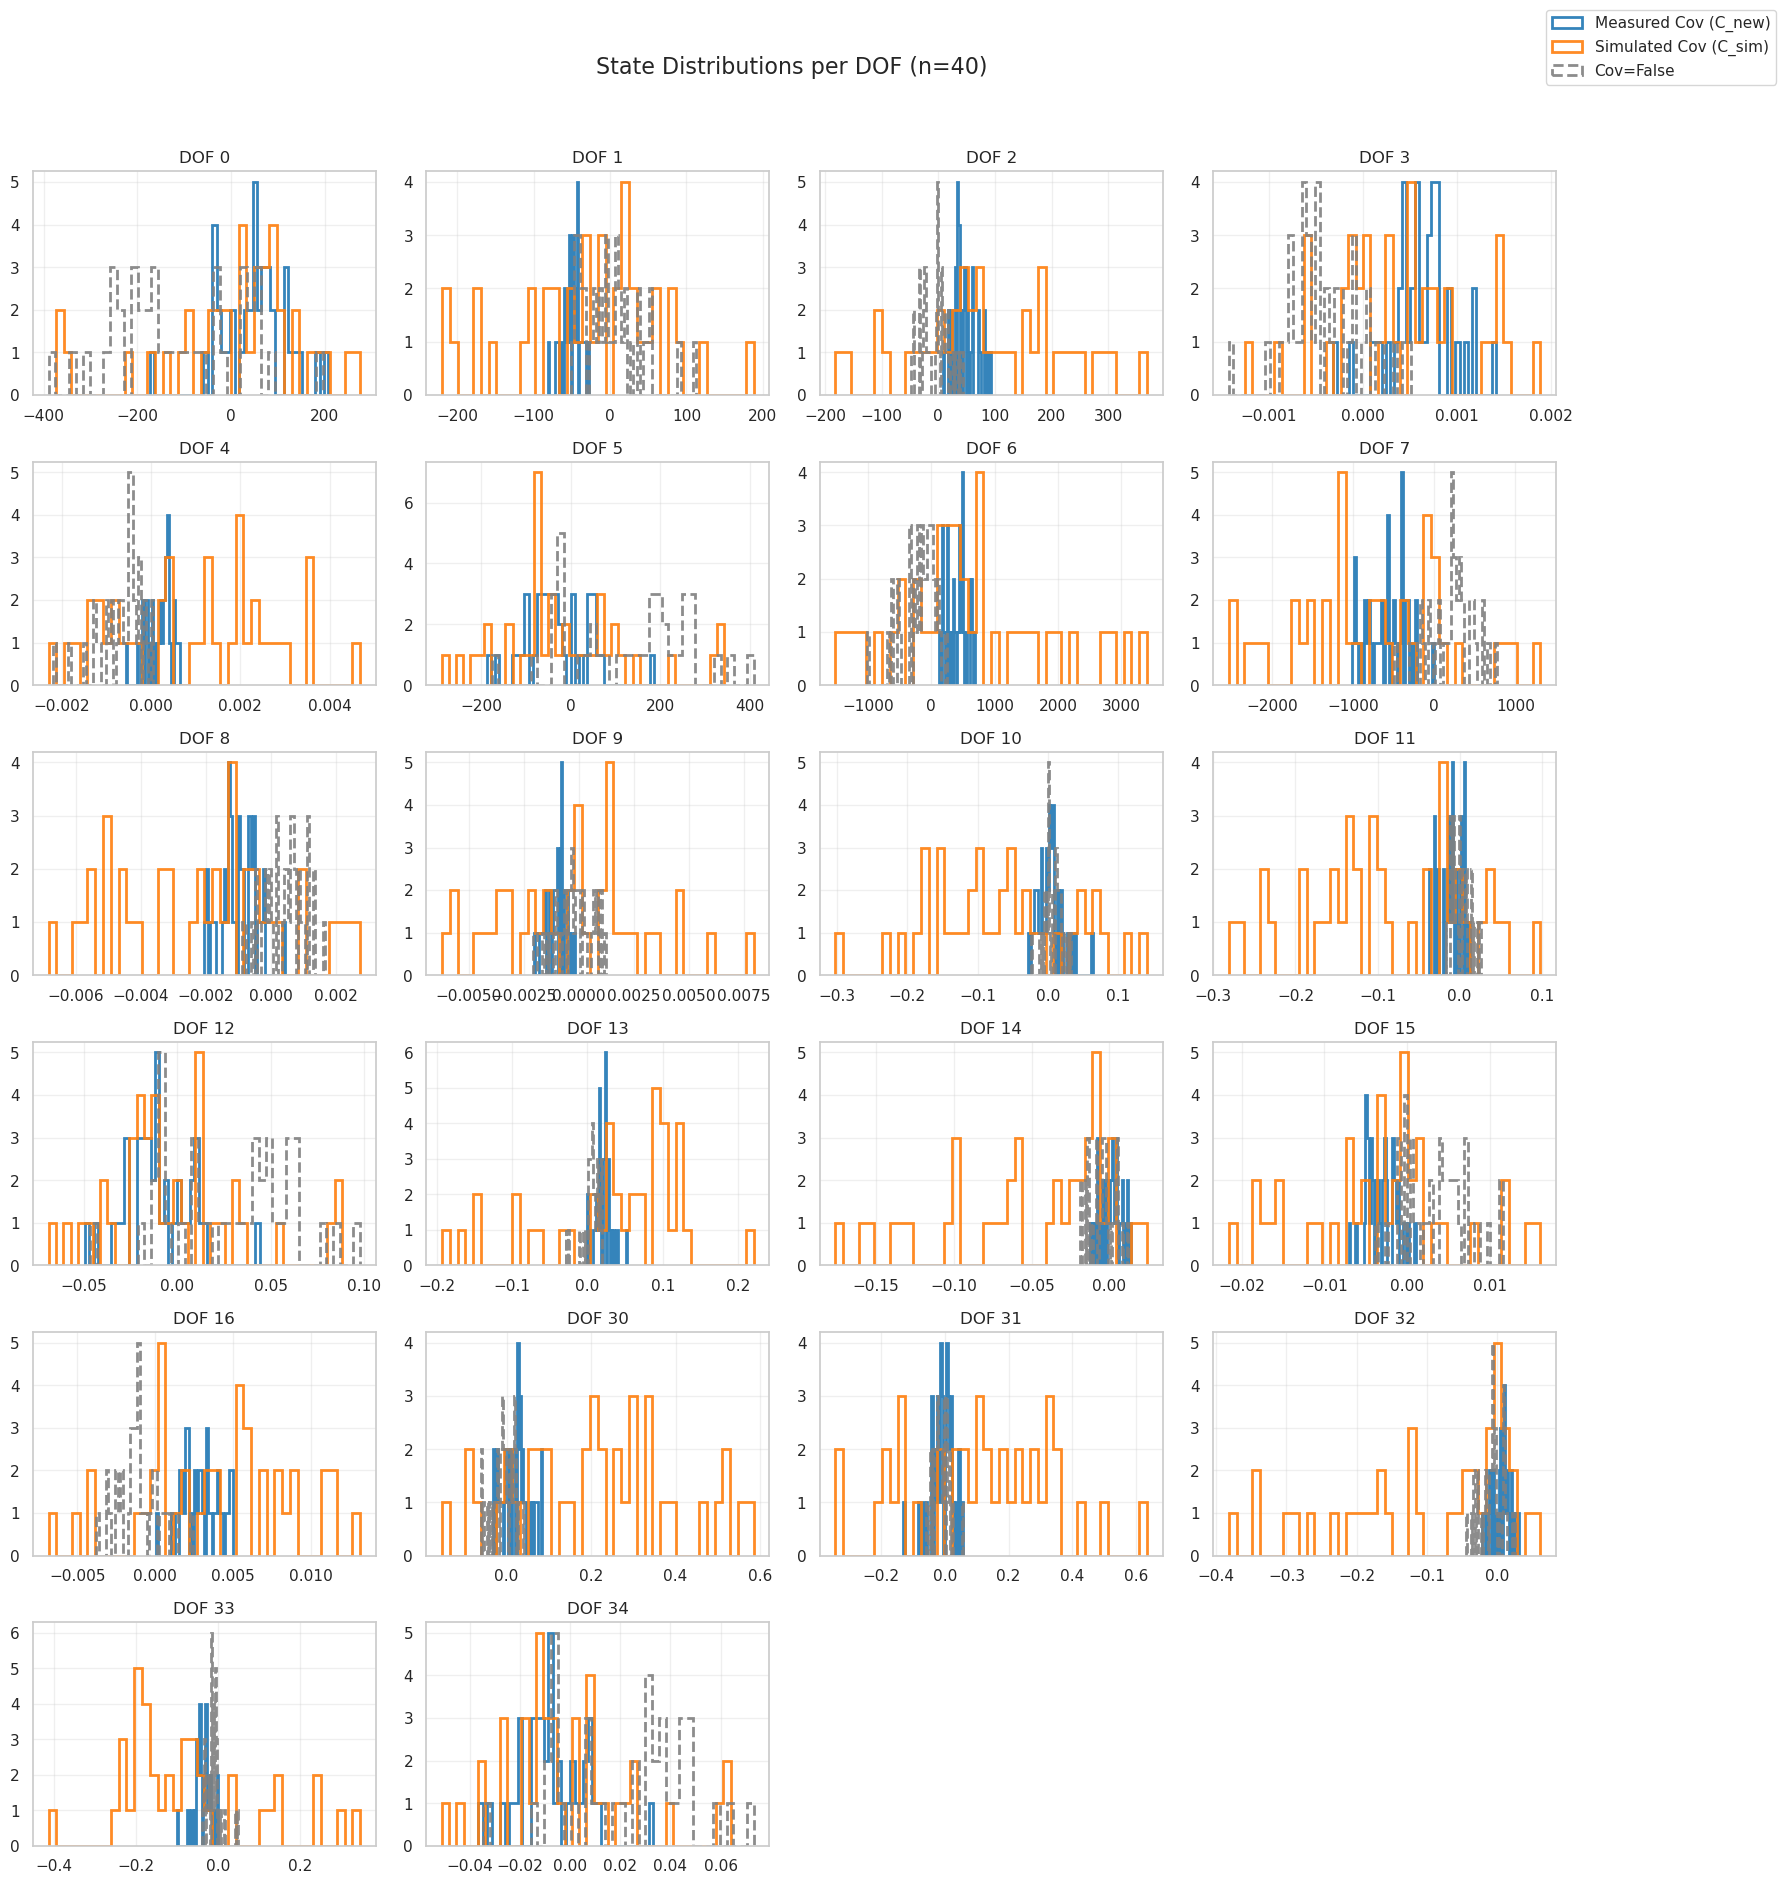

In [85]:
# Plot: per-DOF state distributions (MeasuredCov vs SimCov vs Cov=False)
check_globals_exist([
    'simcomp_states_covfalse_array', 'simcomp_states_simcov_array',
    'simcomp_states_meascov_array', 'simcomp_use_dof',
])

covfalse = np.asarray(simcomp_states_covfalse_array, dtype=float)
simcov = np.asarray(simcomp_states_simcov_array, dtype=float)
meascov = np.asarray(simcomp_states_meascov_array, dtype=float)
use_dof_list = list(np.asarray(simcomp_use_dof, dtype=int))
n_dof = len(use_dof_list)

n_use = int(min(covfalse.shape[0], simcov.shape[0], meascov.shape[0]))
if n_use < 3:
    raise ValueError(f"Not enough samples: n_use={n_use}")
if covfalse.shape[0] != n_use or simcov.shape[0] != n_use or meascov.shape[0] != n_use:
    print(f"[plot] Truncating to n={n_use} for fair comparison")
    covfalse, simcov, meascov = covfalse[:n_use], simcov[:n_use], meascov[:n_use]

ncols = 4
nrows = int(np.ceil(n_dof / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=False, sharey=False)
axes = np.asarray(axes).ravel()

for idx, dof_id in enumerate(use_dof_list):
    ax = axes[idx]
    for arr, lbl, color, ls in [
        (meascov, 'Measured Cov (C_new)', 'tab:blue', '-'),
        (simcov, 'Simulated Cov (C_sim)', 'tab:orange', '-'),
        (covfalse, 'Cov=False', 'gray', '--'),
    ]:
        v = _finite_1d(arr[:, idx])
        if v.size:
            ax.hist(v, bins=40, histtype='step', linewidth=2,
                    label=lbl if idx == 0 else None,
                    linestyle=ls, alpha=0.9, color=color)
    ax.set_title(f"DOF {dof_id}")
    ax.grid(alpha=0.3)

for ax in axes[n_dof:]:
    ax.axis('off')

fig.suptitle(f"State Distributions per DOF (n={n_use})", fontsize=16, y=1.02)
fig.tight_layout()

# Collect legend
handles_all, labels_all = [], []
for ax in axes[:n_dof]:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll and ll not in labels_all:
            handles_all.append(hh)
            labels_all.append(ll)
if handles_all:
    fig.legend(handles_all, labels_all, loc='upper right',
               bbox_to_anchor=(1.12, 1.05), frameon=True)
dof_comparison_fig = fig  # for technote export
plt.show()

# Clipped Zernike Correlation Matrix Analysis

Recompute the measured corner-Zernike correlation matrix after binning by `donut_blur_fwhm` (and optionally altitude).
Compare with simulated correlation at each environment bin.

In [86]:
# Merge environment metrics and compute Ccorr for blur bins
check_globals_exist(['df_corner', 'blur_bins', 'alt_window'])

dets_ccorr = list(ts_corner_detectors)
df_corner_use = df_corner.copy()

# Infer available Zernikes from df_corner columns
z_list_full = _infer_z_list_from_df_corner(df_corner_use, dets_ccorr)
print(f"[full] z_list_full={z_list_full}")

# Merge environment metrics (from ConsDB or in-memory tables)
df_corner_use = merge_env_metrics(df_corner_use, consdb_url=CONSDB_URL)
ensure_numeric_columns(df_corner_use, ['donut_blur_fwhm', 'altitude', 'aos_fwhm', 'dimm_seeing'])

cols_full = corner_zernike_columns(dets_ccorr, z_list_full)

# Build blur bins
blur_bins_local = [float(b) for b in blur_bins]
b0 = blur_bins_local[0]
bin_labels = [f"blur <= {b0}"]
bin_intervals = [(None, b0)]
for lo, hi in zip(blur_bins_local[:-1], blur_bins_local[1:]):
    bin_labels.append(f"{lo} < blur <= {hi}")
    bin_intervals.append((lo, hi))
bin_labels.append(f"blur > {blur_bins_local[-1]}")
bin_intervals.append((blur_bins_local[-1], None))

blur_series = df_corner_use['donut_blur_fwhm'].to_numpy(dtype=float)
alt_series = df_corner_use['altitude'].to_numpy(dtype=float) if 'altitude' in df_corner_use.columns else None

Ccorr_meas_by_env_full = []

for label, (lo, hi) in zip(bin_labels, bin_intervals):
    if lo is None:
        m = blur_series <= hi
    elif hi is None:
        m = blur_series > lo
    else:
        m = (blur_series > lo) & (blur_series <= hi)

    if alt_window is not None and alt_series is not None:
        alt_min, alt_max = alt_window
        n_before = int(np.sum(m))
        m = m & (alt_series > alt_min) & (alt_series < alt_max)
        n_after = int(np.sum(m))
        if label == bin_labels[0]:  # print once for first bin
            n_finite_alt = int(np.sum(np.isfinite(alt_series)))
            print(f"[ccorr-clip] altitude window ({alt_min}, {alt_max}): "
                  f"alt range={np.nanmin(alt_series):.1f}-{np.nanmax(alt_series):.1f}, "
                  f"finite={n_finite_alt}/{len(alt_series)}")

    df_sub = df_corner_use.loc[m].copy()
    Ccorr, nrows = compute_correlation_matrix(df_sub, cols_full)
    entry = {'label': label, 'Ccorr': Ccorr, 'n_rows': int(nrows), 'df': df_sub}
    Ccorr_meas_by_env_full.append(entry)

    alt_str = "" if alt_window is None else f" and {alt_window[0]}<alt<{alt_window[1]}"
    print(f"[env-clip] {label}{alt_str}: rows_used={nrows}")

ccorr_dets = dets_ccorr
ccorr_z_list_full = z_list_full
ccorr_env_labels = bin_labels

[full] R00: found 23 Zernikes (min=4, max=26)
[full] R04: found 23 Zernikes (min=4, max=26)
[full] R40: found 23 Zernikes (min=4, max=26)
[full] R44: found 23 Zernikes (min=4, max=26)
[full] z_list_full=[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
[clip] Using in-memory 'cdb_table_all_days' for env metrics. Added columns: ['altitude', 'aos_fwhm', 'dimm_seeing', 'donut_blur_fwhm', 'wind_speed']
[ccorr-clip] altitude window (55, 65): alt range=44.9-67.9, finite=540/540


[env-clip] blur <= 1.0 and 55<alt<65: rows_used=157


[env-clip] 1.0 < blur <= 1.25 and 55<alt<65: rows_used=200


[env-clip] 1.25 < blur <= 1.5 and 55<alt<65: rows_used=76


[env-clip] blur > 1.5 and 55<alt<65: rows_used=31


[plot] Ccorr_sim_use shape=(52, 52)


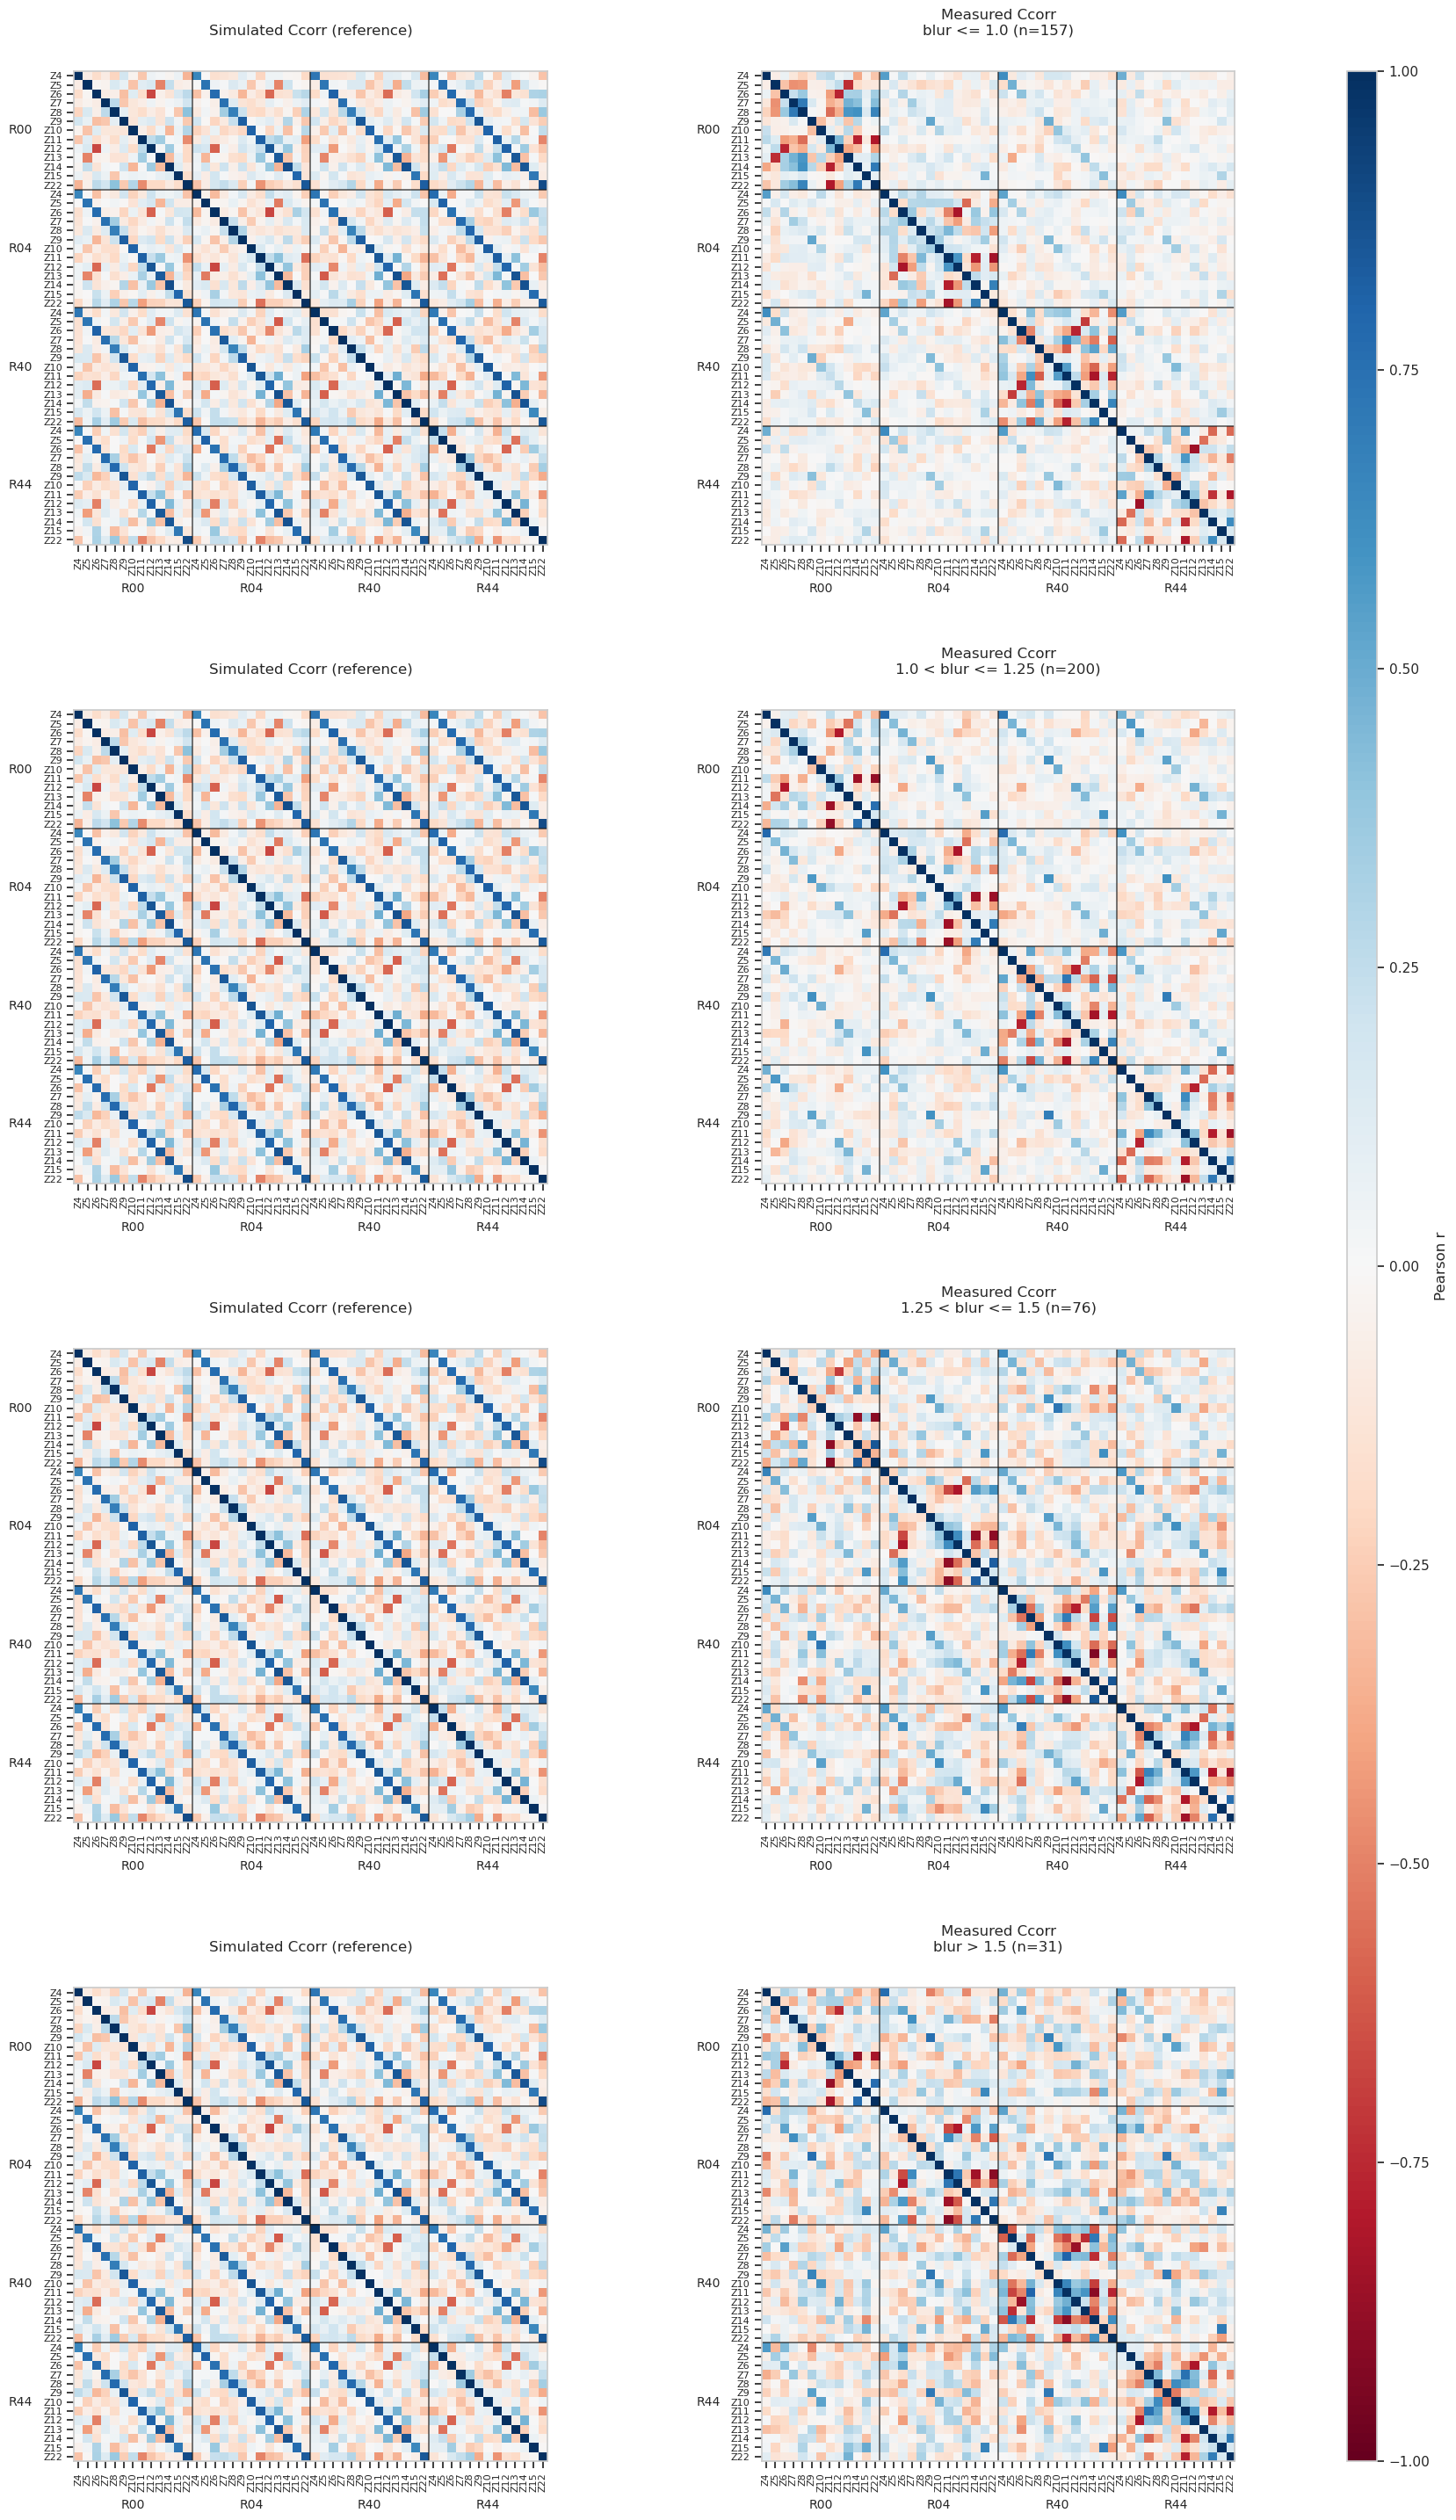

In [87]:
# Plot: simulated vs measured Ccorr per blur bin
z_list_display_ccorr = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 22]
Ccorr_sim_use = compute_sim_ccorr_for_selection(mat, dets=ccorr_dets, z_list=z_list_display_ccorr)
print(f"[plot] Ccorr_sim_use shape={Ccorr_sim_use.shape}")

# Build index mapping: full -> display subset
nCorners = len(ccorr_dets)
nZ_full_cc = len(ccorr_z_list_full)
z_to_pos = {int(z): i for i, z in enumerate(ccorr_z_list_full)}
idx_cc = []
for c in range(nCorners):
    base = c * nZ_full_cc
    for z in z_list_display_ccorr:
        idx_cc.append(base + z_to_pos[int(z)])
idx_cc = np.asarray(idx_cc, dtype=int)

entries = list(Ccorr_meas_by_env_full)
nrows_plot = len(entries)

fig = plt.figure(figsize=(20, 8 * nrows_plot))
gs = fig.add_gridspec(nrows=nrows_plot, ncols=3, width_ratios=[1, 1, 0.045],
                      wspace=0.02, hspace=0.35)

axes_plot = np.empty((nrows_plot, 2), dtype=object)
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1], sharex=ax00, sharey=ax00)
axes_plot[0, 0] = ax00
axes_plot[0, 1] = ax01
for r in range(1, nrows_plot):
    axes_plot[r, 0] = fig.add_subplot(gs[r, 0], sharex=ax00, sharey=ax00)
    axes_plot[r, 1] = fig.add_subplot(gs[r, 1], sharex=ax00, sharey=ax00)
cax = fig.add_subplot(gs[:, 2])

im_for_cb = None
for r, entry in enumerate(entries):
    Ccorr_full = entry['Ccorr']
    n_used = int(entry['n_rows'])
    label = entry.get('label', f'bin {r}')
    axL, axR = axes_plot[r, 0], axes_plot[r, 1]
    is_bottom = (r == nrows_plot - 1)

    imL = plot_matrix_heatmap(axL, Ccorr_sim_use, z_list_display_ccorr, ccorr_dets,
                              'Simulated Ccorr (reference)', mode='corr', corner_label_pad=5)
    if im_for_cb is None:
        im_for_cb = imL

    Ccorr_sub = _subset_ccorr(Ccorr_full, idx_cc) if Ccorr_full is not None else None
    if Ccorr_sub is None:
        axR.axis('off')
        axR.set_title(f"Measured Ccorr ({label})\nNot enough rows ({n_used})")
        continue
    imR = plot_matrix_heatmap(axR, Ccorr_sub, z_list_display_ccorr, ccorr_dets,
                              f'Measured Ccorr\n{label} (n={n_used})', mode='corr', corner_label_pad=5)
    im_for_cb = imR

fig.subplots_adjust(left=0.12, right=0.92, bottom=0.12, top=0.97)
if im_for_cb is not None:
    fig.colorbar(im_for_cb, cax=cax).set_label('Pearson r')
corr_by_blur_fig = fig  # for technote export
plt.show()

In [88]:
# Extract pseudo-diagonals for all corner pairs and bins
dets_diag = list(ccorr_dets)
nCorners_diag = len(dets_diag)

# Restrict to sim-supported range (Z4..Z22), mask Z20/Z21
z_list_use = [z for z in ccorr_z_list_full if 4 <= z <= 22 and z not in (20, 21)]
print(f"[pseudo-diag] z_list_use (n={len(z_list_use)}): {z_list_use}")

# Build index mapping for subsetting measured matrices
z_to_pos_full = {int(z): i for i, z in enumerate(ccorr_z_list_full)}
nZ_full_diag = len(ccorr_z_list_full)
idx_diag = []
for c in range(nCorners_diag):
    base = c * nZ_full_diag
    for z in z_list_use:
        idx_diag.append(base + z_to_pos_full[int(z)])
idx_diag = np.asarray(idx_diag, dtype=int)

# Simulated pseudo-diagonals
Ccorr_sim_diag = compute_sim_ccorr_for_selection(mat, dets=dets_diag, z_list=z_list_use)
pseudo_sim = extract_block_diag_vectors(Ccorr_sim_diag, dets=dets_diag, z_list=z_list_use)

# Measured pseudo-diagonals per bin
pseudo_meas_by_bin = {}
n_used_by_bin = {}
for entry in Ccorr_meas_by_env_full:
    label = str(entry.get('label', ''))
    n_used_by_bin[label] = int(entry.get('n_rows', -1))
    Cfull = entry.get('Ccorr', None)
    Cuse = _subset_ccorr(Cfull, idx_diag) if Cfull is not None else None
    if Cuse is None:
        pseudo_meas_by_bin[label] = None
        continue
    pseudo_meas_by_bin[label] = extract_block_diag_vectors(Cuse, dets=dets_diag, z_list=z_list_use)

# Select all unique corner pairs
pairs_to_show = [(dets_diag[i], dets_diag[j])
                 for i, j in combinations(range(nCorners_diag), 2)]
print(f"[pseudo-diag] pairs: {pairs_to_show}")

# Export for plotting
pseudo_diag_z_list = list(z_list_use)
pseudo_diag_pairs = list(pairs_to_show)
pseudo_diag_meas_by_bin = pseudo_meas_by_bin
pseudo_diag_sim = pseudo_sim
pseudo_diag_rows_used = n_used_by_bin

[pseudo-diag] z_list_use (n=17): [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22]
[pseudo-diag] pairs: [('R00', 'R04'), ('R00', 'R40'), ('R00', 'R44'), ('R04', 'R40'), ('R04', 'R44'), ('R40', 'R44')]


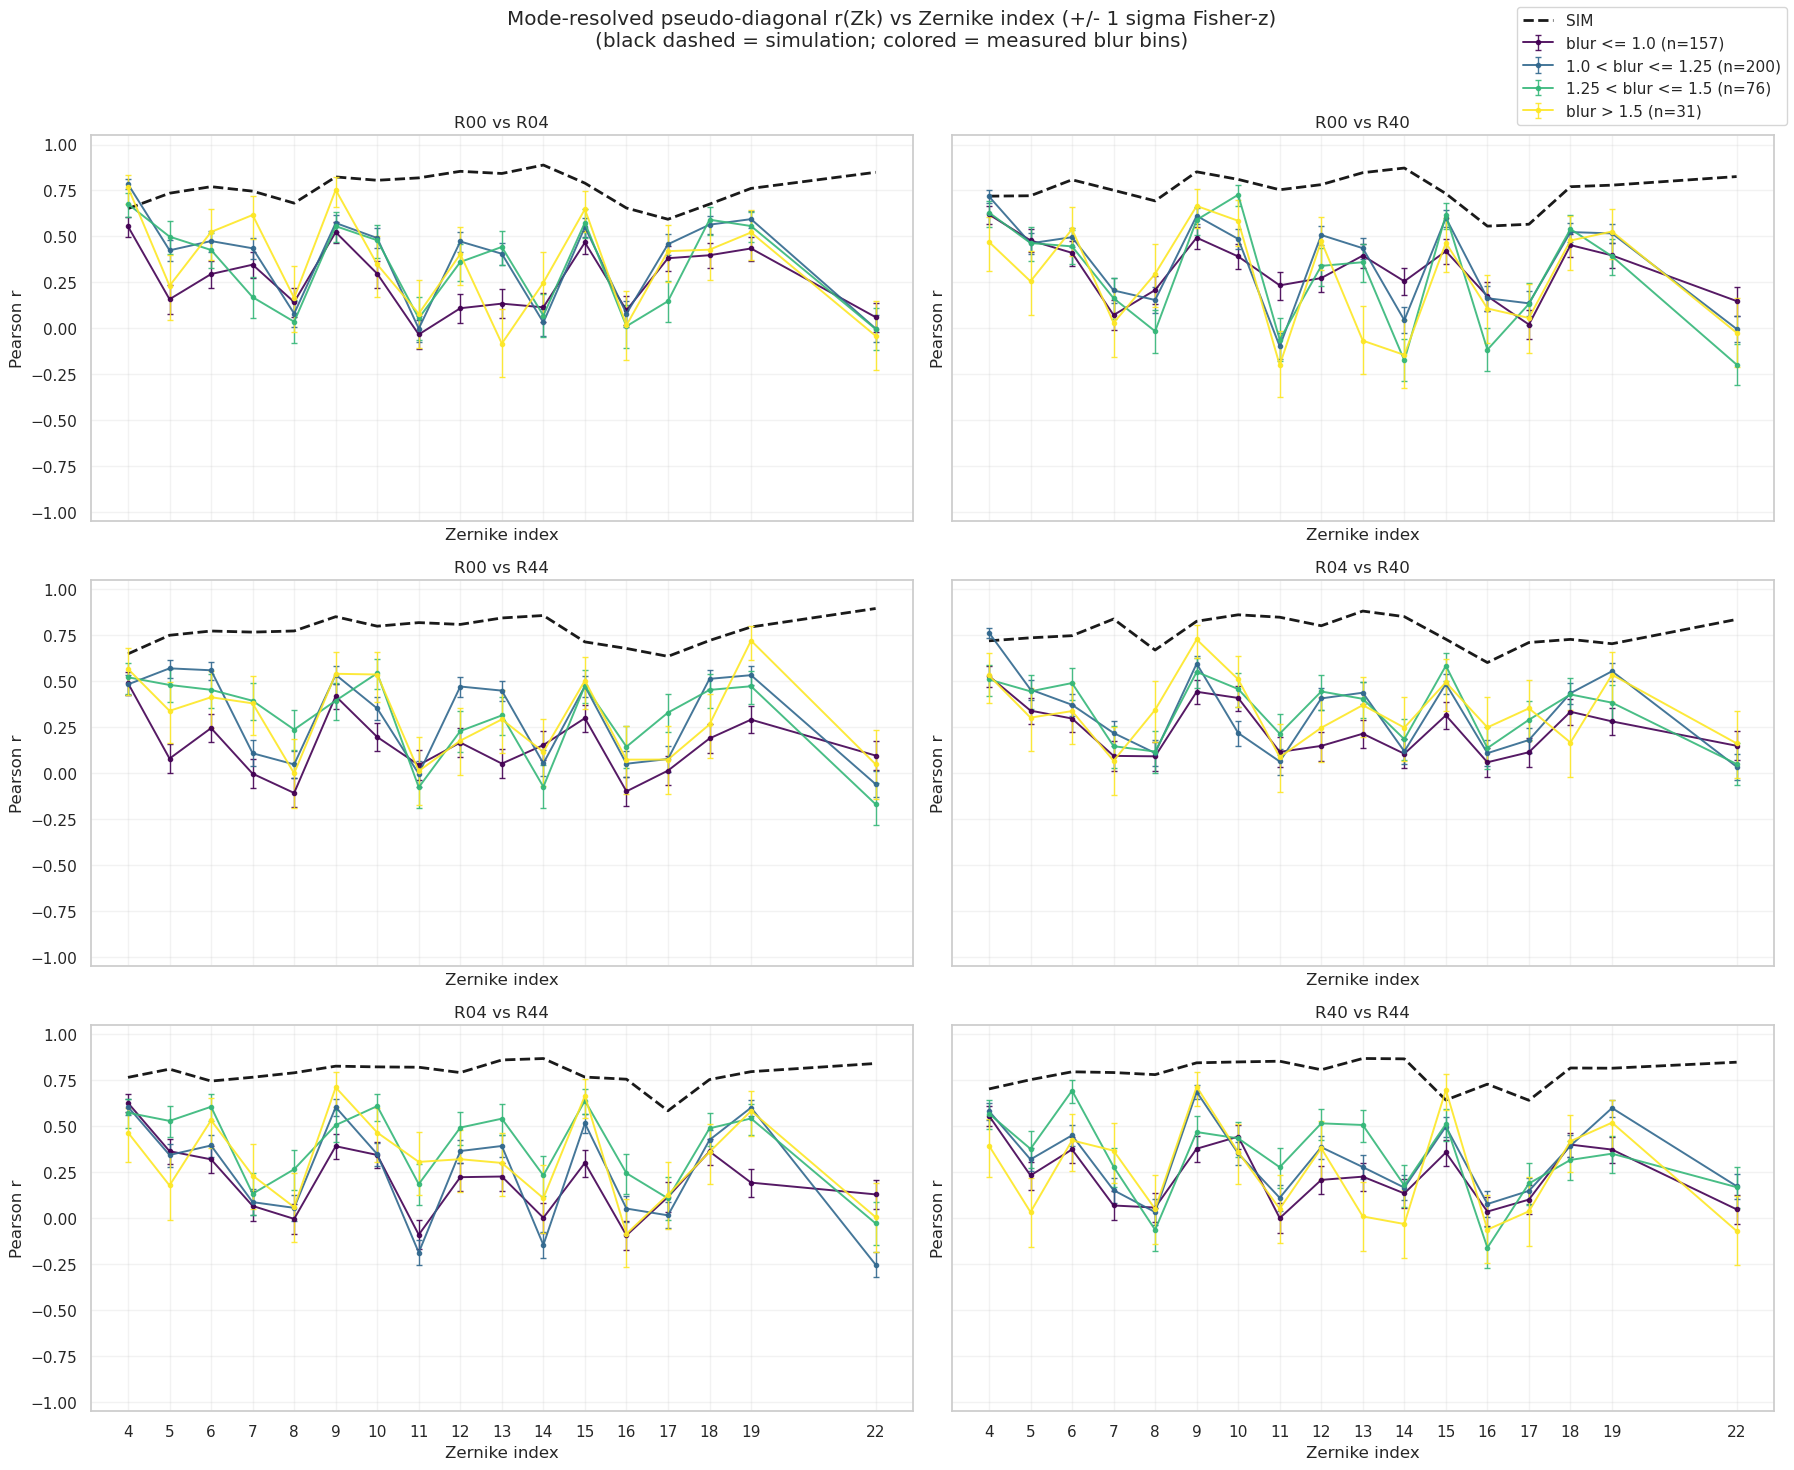

In [89]:
# Option 3: r(Zk) vs Zernike index, one line per bin + simulated reference
z_list_pd = np.asarray(pseudo_diag_z_list, dtype=int)
pairs_pd = list(pseudo_diag_pairs)
nPairs = len(pairs_pd)

bin_labels_pd = list(pseudo_diag_meas_by_bin.keys())
nBins = len(bin_labels_pd)
cmap = plt.get_cmap('viridis')
colors_pd = [cmap(i / max(1, nBins - 1)) for i in range(nBins)]

ncols_pd = 2 if nPairs > 1 else 1
nrows_pd = int(np.ceil(nPairs / ncols_pd))

fig, axes = plt.subplots(nrows=nrows_pd, ncols=ncols_pd,
                         figsize=(18, 4.8 * nrows_pd), squeeze=False,
                         sharex=True, sharey=True)
axes = axes.ravel()

for pi, (a, b) in enumerate(pairs_pd):
    ax = axes[pi]

    # Sim reference
    v_sim = np.asarray(pseudo_diag_sim[(a, b)], dtype=float)
    ax.plot(z_list_pd, v_sim, color='k', linestyle='--', linewidth=2.0, label='SIM')

    # Measured bin curves with Fisher z error bars
    for bi, lbl in enumerate(bin_labels_pd):
        pdict = pseudo_diag_meas_by_bin[lbl]
        if pdict is None:
            continue
        v = np.asarray(pdict[(a, b)], dtype=float)
        n = int(pseudo_diag_rows_used.get(lbl, -1))
        yerr = _fisher_1sigma_yerr(v, n=n, nsig=1.0)

        ax.errorbar(z_list_pd, v, yerr=yerr,
                    color=colors_pd[bi], alpha=0.9, linewidth=1.4,
                    elinewidth=1.0, capsize=2, marker='o', markersize=3,
                    label=f"{lbl} (n={n})" if pi == 0 else None)

    ax.set_title(f"{a} vs {b}")
    ax.set_ylim(-1.05, 1.05)
    ax.grid(alpha=0.25)
    ax.set_ylabel('Pearson r')
    ax.set_xlabel('Zernike index')
    ax.set_xticks(z_list_pd)
    ax.set_xticklabels([str(int(z)) for z in z_list_pd])

for j in range(nPairs, len(axes)):
    axes[j].axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', frameon=True)
fig.suptitle(
    "Mode-resolved pseudo-diagonal r(Zk) vs Zernike index (+/- 1 sigma Fisher-z)\n"
    "(black dashed = simulation; colored = measured blur bins)",
    y=1.02)
fig.tight_layout()
plt.show()

# Environment-Clipped Covariance

Build environment-clipped covariance matrices from cached detrended data,
binned by `donut_blur_fwhm`. Remap and canonicalize each to Z4-Z28 /
ts_ofc corner order. Then run state estimation with each variant and
compare via corner-style overlay plots.

In [90]:
# Build environment-clipped covariance matrices from cached detrended data
check_globals_exist(['detrended_days', 'manifest', 'CORNERS', 'CORNERS_RAW',
                     'blur_bins', 'alt_window', 'max_good_binning_cov',
                     'zero_raw_zernikes', 'current_indices', 'target_indices'])

# Settings
blur_bins_cov = [float(b) for b in blur_bins]
alt_window_cov = alt_window
zero_raw_zernikes_cov = list(zero_raw_zernikes)
current_indices_cov = list(current_indices)
target_indices_cov = list(target_indices)
detectors_cov = list(CORNERS_RAW)  # historical order in cached data
n_det_cov = len(detectors_cov)

# Reconstruct combined detrended array from cache or in-memory blocks
combined_csv = Path(cache_dir) / 'detrended_all.csv'
if combined_csv.exists():
    print(f"[cov-clip] Loading from {combined_csv}")
    raw = np.loadtxt(combined_csv, delimiter=',', skiprows=1)
    raw = np.atleast_2d(raw)
    day_obs_arr = raw[:, 0].astype(int)
    seq_num_arr = raw[:, 1].astype(int)
    data_arr = raw[:, 3:]
else:
    print("[cov-clip] Reconstructing from in-memory blocks + manifest")
    det_entries = manifest.get('detrended_blocks', [])
    rows_data, rows_day, rows_seq = [], [], []
    for idx_b, block in enumerate(detrended_days):
        if block is None:
            continue
        entry = det_entries[idx_b] if idx_b < len(det_entries) else {}
        day_val = int(entry.get('day', 0))
        seq_min_b = int(entry.get('seq_min', 0))
        n_rows = block.shape[0]
        rows_data.append(block)
        rows_day.append(np.full(n_rows, day_val, dtype=int))
        rows_seq.append(np.arange(seq_min_b, seq_min_b + n_rows, dtype=int))
    data_arr = np.vstack(rows_data)
    day_obs_arr = np.concatenate(rows_day)
    seq_num_arr = np.concatenate(rows_seq)

print(f"[cov-clip] data shape: {data_arr.shape}")

# Build DataFrame and merge environment metrics
df_cov = pd.DataFrame({'day_obs': day_obs_arr, 'seq_num': seq_num_arr})
df_cov = merge_env_metrics(df_cov, consdb_url=CONSDB_URL)
ensure_numeric_columns(df_cov, ['donut_blur_fwhm', 'altitude'])

blur_vals = df_cov['donut_blur_fwhm'].to_numpy(dtype=float)
alt_vals = df_cov['altitude'].to_numpy(dtype=float) if 'altitude' in df_cov.columns else None

# Precompute altitude mask
if alt_window_cov is not None and alt_vals is not None:
    alt_min, alt_max = alt_window_cov
    alt_in_window = np.isfinite(alt_vals) & (alt_vals > alt_min) & (alt_vals < alt_max)
else:
    alt_in_window = None

# Build bins
b0 = blur_bins_cov[0]
cov_bin_labels = [f"blur <= {b0}"]
cov_bin_intervals = [(None, b0)]
for lo, hi in zip(blur_bins_cov[:-1], blur_bins_cov[1:]):
    cov_bin_labels.append(f"{lo} < blur <= {hi}")
    cov_bin_intervals.append((lo, hi))
cov_bin_labels.append(f"blur > {blur_bins_cov[-1]}")
cov_bin_intervals.append((blur_bins_cov[-1], None))

C_new_by_env = []

# Good-binning aggregate
if max_good_binning_cov is not None:
    m_good = blur_vals <= float(max_good_binning_cov)
    C_new_by_env.append(_compute_cov_for_mask(
        f"blur <= {float(max_good_binning_cov)} (aggregate)", m_good,
        data_arr=data_arr, blur_vals=blur_vals, alt_in_window=alt_in_window,
        alt_window_cov=alt_window_cov,
        current_indices=current_indices_cov, target_indices=target_indices_cov,
        zero_raw_zernikes=zero_raw_zernikes_cov,
        detectors_from=detectors_cov, corners_to=list(CORNERS),
    ))

# Per-bin covariance
for label, (lo, hi) in zip(cov_bin_labels, cov_bin_intervals):
    if lo is None:
        m_bin = blur_vals <= hi
    elif hi is None:
        m_bin = blur_vals > lo
    else:
        m_bin = (blur_vals > lo) & (blur_vals <= hi)
    C_new_by_env.append(_compute_cov_for_mask(
        label, m_bin,
        data_arr=data_arr, blur_vals=blur_vals, alt_in_window=alt_in_window,
        alt_window_cov=alt_window_cov,
        current_indices=current_indices_cov, target_indices=target_indices_cov,
        zero_raw_zernikes=zero_raw_zernikes_cov,
        detectors_from=detectors_cov, corners_to=list(CORNERS),
    ))

# Unclipped reference
_all_mask = np.isfinite(data_arr).all(axis=1)
_C_raw_all = np.cov(data_arr[_all_mask], rowvar=False)
_C_new_all = remap_covariance(_C_raw_all,
                              current_indices=current_indices_cov,
                              target_indices=target_indices_cov,
                              zero_raw_zernikes=zero_raw_zernikes_cov,
                              n_det=n_det_cov)
_C_new_all = permute_cov_by_corner(_C_new_all,
                                   corner_from=detectors_cov,
                                   corner_to=list(CORNERS),
                                   nZ=len(target_indices_cov))
C_new_by_env.append({
    'label': 'all (no clip)',
    'C_raw': _C_raw_all,
    'C_new': _C_new_all,
    'n_rows': int(_all_mask.sum()),
    'n_rows_total': int(data_arr.shape[0]),
    'n_rows_used': int(_all_mask.sum()),
})

print(f"\n[cov-clip] Built {len(C_new_by_env)} clipped covariance matrices.")
print(f"[cov-clip] Corner order: {detectors_cov} -> {CORNERS}")

[cov-clip] Loading from zernike_cache/detrended_all.csv
[cov-clip] data shape: (540, 92)
[clip] Using in-memory 'cdb_table_all_days' for env metrics. Added columns: ['altitude', 'aos_fwhm', 'dimm_seeing', 'donut_blur_fwhm', 'wind_speed']
[cov-clip] blur <= 1.25 (aggregate) and 55<alt<65: n_rows_used=357 (blur=407, blur+alt=357), C_raw shape=(92, 92), C_new shape=(100, 100)
[cov-clip] blur <= 1.0 and 55<alt<65: n_rows_used=157 (blur=186, blur+alt=157), C_raw shape=(92, 92), C_new shape=(100, 100)
[cov-clip] 1.0 < blur <= 1.25 and 55<alt<65: n_rows_used=200 (blur=221, blur+alt=200), C_raw shape=(92, 92), C_new shape=(100, 100)
[cov-clip] 1.25 < blur <= 1.5 and 55<alt<65: n_rows_used=76 (blur=102, blur+alt=76), C_raw shape=(92, 92), C_new shape=(100, 100)
[cov-clip] blur > 1.5 and 55<alt<65: n_rows_used=31 (blur=31, blur+alt=31), C_raw shape=(92, 92), C_new shape=(100, 100)

[cov-clip] Built 6 clipped covariance matrices.
[cov-clip] Corner order: ['R00', 'R40', 'R04', 'R44'] -> ['R00', 'R

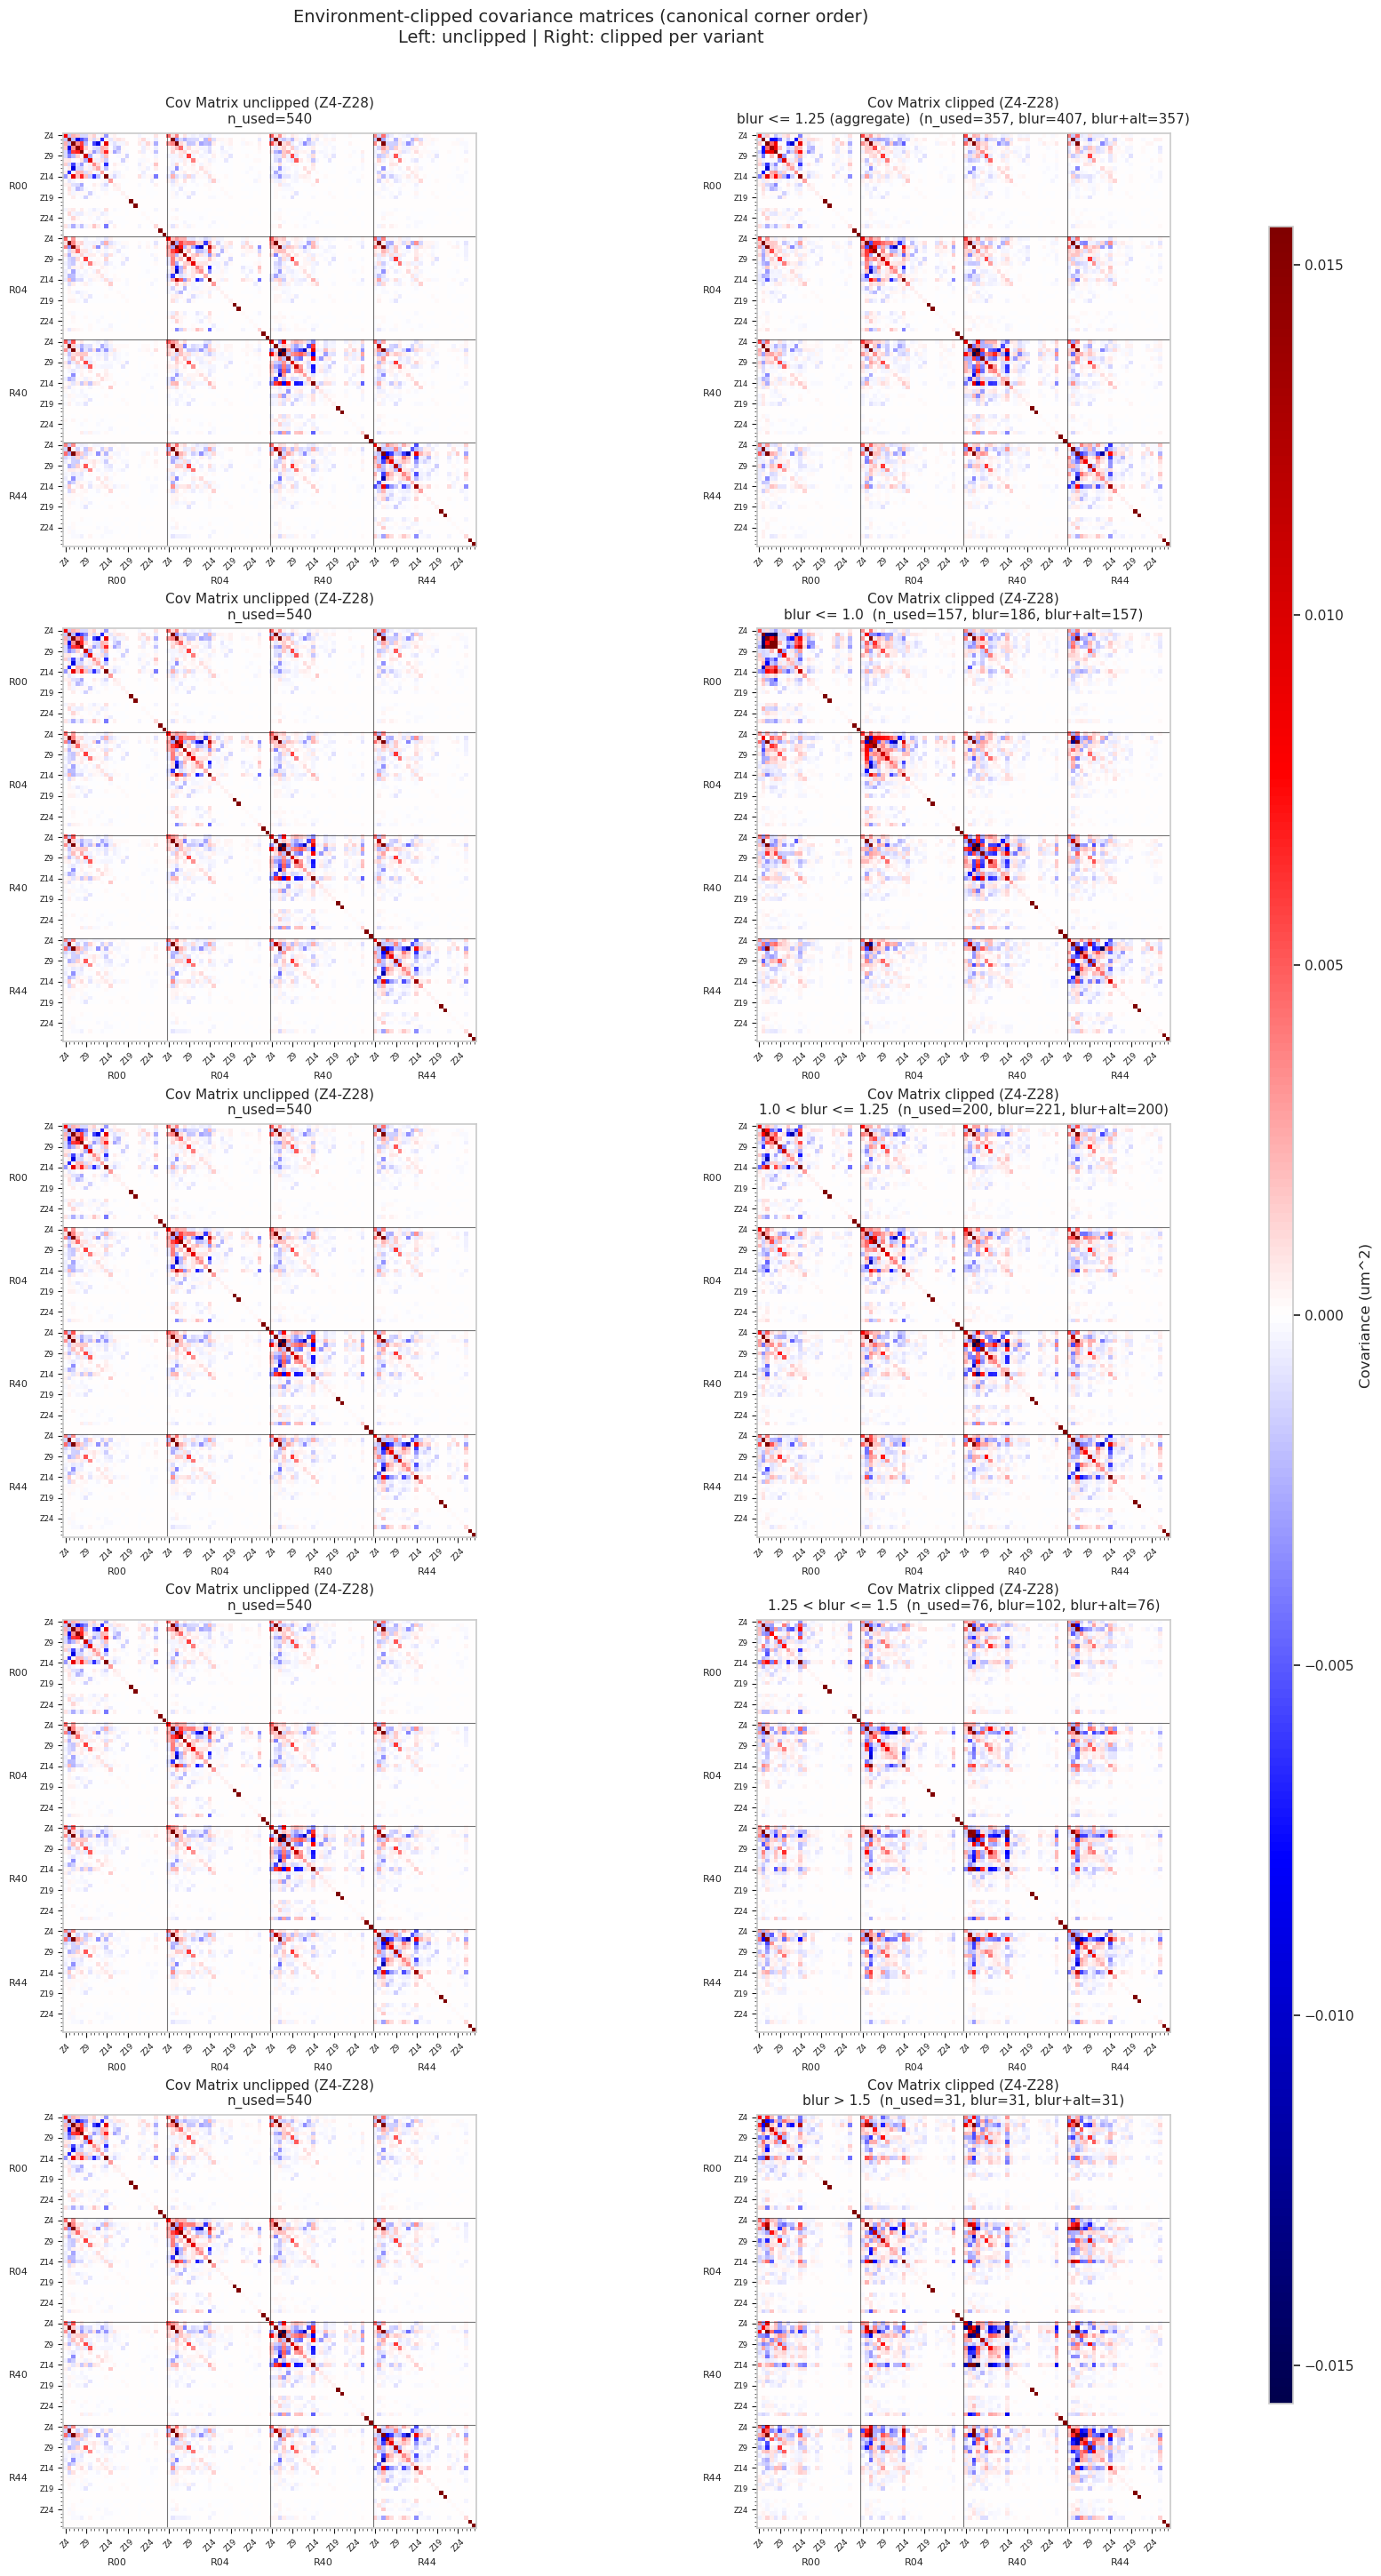

In [91]:
# Plot: environment-clipped covariance matrices (side-by-side grid)
check_globals_exist(['C_new_by_env'])

CORNERS_PLOT = list(CORNERS)
target_z = list(target_indices)

clipped_entries = [e for e in C_new_by_env
                   if e.get('C_new') is not None and e.get('label') != 'all (no clip)']
all_entry = [e for e in C_new_by_env
             if e.get('label') == 'all (no clip)' and e.get('C_new') is not None]

if len(all_entry) == 0:
    raise RuntimeError("'all (no clip)' entry not found.")
C_new_unclipped = all_entry[0]['C_new']
n_rows_unclipped = int(all_entry[0].get('n_rows_used', all_entry[0].get('n_rows', 0)))

# Sort: aggregate first, then blur bins
aggregate_entries = [e for e in clipped_entries if '(aggregate)' in str(e.get('label', ''))]
bin_entries = [e for e in clipped_entries if '(aggregate)' not in str(e.get('label', ''))]
entries_plot = aggregate_entries + bin_entries

n_entries = len(entries_plot)
fig, axes = plt.subplots(n_entries, 2, figsize=(18, 7 * n_entries), squeeze=False)

for row, entry in enumerate(entries_plot):
    label = entry.get('label', '(unnamed)')
    C_bin = entry['C_new']
    n_str = _format_n(entry)

    # Left: unclipped reference
    _plot_cov_matrix(axes[row, 0], C_new_unclipped, target_z, CORNERS_PLOT,
                     f"Cov Matrix unclipped (Z4-Z28)\nn_used={n_rows_unclipped}")
    # Right: clipped variant
    im = _plot_cov_matrix(axes[row, 1], C_bin, target_z, CORNERS_PLOT,
                          f"Cov Matrix clipped (Z4-Z28)\n{label} {n_str}")

fig.subplots_adjust(right=0.92)
cax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cax).set_label('Covariance (um^2)')

fig.suptitle(
    "Environment-clipped covariance matrices (canonical corner order)\n"
    "Left: unclipped | Right: clipped per variant",
    y=0.92, fontsize=14)
clipped_cov_fig = fig  # for technote export
plt.show()

In [92]:
# Export clipped covariance (blur <= max_good_binning_cov + altitude window) to YAML
check_globals_exist(['C_new_by_env', 'df_cov', 'blur_vals', 'alt_in_window',
                     'max_good_binning_cov', 'alt_window', 'CORNERS', 'target_indices'])

# Find the aggregate entry
agg_entry = None
for e in C_new_by_env:
    if '(aggregate)' in str(e.get('label', '')) and e.get('C_new') is not None:
        agg_entry = e
        break

if agg_entry is None:
    raise RuntimeError("Aggregate clipped entry not found in C_new_by_env")

C_clipped = agg_entry['C_new']
n_used = agg_entry['n_rows_used']
print(f"[export] Using entry: '{agg_entry['label']}', data_points={n_used}, shape={C_clipped.shape}")

# Reconstruct the mask to find which nights/sequences were used
m_blur = blur_vals <= float(max_good_binning_cov)
m_blur = m_blur & np.isfinite(blur_vals)
m = m_blur if alt_in_window is None else (m_blur & alt_in_window)

# Also require finite data (same as _compute_cov_for_mask)
finite_mask = np.isfinite(data_arr[m]).all(axis=1)
df_used = df_cov.loc[m].iloc[finite_mask.nonzero()[0]]


def _format_seq_ranges(seqs):
    """Format a sorted list of sequence numbers into ranges + individual values.

    Example: [10, 11, 12, 15, 20, 21, 22] -> '10-12, 15, 20-22'
    """
    seqs = sorted(set(int(s) for s in seqs))
    if not seqs:
        return ""
    parts = []
    start = seqs[0]
    prev = seqs[0]
    for s in seqs[1:]:
        if s == prev + 1:
            prev = s
        else:
            parts.append(f"{start}-{prev}" if prev > start else str(start))
            start = s
            prev = s
    parts.append(f"{start}-{prev}" if prev > start else str(start))
    return ", ".join(parts)


# Group by day_obs to get actual sequence numbers used
day_seq_used = {}
for day, grp in df_used.groupby('day_obs'):
    seqs = sorted(grp['seq_num'].values)
    day_seq_used[int(day)] = seqs

print(f"[export] Nights used: {len(day_seq_used)}")
for day, seqs in sorted(day_seq_used.items()):
    print(f"  {day} : {_format_seq_ranges(seqs)}")

# Build YAML
n_zk = C_clipped.shape[0] // len(CORNERS)
n_corners = len(CORNERS)
yaml_path = "covariance_state_estimation/onsky_stability_covariance_clipped.yaml"

with open(yaml_path, "w") as yaml_file:
    yaml_file.write(
        "--- \n"
        " # Measurement noise covariance matrix (environment-clipped).\n"
        f" # Clipping: donut_blur_fwhm <= {float(max_good_binning_cov)}"
    )
    if alt_window is not None:
        yaml_file.write(f" and {alt_window[0]} < altitude < {alt_window[1]}")
    yaml_file.write(
        f"\n"
        f" # data_points = {n_used} (number of data points used to build this matrix)\n"
        f" # Dimensions: ({n_zk}*{n_corners},{n_zk}*{n_corners}) = ({C_clipped.shape[0]},{C_clipped.shape[1]})."
        f" From j_min = 4 to j_max = {4 + n_zk - 1}.\n"
        f" # Corner order: {CORNERS} (canonical ts_ofc)\n"
        " #\n"
        " # Each row is a YAML array '- [...]' representing one row of the\n"
        " # covariance matrix. The indexing is blocked by corner, with\n"
        f" # {n_zk} Zernikes (Z4\u2013Z{4 + n_zk - 1}) per corner:\n"
        " #\n"
        " #   Row indices  |  Meaning\n"
        " #   -------------|-------------------\n"
        f" #   0\u2013{n_zk - 1}          |  Z4\u2013Z{4 + n_zk - 1} at corner {CORNERS[0]}\n"
        f" #   {n_zk}\u2013{2*n_zk - 1}         |  Z4\u2013Z{4 + n_zk - 1} at corner {CORNERS[1]}\n"
        f" #   {2*n_zk}\u2013{3*n_zk - 1}         |  Z4\u2013Z{4 + n_zk - 1} at corner {CORNERS[2]}\n"
        f" #   {3*n_zk}\u2013{4*n_zk - 1}         |  Z4\u2013Z{4 + n_zk - 1} at corner {CORNERS[3]}\n"
        " #\n"
        " # Element [i][j] = Cov(Zk_a @ corner_m, Zk_b @ corner_n).\n"
        " # Diagonal elements [i][i] are the variances.\n"
        " #\n"
        " # These values were generated from on-sky stability tests.\n"
        " # Night \u2192 Sequence ranges (after clipping):\n"
        " #\n"
    )
    for day, seqs in sorted(day_seq_used.items()):
        yaml_file.write(f" # {day} : {_format_seq_ranges(seqs)}\n")
    yaml_file.write(
        " #\n"
        " # Units: um^2 of Zk\n"
        "\n"
        "\n"
    )
    for row in C_clipped.tolist():
        yaml_file.write("- [" + ", ".join(map(str, row)) + "]\n")
print(f"\nExported clipped covariance to {yaml_path}")

[export] Using entry: 'blur <= 1.25 (aggregate)', data_points=357, shape=(100, 100)
[export] Nights used: 8
  20251022 : 206-244
  20251023 : 156-171, 174-180, 182-184, 186, 188, 192-193, 242-260, 262-280
  20251026 : 378-379, 383-384, 387-410, 464-502
  20251103 : 382-394, 400, 402-404, 408-415, 420
  20251104 : 225, 228-231, 236-238, 240-241
  20251105 : 134, 152-153, 164, 170, 237-240, 243-245, 247-260
  20251107 : 66-104, 155-197
  20251109 : 144-182

Exported clipped covariance to covariance_state_estimation/onsky_stability_covariance_clipped.yaml


In [47]:
# DOF state estimation: unclipped + clipped variants + Cov=False

check_globals_exist(['get_state', 'corner_detnames', 'CORNERS', 'C_new_by_env',
                     'simcomp_seqs', 'zk_by_seq', 'meta_by_seq'])

# Build covariance variant list
_all_entry = [e for e in C_new_by_env if e.get('label') == 'all (no clip)' and e.get('C_new') is not None]
_clip_entries = [e for e in C_new_by_env if e.get('label') != 'all (no clip)' and e.get('C_new') is not None]

if len(_all_entry) == 0:
    raise RuntimeError("'all (no clip)' entry not found.")
C_new_unclipped = np.asarray(_all_entry[0]['C_new'], dtype=float)

_clip_agg = [e for e in _clip_entries if '(aggregate)' in str(e.get('label', ''))]
_clip_bins = [e for e in _clip_entries if '(aggregate)' not in str(e.get('label', ''))]
_clip_entries_ordered = _clip_agg + _clip_bins

cov_variants = []
cov_variants.append(('Cov=False', None))
cov_variants.append((f"Cov Matrix unclipped ({_variant_n_str(_all_entry[0])})", C_new_unclipped))
for entry in _clip_entries_ordered:
    cov_variants.append((
        f"Cov Matrix clipped -- {entry['label']} ({_variant_n_str(entry)})",
        np.asarray(entry['C_new'], dtype=float),
    ))

# PSD diagnostic
print(f"\n[clipcov] {len(cov_variants)} covariance variants:")
for lbl, C in cov_variants:
    if C is None:
        print(f"  - {lbl}: noise_covariance=None")
        continue
    eigvals = np.linalg.eigvalsh(C)
    n_neg = int(np.sum(eigvals < 0))
    psd_ok = "PSD" if eigvals.min() >= 0 else f"NOT PSD ({n_neg} neg eigs)"
    print(f"  - {lbl}: shape={C.shape}, eig_min={eigvals.min():.4e} -> {psd_ok}")

# State estimation loop (one pass per variant)
seqs_available = [s for s in map(int, np.asarray(simcomp_seqs).ravel())
                  if s in zk_by_seq and s in meta_by_seq]
n_seqs = len(seqs_available)
n_variants = len(cov_variants)
print(f"\n[clipcov] {n_variants} passes x {n_seqs} sequences\n")

clipcov_states = []
clipcov_seqs = None
failures_p8 = []

for vi, (lbl, C) in enumerate(cov_variants):
    print(f"--- PASS {vi + 1}/{n_variants}: {lbl} ---")
    seqs_this_pass = list(seqs_available) if vi == 0 else list(clipcov_seqs)
    states_list = []
    seqs_ok_pass = []

    for seq in tqdm(seqs_this_pass, desc=f"PASS{vi+1}"):
        seq = int(seq)
        try:
            zk = np.asarray(zk_by_seq[seq], dtype=float)
            meta = meta_by_seq[seq]

            with warnings.catch_warnings(record=True):
                warnings.simplefilter('always')
                st = get_state(zk, rtp=float(meta['rtp']), use_dof=use_dof,
                               nkeep=nkeep, band=str(meta['band']),
                               noise_covariance=C)
            st_arr = np.asarray(st)
            if np.iscomplexobj(st_arr):
                st_arr = st_arr.real
            states_list.append(-st_arr.astype(float))
            seqs_ok_pass.append(seq)
        except Exception:
            failures_p8.append({'seq': seq, 'pass': lbl, 'traceback': traceback.format_exc()})

    if not states_list:
        raise RuntimeError(f"No successful estimates for '{lbl}'.")
    clipcov_states.append(np.vstack(states_list))
    if vi == 0:
        clipcov_seqs = np.asarray(seqs_ok_pass, dtype=int)
    print(f"  {len(seqs_ok_pass)}/{len(seqs_this_pass)} OK, shape={clipcov_states[-1].shape}")

clipcov_variant_labels = [lbl for lbl, _ in cov_variants]
clipcov_use_dof = np.asarray(use_dof, dtype=int)

print(f"\n[clipcov] DONE: {n_variants} variants, {len(clipcov_seqs)} sequences each")
if failures_p8:
    print(f"Total failures: {len(failures_p8)}")


[clipcov] 7 covariance variants:
  - Cov=False: noise_covariance=None
  - Cov Matrix unclipped (n=540; all=540): shape=(100, 100), eig_min=7.4850e-06 -> PSD
  - Cov Matrix clipped -- blur <= 1.25 (aggregate) (n=357; blur=407; blur+alt=357): shape=(100, 100), eig_min=6.0931e-06 -> PSD
  - Cov Matrix clipped -- blur <= 1.0 (n=157; blur=186; blur+alt=157): shape=(100, 100), eig_min=2.0786e-06 -> PSD
  - Cov Matrix clipped -- 1.0 < blur <= 1.25 (n=200; blur=221; blur+alt=200): shape=(100, 100), eig_min=3.8231e-06 -> PSD
  - Cov Matrix clipped -- 1.25 < blur <= 1.5 (n=76; blur=102; blur+alt=76): shape=(100, 100), eig_min=-2.2853e-16 -> NOT PSD (4 neg eigs)
  - Cov Matrix clipped -- blur > 1.5 (n=31; blur=31; blur+alt=31): shape=(100, 100), eig_min=-5.4123e-16 -> NOT PSD (27 neg eigs)

[clipcov] 7 passes x 40 sequences

--- PASS 1/7: Cov=False ---


PASS1:   0%|          | 0/40 [00:00<?, ?it/s]

PASS1:   2%|▎         | 1/40 [00:04<03:05,  4.76s/it]

PASS1:   5%|▌         | 2/40 [00:09<03:02,  4.79s/it]

PASS1:   8%|▊         | 3/40 [00:15<03:08,  5.11s/it]

...

  40/40 OK, shape=(40, 22)
--- PASS 6/7: Cov Matrix clipped -- 1.25 < blur <= 1.5 (n=76; blur=102; blur+alt=76) ---


PASS6: 100%|██████████| 40/40 [03:23<00:00,  5.09s/it]


  40/40 OK, shape=(40, 22)
--- PASS 7/7: Cov Matrix clipped -- blur > 1.5 (n=31; blur=31; blur+alt=31) ---


PASS7: 100%|██████████| 40/40 [03:23<00:00,  5.08s/it]

  40/40 OK, shape=(40, 22)

[clipcov] DONE: 7 variants, 40 sequences each


In [ ]:
# Corner-style overlay: DOF state distributions with clipped covariance variants
# ---------------------------------------------------------------------------------
# Diagonal behavior is configurable:
#   diag_mode='scatter' : replace diagonal with x=Cov=False, y=method scatter (+y=x line)
#   diag_mode='hist'    : overlay 1-D histograms for each variant
#
# Off-diagonal: panel (i,j) shows x = method[DOF_j], y = method[DOF_i]

check_globals_exist(['clipcov_states', 'clipcov_variant_labels',
                     'clipcov_use_dof', 'clipcov_seqs'])

# ======================== CONFIG ========================
corner_n_show = 10
corner_max_points = None
corner_bins = 30
diag_mode = 'hist'
include_variants = ['Cov=False', 'unclipped', 'aggregate']
exclude_variants = []
# ========================================================

dof_clipped_overlay_fig = plot_corner_overlay(
    clipcov_states=clipcov_states,
    clipcov_variant_labels=clipcov_variant_labels,
    clipcov_use_dof=clipcov_use_dof,
    clipcov_seqs=clipcov_seqs,
    include_variants=include_variants,
    exclude_variants=exclude_variants,
    corner_n_show=corner_n_show,
    corner_max_points=corner_max_points,
    corner_bins=corner_bins,
    diag_mode=diag_mode,
    save_path='corner_overlay_covfalse_unclipped_aggregate.png',
    verbose=True,
    show=True,
)


[corner] Available variants (select by index or substring):
  [0] Cov=False
  [1] Cov Matrix unclipped (n=540; all=540)
  [2] Cov Matrix clipped -- blur <= 1.25 (aggregate) (n=357; blur=407; blur+alt=357)
  [3] Cov Matrix clipped -- blur <= 1.0 (n=157; blur=186; blur+alt=157)
  [4] Cov Matrix clipped -- 1.0 < blur <= 1.25 (n=200; blur=221; blur+alt=200)
  [5] Cov Matrix clipped -- 1.25 < blur <= 1.5 (n=76; blur=102; blur+alt=76)
  [6] Cov Matrix clipped -- blur > 1.5 (n=31; blur=31; blur+alt=31)
[corner] Include: ALL
[corner] Exclude spec: ['aggregate', 'blur > 1.5']
[corner] Plotting indices: [0, 1, 3, 4, 5]
  • Cov=False: min=-1011.4454, max=776.9636, median=-0.0004
  • Cov Matrix unclipped (n=540; all=540): min=-1016.1125, max=692.5493, median=-0.0002
  • Cov Matrix clipped -- blur <= 1.0 (n=157; blur=186; blur+alt=157): min=-1163.6208, max=966.9729, median=-0.0001
  • Cov Matrix clipped -- 1.0 < blur <= 1.25 (n=200; blur=221; blur+alt=200): min=-1117.1578, max=739.9728, median=-0.

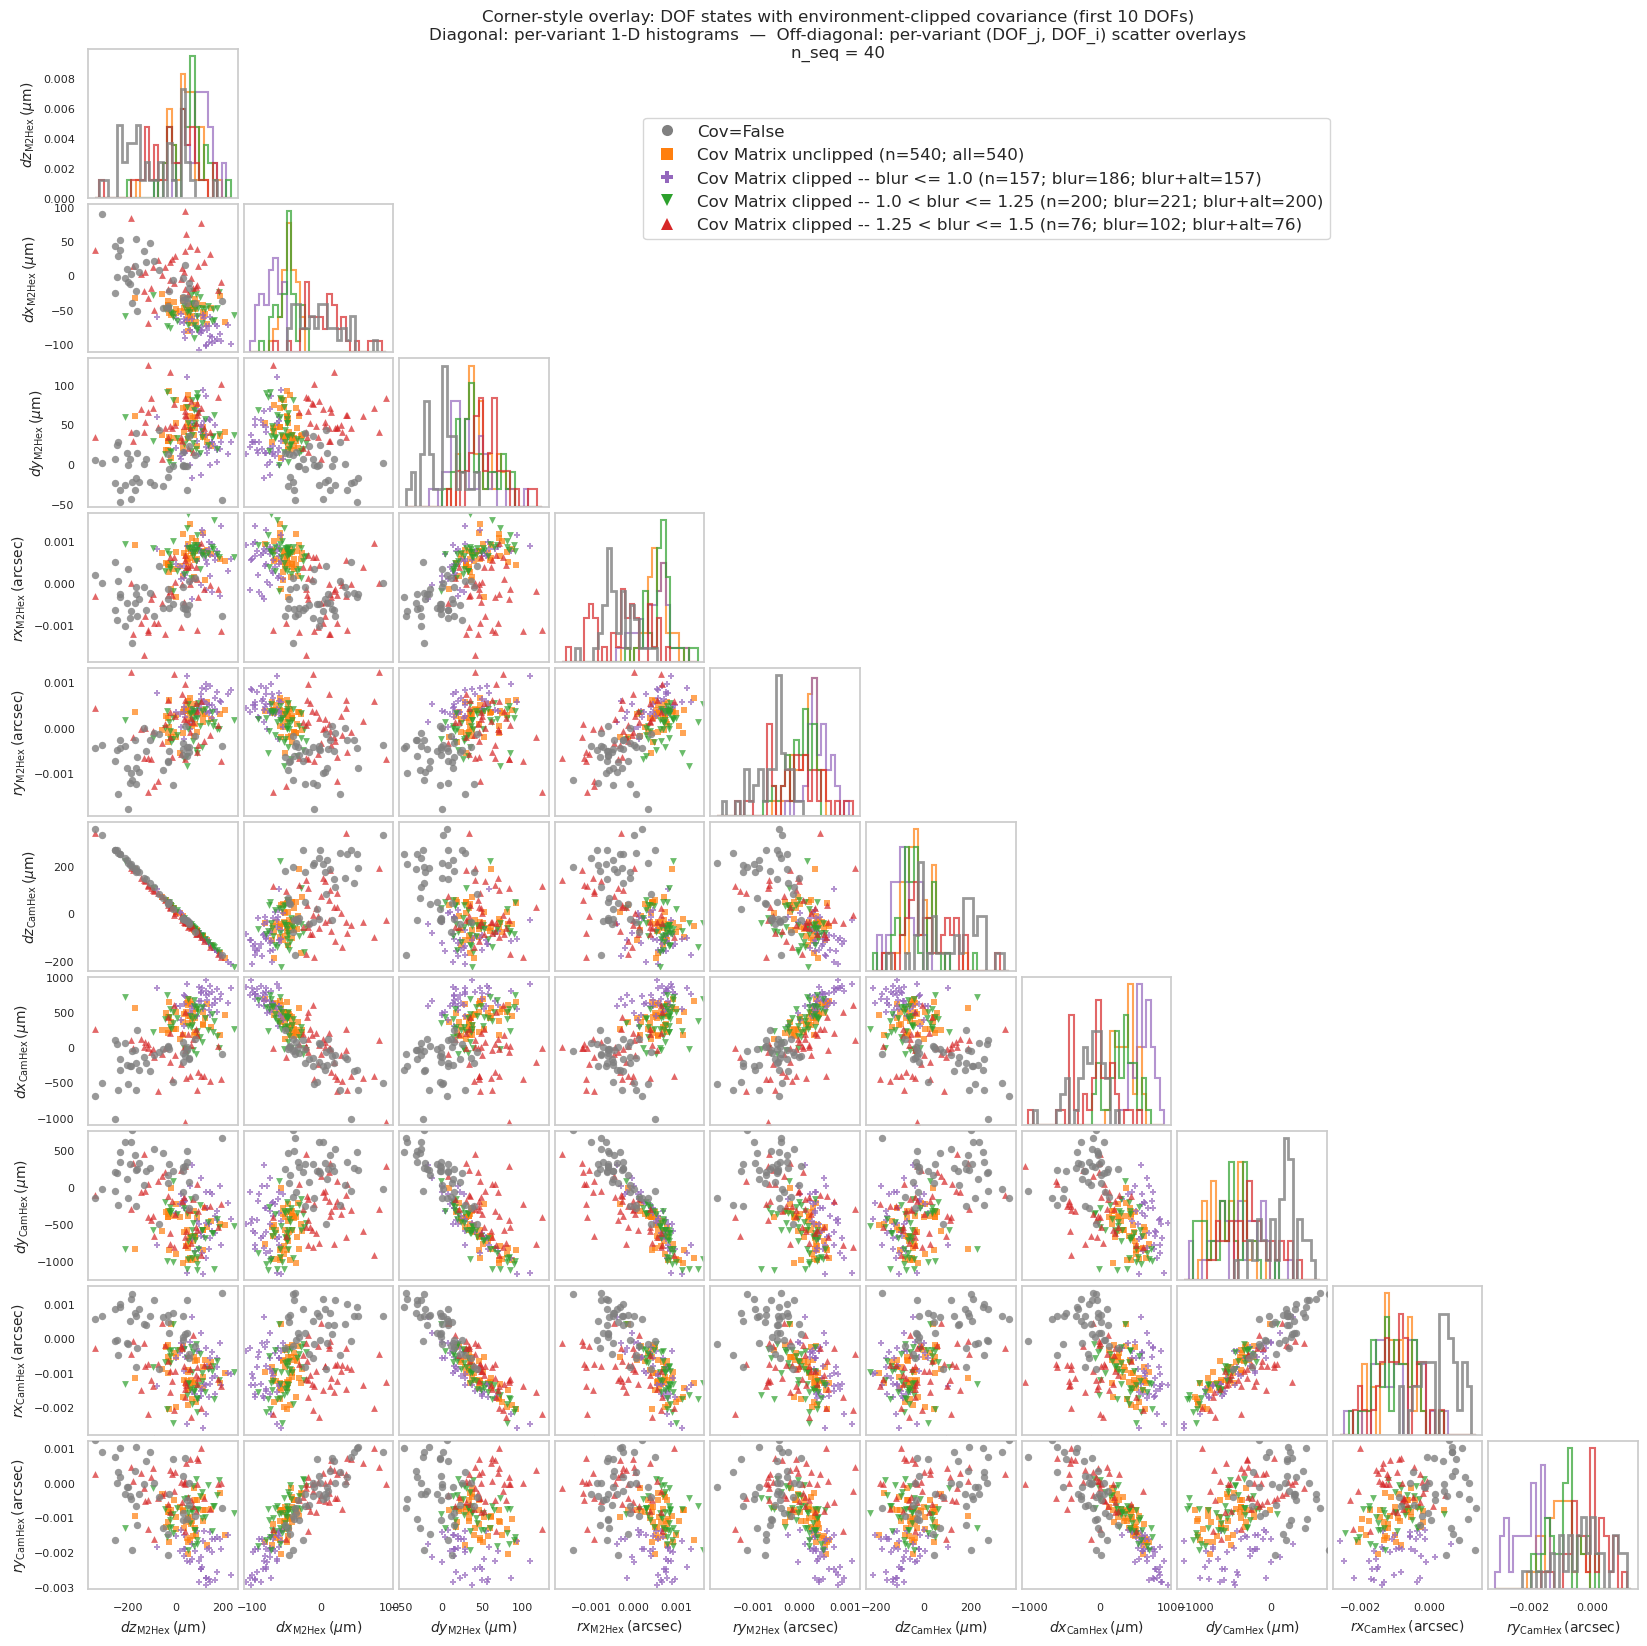

In [51]:
# Option 2: Cov=False + Cov Matrix unclipped + all per-bin clipped variants (no aggregate)
#
# Selection legend:
# - include_variants=None means 'include all variants'; exclude_variants then removes matches.
# - Here we exclude the aggregate variant and keep excluding the worst-blur bin.

# ======================== CONFIG ========================
corner_n_show = 10
corner_max_points = None
corner_bins = 30
diag_mode = 'hist'
include_variants = None
exclude_variants = ['aggregate', 'blur > 1.5']
# ========================================================

dof_all_bins_fig = plot_corner_overlay(
    clipcov_states=clipcov_states,
    clipcov_variant_labels=clipcov_variant_labels,
    clipcov_use_dof=clipcov_use_dof,
    clipcov_seqs=clipcov_seqs,
    include_variants=include_variants,
    exclude_variants=exclude_variants,
    corner_n_show=corner_n_show,
    corner_max_points=corner_max_points,
    corner_bins=corner_bins,
    diag_mode=diag_mode,
    save_path='corner_overlay_covfalse_unclipped_bins.png',
    verbose=True,
    show=True,
)

## Export Figures for Technical Note

This section exports figures for the SITCOMTN-177 technical note. Run the cell below after executing all analysis cells above.

In [ ]:
# =============================================================================
# Section: Export Figures for SITCOMTN-177 Technical Note
# =============================================================================
# Run this cell AFTER running all analysis cells to export figures to _static/
# These figures are then copied to the technote repository.

from pathlib import Path
import matplotlib.pyplot as plt

STATIC_DIR = Path("./_static")
STATIC_DIR.mkdir(exist_ok=True)

def save_current_fig(name, dpi=150):
    """Save the current figure to _static/."""
    path = STATIC_DIR / f"{name}.png"
    plt.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f"Saved: {path}")
    plt.close()

print(f"Exporting figures to {STATIC_DIR.resolve()}...")
print("=" * 60)

# -----------------------------------------------------------------------------
# Figure 01: Stability nights overview (from physical_params_fig)
# -----------------------------------------------------------------------------
if 'physical_params_fig' in dir():
    physical_params_fig.savefig(STATIC_DIR / "01_stability_nights_overview.png", 
                                 dpi=150, bbox_inches='tight', facecolor='white')
    print("Saved: 01_stability_nights_overview.png")
else:
    print("SKIP: 01_stability_nights_overview.png (physical_params_fig not found)")

# -----------------------------------------------------------------------------
# Figure 02: Seeing/AOS metrics (from seeing_metrics_fig)
# -----------------------------------------------------------------------------
if 'seeing_metrics_fig' in dir():
    seeing_metrics_fig.savefig(STATIC_DIR / "02_seeing_aos_metrics.png",
                                dpi=150, bbox_inches='tight', facecolor='white')
    print("Saved: 02_seeing_aos_metrics.png")
else:
    print("SKIP: 02_seeing_aos_metrics.png (seeing_metrics_fig not found)")

# -----------------------------------------------------------------------------
# Figure 03: Detrending comparison (from detrend_fig)
# -----------------------------------------------------------------------------
if 'detrend_fig' in dir():
    detrend_fig.savefig(STATIC_DIR / "03_detrending_comparison.png",
                        dpi=150, bbox_inches='tight', facecolor='white')
    print("Saved: 03_detrending_comparison.png")
else:
    print("SKIP: 03_detrending_comparison.png (detrend_fig not found)")

# -----------------------------------------------------------------------------
# Figure 04: Cumulative covariance (from cumcov_fig)
# -----------------------------------------------------------------------------
if 'cumcov_fig' in dir():
    cumcov_fig.savefig(STATIC_DIR / "04_cumulative_covariance.png",
                       dpi=150, bbox_inches='tight', facecolor='white')
    print("Saved: 04_cumulative_covariance.png")
else:
    print("SKIP: 04_cumulative_covariance.png (cumcov_fig not found)")

# -----------------------------------------------------------------------------
# Figure 05: Covariance matrix canonical order (from cov_canonical_fig)
# -----------------------------------------------------------------------------
if 'cov_canonical_fig' in dir():
    cov_canonical_fig.savefig(STATIC_DIR / "05_covariance_matrix_canonical.png",
                              dpi=150, bbox_inches='tight', facecolor='white')
    print("Saved: 05_covariance_matrix_canonical.png")
else:
    print("SKIP: 05_covariance_matrix_canonical.png (cov_canonical_fig not found)")

# -----------------------------------------------------------------------------
# Figure 06: Simulated vs measured covariance (from sim_meas_cov_fig)
# -----------------------------------------------------------------------------
if 'sim_meas_cov_fig' in dir():
    sim_meas_cov_fig.savefig(STATIC_DIR / "06_sim_vs_meas_covariance.png",
                             dpi=150, bbox_inches='tight', facecolor='white')
    print("Saved: 06_sim_vs_meas_covariance.png")
else:
    print("SKIP: 06_sim_vs_meas_covariance.png (sim_meas_cov_fig not found)")

# -----------------------------------------------------------------------------
# Figure 07: DOF distributions comparison (from dof_comparison_fig)
# -----------------------------------------------------------------------------
if 'dof_comparison_fig' in dir():
    dof_comparison_fig.savefig(STATIC_DIR / "07_dof_distributions_comparison.png",
                               dpi=150, bbox_inches='tight', facecolor='white')
    print("Saved: 07_dof_distributions_comparison.png")
else:
    print("SKIP: 07_dof_distributions_comparison.png (dof_comparison_fig not found)")

# -----------------------------------------------------------------------------
# Figure 08: Clipped covariance comparison (from clipped_cov_fig)
# -----------------------------------------------------------------------------
if 'clipped_cov_fig' in dir():
    clipped_cov_fig.savefig(STATIC_DIR / "08_clipped_covariance_comparison.png",
                            dpi=150, bbox_inches='tight', facecolor='white')
    print("Saved: 08_clipped_covariance_comparison.png")
else:
    print("SKIP: 08_clipped_covariance_comparison.png (clipped_cov_fig not found)")

# -----------------------------------------------------------------------------
# Figure 09: DOF clipped overlay (from dof_clipped_overlay_fig)
# -----------------------------------------------------------------------------
if 'dof_clipped_overlay_fig' in dir():
    dof_clipped_overlay_fig.savefig(STATIC_DIR / "09_dof_clipped_overlay.png",
                                    dpi=150, bbox_inches='tight', facecolor='white')
    print("Saved: 09_dof_clipped_overlay.png")
else:
    print("SKIP: 09_dof_clipped_overlay.png (dof_clipped_overlay_fig not found)")

# -----------------------------------------------------------------------------
# Appendix figures
# -----------------------------------------------------------------------------
if 'cross_corner_fig' in dir():
    cross_corner_fig.savefig(STATIC_DIR / "A01_cross_corner_correlation.png",
                             dpi=150, bbox_inches='tight', facecolor='white')
    print("Saved: A01_cross_corner_correlation.png")
else:
    print("SKIP: A01_cross_corner_correlation.png (cross_corner_fig not found)")

if 'full_corr_fig' in dir():
    full_corr_fig.savefig(STATIC_DIR / "A02_full_correlation_matrix.png",
                          dpi=150, bbox_inches='tight', facecolor='white')
    print("Saved: A02_full_correlation_matrix.png")
else:
    print("SKIP: A02_full_correlation_matrix.png (full_corr_fig not found)")

if 'sim_meas_corr_fig' in dir():
    sim_meas_corr_fig.savefig(STATIC_DIR / "A03_variance_comparison.png",
                              dpi=150, bbox_inches='tight', facecolor='white')
    print("Saved: A03_variance_comparison.png")
else:
    print("SKIP: A03_variance_comparison.png (sim_meas_corr_fig not found)")

if 'corr_by_blur_fig' in dir():
    corr_by_blur_fig.savefig(STATIC_DIR / "A04_correlation_by_blur.png",
                             dpi=150, bbox_inches='tight', facecolor='white')
    print("Saved: A04_correlation_by_blur.png")
else:
    print("SKIP: A04_correlation_by_blur.png (corr_by_blur_fig not found)")

if 'dof_all_bins_fig' in dir():
    dof_all_bins_fig.savefig(STATIC_DIR / "A05_dof_all_blur_bins.png",
                             dpi=150, bbox_inches='tight', facecolor='white')
    print("Saved: A05_dof_all_blur_bins.png")
else:
    print("SKIP: A05_dof_all_blur_bins.png (dof_all_bins_fig not found)")

print("=" * 60)
print("Figure export complete.")
print(f"To copy to technote: cp _static/*.png /path/to/sitcomtn-177/_static/")